# MedGS4D: endpoint-only respiratory CT interpolation

MedGS represents a CT volume with learnable Gaussian primitives and reconstructs its slices with a differentiable renderer. MedGS4D adds a time-conditioned network to a frozen canonical MedGS representation: instead of fitting a separate volume at every respiratory phase, it moves the same primitives through time.

The task is to reconstruct **10%, 20%, 30%, and 40%** from the observed **0% and 50%** scans. The six variants below test which temporal assumptions help when intermediate scans are unavailable during fitting. Each case is fitted independently; there is no population-level pretraining.

The benchmark targets comparison with **UVI-Net (CVPR 2024)** on its original 4D-Lung preprocessing and test series. Architecture and consistency extensions are hypotheses; their benefit is determined by the final evaluation.


## 1. Experiment configuration

Use the existing `medgs-worf` kernel. Set the paths and GPU here, then run the notebook from top to bottom. The source snapshots may already be unpacked, or `SOURCE_ARCHIVES` can point to the manually uploaded archives. The notebook checks their contents and stages a private copy for this experiment.

A new `EXPERIMENT_ID` starts all models from zero. For an interrupted run, keep the same configuration and set `RESUME = True`; completed runs are reused and incomplete temporal runs continue from saved checkpoints. Existing experiment directories are never silently replaced. Canonical resumption requires at least one upstream checkpoint; its upstream sampler does not restore an exact RNG trajectory.


In [7]:
from pathlib import Path

import ast
import difflib
import hashlib
import json
import math
import os
import platform
import shutil
import subprocess
import sys
import tarfile
from datetime import datetime, timezone

STACK_ROOT = Path("/home/jovyan/shared/mtm_medgs_stack")
DATA_ROOT = STACK_ROOT / "data" / "uvi_net" / "4D-Lung-Preprocessed"
EXPECTED_PYTHON = STACK_ROOT / "envs/medgs-worf/bin/python"
EXPERIMENT_ID = "medgs4d_six_methods_20261001"
ROOT = STACK_ROOT / "experiments" / EXPERIMENT_ID
GPU_INDEX = "1"  # Physical GPU; workers use logical cuda:0.
RESUME = False
SEED = 42
CANONICAL_ITERATIONS = 15_000
TEMPORAL_ITERATIONS = 7_000
SOURCE_DIRS = {"medgs4d": STACK_ROOT / "repo/medgs4d", "MedGS": STACK_ROOT / "repo/MedGS"}
SOURCE_ARCHIVES = {"medgs4d": None, "MedGS": None}  # Or Path("/absolute/path/archive.tar.gz").
PHASES = [10, 20, 30, 40]
TEST_CASES = [f"118_{i}" for i in range(6)] + [f"119_{i}" for i in range(8)]
METHODS = ["baseline", "linear_pseudo", "cycle_v2", "trajectory", "consistent_cycle", "trajectory_cycle"]
LABELS = dict(zip(METHODS, ["Baseline", "Linear pseudo", "Cycle-v2", "Endpoint trajectory", "Consistent cycle",
                            "Trajectory + cycle"]))
NEW_OPTIONS = {
    "endpoint_warmup": 1000, "transport_pretrain": 500, "joint_ramp": 1000,
    "endpoint_image_weight": 0.05, "alignment_weight": 0.01,
    "roundtrip_weight": 0.01, "path_weight": 0.005,
    "correction_weight": 1e-3, "curvature_weight": 1e-5,
    "curvature_step": 0.025, "geometry_gaussians": 8192,
}
QUALITATIVE_CASES = [TEST_CASES[0], TEST_CASES[len(TEST_CASES) // 2], TEST_CASES[-1]]
QUALITATIVE_SLICE = 64
ERROR_VMAX = 0.2
print("Experiment:", ROOT)
print("Budget:", len(TEST_CASES), "canonical +", len(TEST_CASES) * len(METHODS), "temporal runs")


Experiment: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001
Budget: 14 canonical + 84 temporal runs


### Environment and source provenance

The supplied environment snapshot uses Python 3.11.5, PyTorch 2.4.1+cu124 and NumPy 1.26.4. No installation is performed. Runtime package versions, CUDA details and source hashes are saved under the experiment root. `nvcc` may be outside `PATH`; precompiled CUDA extensions do not require invoking it during training.

The canonical MedGS snapshot hardcodes seed 0 internally. Its private experiment copy is adjusted to the configured seed, and the exact diff is saved. All six temporal methods use the same freshly trained canonical checkpoint for a given case. Fixed seeds improve repeatability, but custom CUDA kernels may still be nondeterministic.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
import torch
import torch.nn.functional as F
from IPython.display import display

assert Path(sys.executable).resolve() == EXPECTED_PYTHON.resolve(), (sys.executable, str(EXPECTED_PYTHON))
assert platform.python_version() == "3.11.5", "Select the supplied WORF environment."
assert torch.__version__ == "2.4.1+cu124", torch.__version__
assert np.__version__ == "1.26.4", np.__version__
assert torch.cuda.is_available(), "CUDA is unavailable in the selected kernel."
assert int(GPU_INDEX) < torch.cuda.device_count()
assert TEMPORAL_ITERATIONS > sum(NEW_OPTIONS[k] for k in ["endpoint_warmup", "transport_pretrain", "joint_ramp"])
assert 0 < NEW_OPTIONS["curvature_step"] < 0.05
assert CANONICAL_ITERATIONS > 0 and TEMPORAL_ITERATIONS > 0
if ROOT.exists() and not RESUME:
    raise FileExistsError(f"{ROOT} already exists. Set RESUME=True or choose a new EXPERIMENT_ID.")
ROOT.mkdir(parents=True, exist_ok=True)
for folder in ["config", "sources", "environment", "prepared", "canonical", "methods", "predictions", "metrics",
               "tables", "figures", "logs", "tools"]:
    (ROOT / folder).mkdir(exist_ok=True)


def sha256_file(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def write_json(path, value):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_text(json.dumps(value, indent=2, sort_keys=True) + "\n")
    temporary.replace(path)


def write_exact(path, content):
    path = Path(path)
    if path.exists():
        assert path.read_text() == content, f"Saved code differs: {path}; use a new experiment ID."
    else:
        path.write_text(content)


stamp = datetime.now(timezone.utc).strftime("%Y%m%d_%H%M%S")
ENV_DIR = ROOT / "environment" / stamp
ENV_DIR.mkdir()
write_json(ENV_DIR / "runtime.json", {
    "python": sys.executable, "python_version": platform.python_version(),
    "torch": torch.__version__, "numpy": np.__version__, "cuda": torch.version.cuda,
    "cudnn": torch.backends.cudnn.version(), "gpu_index": GPU_INDEX,
    "gpus": [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())],
})
commands = {
    "pip-freeze.txt": [sys.executable, "-m", "pip", "freeze"],
    "pip-list.json": [sys.executable, "-m", "pip", "list", "--format=json"],
    "torch-collect-env.txt": [sys.executable, "-m", "torch.utils.collect_env"],
    "nvidia-smi.txt": ["nvidia-smi"], "gcc.txt": ["gcc", "--version"],
}
nvcc = shutil.which("nvcc") or str(Path(sys.prefix) / "bin/nvcc")
commands["nvcc.txt"] = [nvcc, "--version"]
conda = shutil.which("conda")
if conda:
    commands["conda-environment.yml"] = [conda, "env", "export", "--prefix", sys.prefix]
    commands["conda-explicit.txt"] = [conda, "list", "--explicit", "--prefix", sys.prefix]
for filename, command in commands.items():
    try:
        result = subprocess.run(command, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, timeout=120)
        text = result.stdout + f"\n# return code: {result.returncode}\n"
    except (OSError, subprocess.TimeoutExpired) as exc:
        text = str(exc)
    (ENV_DIR / filename).write_text(text)
print("Environment saved:", ENV_DIR)


Environment saved: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/environment/20261001_183234


In [3]:
SOURCE_HASHES = {
    "MedGS": {
        ".gitignore": "a0fca49e2d2ef16e57490ab9f025605fd4f7105928c391e43f907e111aa7e15b",
        ".gitmodules": "a09ce550ed31090326873cb6986caf8b4c802acc6bdeb6220d1d6b47e7b60404",
        "LICENSE.md": "c5ba70a2194af2aefe85dfe3da68608dcb3abd21a3aa53b55aa297c2f0b60eb3",
        "README.md": "2544abe9bcf2c87d0015ba5537fe4e59110cf9209ed78490987fe0fd0641bd73",
        "arguments/__init__.py": "bd1c828873c37c366e18a0453871762c598e34be21ced436d47e8594dc7212c5",
        "evaluate.py": "e5b250795b48a7e445fbdaa3bcebcb86a624edf0f9de9da25112e5799c6119a1",
        "gaussian_renderer/__init__.py": "471618d266c6c37496c3db1de96201c0bd5eec8c2d85fc09b2bb2930ebd4c5f3",
        "gaussian_renderer/bg_fg_renderer/__init__.py": "774145a455caf85c6b24dce786b6e78111cca8bbf9bb3e3ecf0a0453fa88b45b",
        "gaussian_renderer/network_gui.py": "7e392b8122a8e1359b4550769eac06190806a8c2eeb7f5aa7cbd025738dedf89",
        "models/__init__.py": "dc9e8115867619999ac96e05d734ea03b768ef89e305a4d4c894c8a0dbf22c32",
        "models/flat_splatting/scene/points_gaussian_model.py": "437d95c57533cc5253b76955f06cf1f97fd93c2c8955333289321dfbd90d7f1a",
        "models/scenes/__init__.py": "b92cecef28b78ec1480313998393d51b076335786f71a3c11aa7eeb789e8d29f",
        "models/scenes/dataset_readers.py": "9de7a482b5348ed03ab99cf2c416293371f963e7b43849596870f56fc878ed8b",
        "render.py": "2a0bb54069977c5ddb03ae084ad885e3c1d622639e63327f49decff4cdd00640",
        "requirements.txt": "46673ebb297f05425a9e821da80d31b9925d0c013108f9827466dd98d38202bb",
        "scene/__init__.py": "61bb4d5255cb4b75e71337462653a665913d1c11188cd79a6b99d22622164756",
        "scene/cameras.py": "f6b98ef186055780f459a7a7d863c838b53c9dec30f544cc9a18a773057fbe9d",
        "scene/colmap_loader.py": "6948ce06366e1f727ddffc39a445bf4b6873824f02abc39df63eb0c8f0fb3f36",
        "scene/dataset_readers.py": "64f2479c81c1deaad48978fab1148996766b900aeaf9d52c2f697a179a645d60",
        "scene/gaussian_model.py": "88111d6ca1016fe08a930d18e859cceb9448a0fbbceacfdef43bc4278000b380",
        "slices_to_ply.py": "31a2de0997cd8bd2f0f5708dd0b1e4f4542f1873a5bcd4ba90add1a570248e76",
        "submodules/diff-gaussian-rasterization/.gitignore": "5cb50fd1077b728ac04ffed37e38f5778e8ee9e7893e616b61c1a6ad7751d600",
        "submodules/diff-gaussian-rasterization/.gitmodules": "b3e723b5074f9d22ad417e4414072675aa96fd85296d6c867cbb320f18e57d1f",
        "submodules/diff-gaussian-rasterization/CMakeLists.txt": "8fc64ae6030af399b7b9559dea0c68e0aef619dca110e11248cf08ca9e9ad830",
        "submodules/diff-gaussian-rasterization/LICENSE.md": "cd5c95b3cfff3acc1bd412420c770f88809331c3db6872df11a970147aa8e81f",
        "submodules/diff-gaussian-rasterization/README.md": "c82413c3a880e939f8620208ea919d468b1a89791f9a6cfe4dbbdf71326ba6a8",
        "submodules/diff-gaussian-rasterization/build/lib.linux-x86_64-cpython-311/diff_gaussian_rasterization/__init__.py": "b3ac794d758c546d32860c5a2fd42b9ac6791d0822d7811d05c8d131a8a38a63",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/auxiliary.h": "5a3345d46acd23a85e44c214dac404f4be195d7c4c49c9effa280ba3bbb10a51",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/backward.cu": "31074cea35919f108eb84770e170be844b95746f7fb1dd64024c3f9b1de57606",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/backward.h": "c1d587d449eab7d97381efd3e0e2ffea326aa83b9b6f282ee8b6148a13ec4969",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/config.h": "86d90fe26989e5a991104842961341d1bcb4374d5068dcb2a56d63a9017f8d65",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/forward.cu": "4bfb6830a138bd016f39fa4558f998825d4182b12cfbda2f62bed0ab75042b54",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/forward.h": "33c7d55064bfae5bf95c9ffdcb97c67a65ab1b70d91f5a04de5f7340b69a418c",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/rasterizer.h": "1f29bf503e1eababde3f1c262f6755ad9c47e3514e601366d63608a855ed74f8",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/rasterizer_impl.cu": "e338380e2d4631cf842904fbf87025ddb46d49b5f1a5a22fd53bf8ada0ec1109",
        "submodules/diff-gaussian-rasterization/cuda_rasterizer/rasterizer_impl.h": "58b97a9728e24d41602a2ac3e8eace025cfd3228de6e75033dc458d0303a46f4",
        "submodules/diff-gaussian-rasterization/diff_gaussian_rasterization/__init__.py": "b3ac794d758c546d32860c5a2fd42b9ac6791d0822d7811d05c8d131a8a38a63",
        "submodules/diff-gaussian-rasterization/ext.cpp": "102d6ca2a07cf57717e5828c49a7100841cc0147f7373de768070f06bc4909ef",
        "submodules/diff-gaussian-rasterization/rasterize_points.cu": "462bb16c83f41e3d029cab20d46a951ddd4db10931da5fc6595537268babbd32",
        "submodules/diff-gaussian-rasterization/rasterize_points.h": "f8ce3ac6e254b1db629ecc2c60817e9a5586541bf734c715bec6e8f6588f794b",
        "submodules/diff-gaussian-rasterization/setup.py": "3bc4065d0ba274aca98a68930c8897f56110bd56f17c5d04c4b66c20bdf36e71",
        "submodules/diff-gaussian-rasterization/third_party/glm/.appveyor.yml": "c713ce93fe25d90e1ffc10351b0d139342c57e6ee8e82c8b4e5408a02f2cae59",
        "submodules/diff-gaussian-rasterization/third_party/glm/.gitignore": "bd3bb9dbc46eaccd3013a8a179213314da7be8998b9fe1adabbb04c7d2f9fd0d",
        "submodules/diff-gaussian-rasterization/third_party/glm/.travis.yml": "008ad795810f1f8853d8ac54f50a9e83f907bcb667d268de2b84460c4f82bae7",
        "submodules/diff-gaussian-rasterization/third_party/glm/CMakeLists.txt": "9ef724c6f4dcd6d54a0f843075e837c8a64fc538d4069f6841090501140e7c9d",
        "submodules/diff-gaussian-rasterization/third_party/glm/copying.txt": "62d2d642c7d054d4fb4c9b42faad617d6c88fcd91e317f8035aa9f277cc159c3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/CMakeLists.txt": "6ef3836f3d846276983dfb968ce6c8d6479ad4e946e2b8bc013eb20bf38f1d18",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/common.hpp": "776ef2f5073aa29b7abd0c45c41e99122306b65efeb1dbff0247cc11564a6272",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_features.hpp": "c7822908b5129b74e108246b3baaa6e2154abc9cf65f3f789d2a0f6bf0656f06",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_fixes.hpp": "fa972e30228133d4a67cbdb1a05f0edfb32de4149c95c253650cf1ff1cf35ad1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_noise.hpp": "9d7485ab7131fd9a0a8cc8031453a37271eeb79f2ce146f5db576786ec4dac6e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_swizzle.hpp": "cb45420e33606d6a428a3bb403d0196b306b5450e1c47efc499e32cda7c3479c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_swizzle_func.hpp": "db3c5a2d99d0a726de2a11d8b5e84db84b54538d78dd970b3cf579f01434bc52",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/_vectorize.hpp": "da5f0b653ca062e22c8e456b6ef5e430309ac8681d2dba4cb1606d4e4df0aa2d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/compute_common.hpp": "86331dcb56212827e41afa91d72d23002ff3f73e6006d26032f8780ec75ffcd8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/compute_vector_relational.hpp": "f4b44de6254936cd4f35756f93469934d60859f0062e821733bed79441f66abf",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/glm.cpp": "a094f828e1f0f17b04662c7742f2de9f1568654ac1c627a5a34f13f4a428ae73",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/qualifier.hpp": "4b98355b9cf30c48953783aec2f8ebf342ff3a0bc55902fe40266d62cb10ddb9",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/setup.hpp": "8a1ee2261c36c08efc209a7ddb3b63d08fd6aff22efadfdc732f6350e985a902",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_float.hpp": "33c1a7b88bcddae7ce51ae6e499626025d17ea47c40d946a24f9053994280580",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_half.hpp": "9f98c3e42ebf1ad0ca6a1f0d2211bf6d3c226c99555c8852b02ddc4d5c3fa1c5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat2x2.hpp": "a93526c01e9d0ab69c6946d5ec0b2372a6a2b01c34f709847c2875d3069e87d1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat2x3.hpp": "e3dff52e7b4c4d16de3f69273598f57919fade4e2cc0cf75f6bb5f5aa997693c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat2x4.hpp": "aef20a588791b93f0fce5fe01af638ce546d29742b957ebadcbf3126ff86c0e1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat3x2.hpp": "32e756a8cc5a4ab0178bf37bb24ff8f749c5fc88afc4c9c35cc4b0b871c1f3d6",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat3x3.hpp": "a08783e629beb3b8209162b754eeb710a8815b5512b86f73b3fa9fca6c26e25d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat3x4.hpp": "ed246c36fb8e03959dcc36895d75a615b704537cd8eb3b4d147584eff985404e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat4x2.hpp": "677e0337f82b5acbd0611849143f64b6d93f352264a31d6035d415a9788bf98d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat4x3.hpp": "c4877112e12c9a9eb4b2ff5e97cc1531eaf8c4a9e620a89f86dbf31f3ca07355",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_mat4x4.hpp": "4548563a5da19892a6844cb0c27e8b73f7c3f0f0d001344cab6c862a0360ff86",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_quat.hpp": "61cf382c6853b27323b99fc9f5f33db381fab2f841dd4f56d35a22bac8bb564f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_vec1.hpp": "e3e46ea5ef353993ae756ba56614aa5d484717562021e090d9a7c09852f6bc0d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_vec2.hpp": "3f12c15be1b32dbfd77444ed12ece037ae0fd63b6cee7e665a6e425c9313d8ac",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_vec3.hpp": "07c7ca73ef1b9f7200674a665f68461627585c12b2195e3ee68d5d81cbe8ada3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/detail/type_vec4.hpp": "7d2d34d8b57ecae76197d7e2e05a47223a15dd724b60810539783be72c6f2431",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/exponential.hpp": "4dc2669786b270b7a2af461a8fbc3785b5af1d70e546142c3a6e07801170480e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext.hpp": "cc3f951e3dce4bc80616dd8ef68dd2ef781cfca58fcb7140db2b9a1280912184",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/_matrix_vectorize.hpp": "aa2d2e7a5a2959b0f0350304a8800971e1cb0731ec5cb9f8b0e0b0fc2d9d3afc",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_clip_space.hpp": "ab50948fb483e15105e7a7a37da89b77378a06c2f98a767965d6c58916d27965",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_common.hpp": "a1718e5ced7da49bf57ea192160311995cc7b7881d1a9c9c91ba7cbff2611e26",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x2.hpp": "f162435d27c44b2123fb6aeabf6a1ad303038bc23ce2c4ce7c8d65059b4ff18d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x2_precision.hpp": "870a26e88d5606eb59afd4dfeeaae03e4627fe3b2ac2412ef9909fde4a69c380",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x3.hpp": "293555b0ed97a43a8943245ad856ae5dd7db047205cd518f3a6626475a3854f6",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x3_precision.hpp": "5b0ebe9a915f87f396870eb4897253e60fa0bea6044435ce7a28ee3a1920d71c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x4.hpp": "8a220b383965f0457b2e60cee0e01328a8e0ddce266e9e101f98e5471fff47bd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double2x4_precision.hpp": "1fd885f6484d863f6e43c8276ab2e3548e8789a584eb895a45dfb2479a032c02",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x2.hpp": "21189033fd6644d820eb597cc1afa6c7ee4cc60e8f6d90d5a0d50b7e56f47e81",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x2_precision.hpp": "b8bfeb2bc4ad1e9a27673de6c6bf2a547a8db2c8766ee02a7324170b678ae60f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x3.hpp": "ce0212b641e65eddba35e02df72b6343056309af06b0e26464a908d19eece282",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x3_precision.hpp": "bf7ea325238b15767ae810e556bfdfdeaf3898aa248b75f374b2284e8afa9ef4",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x4.hpp": "5751fac2e7d8955c1a67a558ae6cf53168c279a8dab43a915e14292b130b242c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double3x4_precision.hpp": "271e3c054da08e16732398f7d9b24cd0af6ab40f862260404b42999d457c0b19",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x2.hpp": "b0c0155ff665e99994487a4750f703b2018e7bfb6010d3fbd756c5e5d25f4685",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x2_precision.hpp": "660f21b84ed78dd631c00d25442d807074bc7fbeb5e9001f925f1a3d9e4ad04f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x3.hpp": "6f5202c9dd2a3a97901220d018f728a9dafb56c9895f3b3cf99ced0304be3095",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x3_precision.hpp": "131fe335a681ffb23348f043cee30e2427a9e1f45be9f1c71df1ecb5c7589f6b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x4.hpp": "2cfc993535a19a8b52a5f6a6d71a0eb3ab646cbf9da0d3cf50f5f3248d3c2e35",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_double4x4_precision.hpp": "1e906578cda07f564ff7c5b5bf31b4749c686fb6e4052da2bbbd46c9dd6abe00",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x2.hpp": "ecf72a0f02fec9cf6747a4e5b3d62c9a6f07bbc35b4bbf949250a8100500c8ea",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x2_precision.hpp": "955c6d5c0b661dafdcd0169a0e104784deb5dd7862a8fb132720dafb22f4a780",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x3.hpp": "d731b656ddded3ca7b9eb26b52849445a1d438457e4fad02d1fe94fa349b39a0",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x3_precision.hpp": "f8bd301e8a43b15e92c9935edb71c455b9ecd922c5f0a2e6d1b32783819cb28c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x4.hpp": "f0be584885cc45b25708a181d859d69886d6919839f399f831ea727682c88a05",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float2x4_precision.hpp": "15d8d7f61beeaacd077ef44296a5ed369a0c6aab5ec8481db9bd60f3290013dc",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x2.hpp": "990d9fbe4ab32cb35c67881a42bb88bdad38b9386f0a9e273bd7a5c4eb13dc7c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x2_precision.hpp": "ac403a7bf1ee8ad2799a4c8a9630d679156bd82f411696a4c9eba1de5f6dc8cb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x3.hpp": "13afb5c9a76cd00924bfd90338861bc7ba85097cc8a2c93a747862d9aef95737",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x3_precision.hpp": "7dabb577886c2d26c752462118e55e67f03d7119a46877980991bc87b6bce4fa",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x4.hpp": "5a964ddc2ffed1f1a8f5f8d392f34aa4f870a0c985eda0c92c29ac6cd5679543",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float3x4_precision.hpp": "096f630c612e71c525269940cfccea7f76dac9a5f282127a0bf89d3b08527830",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x2.hpp": "c911e033c9268da984c9c2254cb92604060525d55220a333daf1688bf4575f6d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x2_precision.hpp": "dbf3daf91ede9b5987c57c4e4ea609eae089ad241b936aa4ffa604ca89e0346f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x3.hpp": "c8d6bff74c2a51cff7573afcd9541f044d5da519694f4b344ec4bdebc1b6a213",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x3_precision.hpp": "e178488c0bd2d95c8d1e907e83e7b7f14bad2c9f6012c10514837b814fdeb9b8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x4.hpp": "66dbcdd06c50852fa77660429f618ef9d35131b8a8097821247a869014366c15",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_float4x4_precision.hpp": "e8688aa7c58fa5ad167a79075788b9685096202569e6d2186e0433c93647c5bf",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x2.hpp": "8a3080afff7099b3dfc61d6c3a247087ced7f6993fa40b5ebbaa1208335dc4c0",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x2_sized.hpp": "0fbcb22bacda84426f6edbc70635a3453eacf4fa940d5e88d04fdbdeaa121107",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x3.hpp": "d045c6df93b236c00c24b8924086eec004feb6b8301b84de95c44ea5955165cc",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x3_sized.hpp": "9a8fb9c2b5b92ae2d02d0ec116b05f33083f87fc2a6f64eaaca6f0cda9bbdfe7",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x4.hpp": "14f2dc172aa1d618ba7ecd4109e69a07e36399d1979daa622790f871dd93df52",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int2x4_sized.hpp": "9ea529675b293464c471c9a28f928330de0d441b0c5eb86845e75548bd1c0688",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x2.hpp": "6071040192b2fb125f271724a0f30d8caf7df7499cb07a4484ede4181e94d4ec",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x2_sized.hpp": "1b0488e9b88e63d93962a7468dd29fb830ddf312df802413063b5fc91399441f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x3.hpp": "76e66b174f3f0cafeffb1b7ab2221bcf923dcbe4c30ee56ab5addd04f46ac325",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x3_sized.hpp": "08cff59b27b2f72b42be58b7559a0cc86211bbf01309563375f6f4f6124e7edb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x4.hpp": "f3516290f38a476fe12aaf04b9f1ab19870ddc014b9e53ff366b120265064fe3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int3x4_sized.hpp": "4c2219010ce9c08aebcc9f07bb4a039a75ff0b16ab24e06fecbf202e98f86df5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x2.hpp": "09ff0041bd3450a1e811a41bc7012b2afed4ce8906a58851c309ccbf3851cfe1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x2_sized.hpp": "e784ee517181561d8ed219738dec0146d39f19cd036ec4fae32987ebcc2627e2",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x3.hpp": "30114b6258b94afb06d6a76326d1ce4abf66786adb226dcd1bba707ca009ad7f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x3_sized.hpp": "c8fcc8409a6215ee496eb86d44c68fdfac84addd4d15582a3dd60029dc2af851",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x4.hpp": "562ce6dae48fd6dabd991d35011886716da18667244715d3be4f648725b84672",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_int4x4_sized.hpp": "3044c19c6cd59224beb8a2f9a880a80497afb605c0498716e8f063c93cd365ad",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_integer.hpp": "61f9c0b622cf922ef8dc950e31d7d8252af7f0f7b76e06845a728a65bd4999ca",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_projection.hpp": "ab39c93d62ba24d631521c2020567a22d8bbfd0e61f8063b5f109acc39fa355b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_relational.hpp": "2402a31b974b125937ae6fb3bd61cbeef1e7dc937c15c8ba476272d1c2533e05",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_transform.hpp": "77bf5b0c160bdf52b96d159786d953c7e5d67a61e40733ed018cc4ece72b7148",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x2.hpp": "4a80c8f3374eb5b304513f3f0991e6a610f5b483a122455268962298eab82a23",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x2_sized.hpp": "d8caee9b54803cc892aadb864f45fb1880d56e96f4130f3e3d222094cca0d088",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x3.hpp": "f2170ddfca51827b5d5a8605c835abbe53ae8c3577c4640fddd55492a1870ec2",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x3_sized.hpp": "c1205db37d2a99378e1f5f3baffb3a44d3d041f4c3905c7f7783853c498778a9",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x4.hpp": "fb4255bfa2e92a8d29cbb6afc5b6f4665dbdcfa73d60f460d275f3463ab77c6b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint2x4_sized.hpp": "9d3409c3a2661583277bfeaabba536fc083cfab5f077a2cbbcc81604bdb44a1c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x2.hpp": "60f8fc35481bda8b080f39092a5e8c135b08d87fe0f4bf890f37a8c814753ae9",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x2_sized.hpp": "4d8db1e553add29b4ba83efb17b0651a168971ac45fd41d5f3c60186a48e63b9",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x3.hpp": "e9cf100c0732a9bc1cc3c6506ee2eb1151e5970d835bb5fef73d938d2f02094c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x3_sized.hpp": "40fd3e2f9057607ab49f191c928360fca03ccdd878a73b41ec8cfa9a655fd327",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x4.hpp": "b686f76221d8a73dc3745a2d8e7eee24fb8695ddd65fb16cb9605bffb3c9f6f8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint3x4_sized.hpp": "f834b99ab57d5cde531a40799ca940c66708bee8c07b8228648537d65dd6477b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x2.hpp": "52db98864969855922e0372ade11f521d4dc74d9ba16260cc4444b650e3778fb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x2_sized.hpp": "698cb47c02d7084bbbb51fc7cf723ec06ae2cd4a8b1c6dbed1901f768710c480",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x3.hpp": "a2148f7bf73e3e0d78f67449c7211d5f720555b1231f1d55d10a811cd4dfe2b4",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x3_sized.hpp": "65466bd9a77b17d30ed89e9b76b3f6b9c94ead9e4c915f7a417df6c3851009e3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x4.hpp": "4776c7a5f1b79a54f396fa2ac74fc3e6be3d938ee328ac43714f7a9f53c54ed3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/matrix_uint4x4_sized.hpp": "5c30e830072780480c1e842a36604d3a8d0b315ba2320b21722fc45a80e33d0d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_common.hpp": "f573d4691cfdba6f6741e9897492de3633321f952febd43f9bf7987629c66b91",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_double.hpp": "11607f4efb4a478df1c7701fa42a157ae47ffe3a5a6c9fc397fd7842fe68fdff",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_double_precision.hpp": "0e71b9f30dfbe962731b7fe48a639723d0bd0b9cd09f0ac138a75387c2ef28b2",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_exponential.hpp": "d745ba174a9aa0b1f997da61fab3d2bda25799d2907101856f60df8b164c03c5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_float.hpp": "c7d3c561dde9b3ae7f431c48580e60fe6e07518fd48c9c097153f74620880b81",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_float_precision.hpp": "eabb202f37e77ea6ee3dee1efe902dd45d1818ae2639bc1611d1e31784bcd209",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_geometric.hpp": "0745d628f7004d979ce3b23f5b1cf245fe679dc19f1656f3897334c453863a46",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_relational.hpp": "51d1fe010ce64cfdf7b70601d584e2db743ea6279430547a406aed003e25ffff",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_transform.hpp": "e0e26975dab377c5d324d791f83b64a07adebfc72f98dcb48c65d5ee3e014321",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/quaternion_trigonometric.hpp": "747114a51e5e4be49c0e788ee685ff24764611ac1966de297bde10a0f55baf18",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_common.hpp": "72f515c4eaafc14b5fb0def98d0267987070a39f4f5c0926eb1a9806a3b4fe64",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_constants.hpp": "a51a2f9dde6a44bd1ec12cd9ec4ed49b58c9ab63241cc5ce548994f192387198",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_int_sized.hpp": "c67f75286949a38f86de6d3685832a86a4188e54bb22121cd8f2e2a2ebdfb399",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_integer.hpp": "14e352e512b42014dfff27e3c8d38ebc4ed7f4b66c633f2d6ae1c77c008bc4c1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_packing.hpp": "9d337939643dbb7c5f05e8d12dd6e4c030e1ef5ea6f822e565d612a9a1709fba",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_reciprocal.hpp": "99e76fe153bee4245bf23c1e0046017980df1c96058697e02cb0c4c8a68205eb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_relational.hpp": "c86bffaed18f841ab5307d86cff83e3dd5b579b06c13df53cc9eb4349732c563",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_uint_sized.hpp": "88ba07e9947d52cd5c33409ab6ce52af42c6f25839f615e4b10d17753c1d1eca",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/scalar_ulp.hpp": "88796b3daac7dd48d3dc5039f82c0585747a371c9c56024696581146ed34d452",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool1.hpp": "50f4a314e5e58d4d9905d21c5e7f61a93fea6c904e3715c40363d7483f4dc881",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool1_precision.hpp": "1df14479afc2901b98e0be2086b6d588042646f17d5cd644dbfade37429b685a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool2.hpp": "14dfb7baa6114b10d428991e1f998ad9fa8a3157ae45a245ba13321cf6c87043",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool2_precision.hpp": "a84467a8f9aeeb8de3b76df1aa5f8085503b5f4050bd5c808a60b2527736b72c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool3.hpp": "8444556f70e1fa055558f8478ba741df295a734f142e287fc0786ffed9284a47",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool3_precision.hpp": "764e4523aa8c416e0e3cf90f164332166eac1878a8784c232a8872fee5677f2b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool4.hpp": "b9106d7154ed6df900ed9ed5919bed0b625d08058f761df8e783e14686daef39",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_bool4_precision.hpp": "2df19112b8540023df6130ab9b72f150e5e7081fafa02c77bdb7e9abe9ebd0ef",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_common.hpp": "4e9687850e85fb57780f3a06860bf178774f79f7feed3e0d40824f6a921f8f73",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double1.hpp": "c897f59c8185e3f235bdff984e49eb34d7b07199a7f735225525b946f634f66f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double1_precision.hpp": "0a31897d68da3461dd898c680985d68d7caee4b87c6a3608d015e58d9fe68e28",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double2.hpp": "da0b99d0c93f97bc072c2714fccd5e7215577482b28de408e3b7e3b30c4fc27f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double2_precision.hpp": "4fa7175b87630322d224aef6f050549120eb6119f78628d0bf002484bc2325bd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double3.hpp": "899740010c39bbe4e22b51daad27f6b4fa00da9bc4a4b70866036bd888afa984",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double3_precision.hpp": "936f965a1b879c915e970364b5baebc17bab7d649e879f6e0d96880e347f0621",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double4.hpp": "272762761a35813caaa8647db255606e5fa356595a052ea94ed87e612c458957",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_double4_precision.hpp": "8102adb66c260325ad13df339843de450894bb45eafedaa05753c479b830a934",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float1.hpp": "37f00240a6daec9a6bb66657412148018cceb04b9a16865e7f0e1bb6b5c4ed10",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float1_precision.hpp": "2ce1f1dc915c35bc6325bc52c87f2b2d25456b37841573036edfe797eca4d94c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float2.hpp": "e04a566abf197f138dc8fb3156833cd2ba7fc4a92405f840b096b317fcc46961",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float2_precision.hpp": "a98bcd3d22935a48c693496dd13bd6020e98072079b94c45bc608b7b6d7a106d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float3.hpp": "03d186b2344d390c32a512a9b7736707b6399f0c3f77b80ab0d49a7d0b983751",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float3_precision.hpp": "217037d131b93e061aec1cff60642f856c84e99056acac5788425763728ff6cc",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float4.hpp": "b09270e5e76688f9093c055d4f92cf82d612cbc2f3d3d69e2343bbfd3acb8b13",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_float4_precision.hpp": "9ab8578f82608014191f97a27413617faf029b9bf64311756de7a15fc47442ff",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int1.hpp": "5665ac10cfd3b491367aa5baa201446648aad3311c89dededd79180522bd75a3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int1_sized.hpp": "0299b93e72911547bc6898c3ec08945a8a17fc3f4554a3b6ad28297b54dcb65d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int2.hpp": "3f19cc4e45dca03b9f3a88608c942b9cf9d167c80e2766b83d6ab134284ad25c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int2_sized.hpp": "572513d752d915c3c55242af93a36530f5a6e33c3861092da588653044701872",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int3.hpp": "1296aa5290c52bf8331b54e24af32fbb7769d089f6f0146b6f3cdfee89a7aed6",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int3_sized.hpp": "00fb3c97857b3e722284a2e782ebdd103e034ba7f35867875fbf848a393bb49a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int4.hpp": "6115283d489e1d990ca4d88001f63c494ea4959cf216d44ef9e28dbf3d9b4620",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_int4_sized.hpp": "81bab05dc476f0d432ce425d4f7e56526eb1436b8a594e625b596973b65c7620",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_integer.hpp": "b1610b1b7e9a35d30283e1bedb353ff2017cdcb9efd9c00d3b4e64eb2983e263",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_packing.hpp": "392dd19b3a9310dc63c1780fe2b30a9f56e740bafa9cb86b76bec3e9036247fd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_reciprocal.hpp": "f4931ad956ec77e16efa77ac9a7451736567fc583a1ab556cb6ce8f1814d02e0",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_relational.hpp": "5a1a925bfff46226f7e56af47a2bf16495a859702d2feb1da44c1319976e7c91",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint1.hpp": "936046e1e48adf16a2daa297a69e3318537c55f39572a05efbae9aca1479cf89",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint1_sized.hpp": "dc76514f6b8b653675792bc893b458fb71481236b9156b92bc7a6a784b8e1fa5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint2.hpp": "3d03953933445d262f9e838144218343dcbd92f01ddcafcba368e68712affecf",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint2_sized.hpp": "ba689ecb7f59648be907b99e4b55d4b81237806bf445d020cbf1ac13400e63f1",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint3.hpp": "48c423931390622043e17545a0308776dc4a322ba0d2e36e8ff7927d5e0b66fe",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint3_sized.hpp": "e8b2bb0ac1f67b8f37cc7c9bed17b1482322cd29926696477dfdb1f150a92a8c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint4.hpp": "1afbf32485cf310fb8abd8f9610be2c7fef1fd71a5c4495cad4b942c74832b16",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_uint4_sized.hpp": "ce865c1ff455a477d3b3b153d99009ae2fe4ddc1a8d4af3b7a5f14f9fcc1ae3f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/ext/vector_ulp.hpp": "ed589379aaf7a44f21b43d1d2cea540027df56c156b7c410137c6864d91039ce",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/fwd.hpp": "b286d48791b9749e49b32a11397c1e156f6d3ec42bd6ae0cb34ed04f8fc6801a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/geometric.hpp": "4a658547b578577c1e5fcb1a369adf49b1019833859a8d1ce78140fc0507f79c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/glm.hpp": "848c66bd5dab1bc1e695299e1bfea4f802d28a84a4f31ab14dad52f11b6dfe98",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/bitfield.hpp": "0125e0baeb2405f7f6a626cbf4d511068810d62e5a8b79f4e4586cdca983aff5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/color_space.hpp": "c336332fb9447cb99988098b79fb6c6e549081f3dabdcb7c96989be91ee8a7da",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/constants.hpp": "36cd438eac8a68a89413cb69168507459bd397645aeb8816ff4c1d0273b95199",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/epsilon.hpp": "84c82325f738c5f6e89813a1e8648a83a7389fdede12db3259246f48d66a56b4",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/integer.hpp": "a36658a8a58e589d613120275d470c46478a08d8af3f6225a2066c02e7a7e102",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/matrix_access.hpp": "a6ddb5469ac80b13778d263d04e1e2694bbc4f809bd320407fefb29bde62ab88",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/matrix_integer.hpp": "39d83103497605408c7bc0200cfa93b4aa935bd2f288e3bb3ec70142c3ef4fbd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/matrix_inverse.hpp": "24a07366b69902cfd1b1e0037601a849bf636a9670e81badbf2e79e0bad06fc3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/matrix_transform.hpp": "346e56e5cfba3f5b370d36533088c54852b182c12a53f66e42a3072b81a1c639",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/noise.hpp": "ab1c26271a368ff5454ef51fde1305f4d067e98452cd7e592a5f22f33475c10f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/packing.hpp": "80b8eccb14c7ef559a9b177134ca836f27da96638d8ea5f794a0d8d6f699f4f4",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/quaternion.hpp": "9f289c70bc7d81c13d115f95c9c4a4d167c2ecad1b3819a57a61664350a2c2a5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/random.hpp": "b5d0280d3790cc801577a5383bb1a72f993d5ca381f381202f4827d084a6d99a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/reciprocal.hpp": "0a9cd5036a7ab476d21e5829d4a5a196868b3c7b56cb49c479da6bed03d0dd13",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/round.hpp": "f0a5195b50dcb02a5ab2e349014a94dbc3fbaf5d049a32a80cb4276b5096e84d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/type_aligned.hpp": "1934a9b98eb85941466d3b2296b5e4a6bb09fc5960890bf32df047ed0d9558b5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/type_precision.hpp": "240fb9f59c11b4f7137d4007f4b75641bd4ebebb6a2deebee87ea66c6f49022c",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/type_ptr.hpp": "0a3e75b3c788391865b5421f19d855f83a32690db7c6f175ca94741d530a2d5e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/ulp.hpp": "755a878bb583c066b1fe17e59206b8f82be1c0390c1d2e75719bf00be1f23c67",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtc/vec1.hpp": "eab17eae92de5f625cd766be224b24399f0fdf715a27b48ed64a434230a6f64f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/associated_min_max.hpp": "e09ea6f3d53c25b2a80180c8f659133941480fb3e75ddcd57b3f425950bd952a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/bit.hpp": "4f354f0c1434f616b3df9f5e13586237cd22e1a9d6a1d91770dbc1d29d38e583",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/closest_point.hpp": "92ff6e59af95bbcd1bb29fd9f32955f60ce7d0ad69a5c85f42476f8bea71c918",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/color_encoding.hpp": "2bf0f70d3955e6bb8c89fc93516003a7fb49d4a36191da746f263aedd93ccf0b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/color_space.hpp": "7b4776cb40241b4abbcb8c8f3eeabc9c28f58696e3076b69cf25aa782a07589f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/color_space_YCoCg.hpp": "409ce2fb8ead59fc1d9b95fb3ad37f3fd0e776585d4ef5cbbf3a2c9063b86f82",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/common.hpp": "c839771faba602dc4580fd7b57749814a40701e1458a1459d56b4f77b3fe9515",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/compatibility.hpp": "cb1ad9febb47391a7ea8f811a2bc564d7538bb19fcac5b903bd405c0deef2dbd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/component_wise.hpp": "e771db8fb910511a2a5d7a5b03247f9a8447d4874ccabc587a60182f67b5a541",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/dual_quaternion.hpp": "73db547d50aa10e1fbae85588d14bda1004f517e5089830b0db7015866594cac",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/easing.hpp": "6b1e70da1c530982cb82243f76a3cc64bf8534de4169aa21e7b68a7bcc88c8f8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/euler_angles.hpp": "9b81965e2b8d61119b65240413431a3505bf928d2a8ab6b1cce38164131e6914",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/extend.hpp": "7a9207add89742f6ab892dfa8d384673a9084cf26afd25239abb4176ffed183b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/extended_min_max.hpp": "3c1444317e7a5af623cf01b38b22ee9b2949bba18756ef539167475423b035bb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/exterior_product.hpp": "d4c50b20a376ce803dd29a1b13be8a6eb752f22e44fb4bcc837362cd46d13294",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/fast_exponential.hpp": "4eb84285465a75f84667b0e743e736d5c2903fcffe33bbc0c488f7f0a1ba87e8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/fast_square_root.hpp": "78b9d4845df911fb4b82a59ba7d77f638ebe329455ff337bf13be6f5751cd8f6",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/fast_trigonometry.hpp": "e1d7b6c7dd4095dc2c15105181499659a3f46277ebe662d18d43ca982f19a55e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/functions.hpp": "882feb177cbc0ab2e6e8c6df71dcf64e44fba959dda98614e3cd8a59743ddcfd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/gradient_paint.hpp": "46d371b6f7d778082e714fc56dc7a8f616c0cba9af9dca1b306c69fc05ed5a9b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/handed_coordinate_space.hpp": "f974663432d520e4d7c1b595caaec4024ed42ef96c7b4fb6bfd854b556dc3358",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/hash.hpp": "4af9c927beca5bf3dca48b5398ed710691adf6f1321c73c13b63420f2aec0872",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/integer.hpp": "72f4b56d6539781f364f09199054ce497d1ed0e7bbef4ba932ff5ceb91cc09b7",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/intersect.hpp": "44dabe39effc72051cf5fc3cd8b44f97d2bd78174abe1027f477340a25313294",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/io.hpp": "214ae0b7b2a4254cde60948f8f5e9c8e5f1a840c39af525de7445ef19c18f7a2",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/log_base.hpp": "a0797f8c3d0a7c0148ebfa3626c5b1728c4a87618262be3f0d1a493fbf4c3057",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_cross_product.hpp": "e3b41db8b3cb027695858c52543018c65fab49ae41364e918d02276a8a124078",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_decompose.hpp": "2b14fa4f30ff4caf4b6945df55fc41ab6a70370ec496cbbb1970b0aab26baac6",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_factorisation.hpp": "b5b58f9d2c37ffaa9621c21fbd8c3cc6ba40cdac8329efcbdd9c5894157f2aef",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_interpolation.hpp": "e2525aa9c44f8173fbf085c6ee7720a5aeaba5833d1000fb852cfb4758e18e5a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_major_storage.hpp": "6a6e749a6e200498f160eb43028e8b4e9caf06ed7d6c8ba5bfc747850bbb45c0",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_operation.hpp": "36528ffffb236f957bbd959955494fc1e088f11b5df5c089f17adc776e9e4d80",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_query.hpp": "4ac1dd3b19dd23fc6cb853f7396612ace922905cd7eaf919a215e7c34c398aa5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/matrix_transform_2d.hpp": "1f879d40c251c5c17afd08fd86125fb25e45ef0efe3187e9cbccb1d487b1d921",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/mixed_product.hpp": "6f550db9e3c77d255b21e98bfc4d6c6396283c2e4b6ab8e5c43fca5762d8b430",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/norm.hpp": "9c4999ffe38f8f2d2e0103d75b736f624ebe15f4ff7f5fe26a8f349b140b4f63",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/normal.hpp": "f270068fd4e15acf5e8fe2a19de0d1bc194aff681ef033126bdfb35e8b5429e5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/normalize_dot.hpp": "19c690b87cc99b6951581236e51a47fad667893f3e3e92048c8e0466668fd39b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/number_precision.hpp": "343113a37f3ac7e002b7b339dbc44e33759f26fab4bf5e9d0e5ebaacff28bb23",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/optimum_pow.hpp": "55cbb2e50322cbc8d89b927a827c79efe10697bd2477606b27dcfb8759347d4d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/orthonormalize.hpp": "c8cfa4ba28725aec3f66f7e7b1b621f5820667ce8d4a1902c6fade3fa5048225",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/pca.hpp": "ecca4196183db1f99d5abcc18e801dea5d949d749f6505d69f814f9d2f97cb90",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/perpendicular.hpp": "5a290ad063865f22f3285bbc4d4ae7851fedc1ba390644f18dd64b1d8c5990f5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/polar_coordinates.hpp": "99ab73b96eb1dc6a44a8bdd1b74325bc294ed63bbbd2ebc8210da50cd7c3e045",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/projection.hpp": "2923d737121f3f5af5a5cd880078bd39bdd3c531f0027c56b5c35be1e5db1fdd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/quaternion.hpp": "00f7e8bf9d8dc701cddd085ef0fdb233200c2730002909e48bfe0ad22da4b08b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/range.hpp": "3ce5b18023164516b2144a2062cbde80497927fd5a099f09c0d3912744cf4cf0",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/raw_data.hpp": "bafa38ed3d08007dfbf86d0f95c0a012ead981d4e68b738f6f36b1c19b619441",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/rotate_normalized_axis.hpp": "eae892837728f37573fae3afae7ea92e4a7b73a3183b818ae523def7ba3948a5",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/rotate_vector.hpp": "4d8598ecec78a99377a967a6e6a224b520606c6b1db0fd4dd2189d10e3305be3",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/scalar_multiplication.hpp": "b4a16c9a711dbddaee48eeb75bd71f5cdd15f1aec4ddaf8d0f4a5ed4f8ad3441",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/scalar_relational.hpp": "dd933b98d7c4a7f2fa3f4f2b4fa0d29dfeebfc7cc62fb08af1753cfedde50e7b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/spline.hpp": "88cece4e54eae7305b7cc87fc8b185baffbc4e2174611109ec3258339d995392",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/std_based_type.hpp": "d7b7ba57c40027d2d93da73790aa7691b961ab93246a30229f487ccb2c18093b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/string_cast.hpp": "b3561a0a9579cfc96ab7d8212e35e84f24fc9427a303d6d54a59883c740f962d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/texture.hpp": "90879ca9c06606751ffaa259e167fd4f608d5845428890ee285f89cb98698b8b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/transform.hpp": "35445114c1e4e29e65641c617c6b772f0b4f740df9f37300dbe71b16b38fd203",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/transform2.hpp": "c4ef932110fcb10780523970ab1185564b082ddc437a82596f13b3ceb9eb3a14",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/type_aligned.hpp": "af0fcdf50fae8530b30c7e21538892f7cdc32cd047cf71b71395539c909e2a4a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/type_trait.hpp": "0dcf595dbebdf2802f4a0b269ea8752f8aefc588edeea2ebb6846ccf91ecfc9d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/vec_swizzle.hpp": "b4406c2dbf74ae34d27f106aa6f190e2cdf3552b989f57d6b33d04b060afbd65",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/vector_angle.hpp": "69655736e5aed30a6a75da3942fb20ee53ce04f285295e7ac009b261760a31fc",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/vector_query.hpp": "b072789aff5bc173d3ee02039ea15eedf4aeb6d4042b4fc24bc63144b5f5567f",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/gtx/wrap.hpp": "3361fcf75779a1e42a81c29541e7e73f292a49bff8e83d3e1cc96ac90d78c542",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/integer.hpp": "cfaa556eeaa984a445a4c52687a8f8f9096a438b577521f95ff12527cccddf76",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat2x2.hpp": "1d72184e12db839cde03efd6301a33ae3dfe002930c382324ee4b53e89a775b8",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat2x3.hpp": "c4ab6c4610acbf6a2338fc8757fd50c0ae8837bda5119d8cb11a9f4aff48ab70",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat2x4.hpp": "2fe1239791b39696fd11569cb3fcb0b6a2e980be451587322287db854e774abb",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat3x2.hpp": "f1f768b8ccf282c755a2d2ab4bd5529726de202b038813468752d00d8ca1c4bf",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat3x3.hpp": "11feaa133f2164a0e1f68beb23d94ff774734dcd71ca4c1a1f41bc47f8c4e625",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat3x4.hpp": "e2dacd780eabf7f38c4e1f2ec37ff6df37cdb5c14c25a07a695ab5e9952f080d",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat4x2.hpp": "1aa01695b0cdcf5bed33a7d02011449e5b6a2f2bccc5fea34a380175dedd5144",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat4x3.hpp": "4037fa966d5bb14ef1fd078c3419b1f1b4b904e4c702c1318c071ac7cd615083",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/mat4x4.hpp": "367342aa2234872e97b18a7aa17d33aadcb09b2e92f83721cf2556e21567e697",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/matrix.hpp": "18bb497af2e551453958997000562de890669da8b50c3c510480220db0d9f67e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/packing.hpp": "beb3cec06933970594a957a9bc15f6a09883f113778ff5c648b701bf729d5b0e",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/common.h": "b748515c9fc5afc0a5360a8330e6736edb5965c16db52b1e74910f18503fa526",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/exponential.h": "e712431ac31ee2006032dd823f45fe7d2f69e6c617830304ffb0d45598a9b349",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/geometric.h": "b3bfad1960c1663f9a4bf202373140e2f2342ae572843e35b01c032c52592f4a",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/integer.h": "15e75f9839bc88590f57179c4a9dc375d8ebb6b0588829f65b686e00f471f3be",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/matrix.h": "de72b2ee8363f2786d74b4b64bc05efb7e06d492b7e90ba96e4b82ec3c5f46c2",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/neon.h": "3a8d08ed65a472bb22d36a7578d28f352f4810136087384ef633c64db35daedd",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/packing.h": "8445dd14a6bf6793f4e4cf24225fcab80e4058f8e8637ad5294f2b06ef7f4f04",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/platform.h": "94828fc7882d8672600400e025b828ee67e9681dd0adf49e3e5b8f22093f956b",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/trigonometric.h": "d913a8e77523146df0afc5128079693a56b207647f2d8bcd7376721585e38eef",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/simd/vector_relational.h": "c2487e32dcde079ccb5717776e5e0d4bfb056844ab89bfa49e3c031d09371c27",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/trigonometric.hpp": "54f1cece6f7b03dbb5a4b9cd225e2ad6b609e08450a7d1748d68bb47e20e4de9",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/vec2.hpp": "471ef34e19e825f694d4c021dd0a8705e5e148b6dee9ea651d8455ec49ecaa00",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/vec3.hpp": "d97ddb71ad02da39a4ac96670d4fe792264a8ec2e19477f60d7c245ae1a301b4",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/vec4.hpp": "8b44d493eb424728b5897924fd70c9f4a39c74e8886d2599c0cca669e7450016",
        "submodules/diff-gaussian-rasterization/third_party/glm/glm/vector_relational.hpp": "5c461ca06d43006ab7d236be00e25bad24614fe4cdfbc76d10f7d8c1e73900b8",
        "submodules/diff-gaussian-rasterization/third_party/glm/manual.md": "681e2c63a97c8663865d52a49cdef9017f1d2dd32dac3f70d33a75ced5c8b7f5",
        "submodules/diff-gaussian-rasterization/third_party/glm/readme.md": "1f8eec391aafa5b9e42e0b59370e4ddd6b5b60201ec1b40298a1589cec39ee67",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/CMakeLists.txt": "5d9f3d77f523a39c444b94fe4fbf0c5b202db2e61851202358ddb1d89c9317a1",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/bug/CMakeLists.txt": "519ca1bd5cf76da892dccbf9fa0c4f678223f2bb613205105de52c7a8f99a2d4",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/bug/bug_ms_vec_static.cpp": "256c1f54c9e53f8c5e0df1bb928326f319320e0e74e40af932af7de078a3e3b8",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/cmake/CMakeLists.txt": "82ab30f4ede6f2491b31c35c7f35fe537ca6b577fbb202e650ef66e958f381dd",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/cmake/test_find_glm.cpp": "5859b224653d43a32372bfab2970264f8d7168016e248ce9c80c20c26d7465d2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/CMakeLists.txt": "5bc9b8a9b1b721c38670cf3820f96003b87bf13083122af780e79a5ab19cf2dd",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_cpp_constexpr.cpp": "c61243ced0512d0c9d1d46ae9f64e613c8ab8d899284795f121d1986535eca5b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_cpp_defaulted_ctor.cpp": "76ee5d135d0756e50ebbcdd1ceb3364ba6cfe7ac460e4080cb6177ccda6d7104",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_aligned_gentypes.cpp": "0f1d22233a9225cf13a193d8c3f6395f3df3db51de8e889cfa87974d80079d74",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_arch_unknown.cpp": "fe39c89ee6e06e10ee657200cbdeb0ab94dcb4bf7f2a44e6d6ec447c67e8ecd3",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_compiler_unknown.cpp": "a97516f74fbd0c375895ac3f89d9c6b630d6f89f5d0a6285c9b6eed304fdc0e9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_ctor_init.cpp": "cd40b0b5726fb3e4e933e3c3b349fb3385541f70ca631f7ab1415db7a4cfe554",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_cxx03.cpp": "2e734e9365193255e546894b45a03209b1d1ae1f133621371434d6b8b069099e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_cxx98.cpp": "c835ac92d6363382ee2cc08fd0f149f5c412f9447d6997ac234fca85336cd267",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_cxx_unknown.cpp": "f3cd45dd652d9b3c16f77c6adb44374eb31aeebbe883e59341eaed105dfc89f9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_depth_zero_to_one.cpp": "12bb733ff4a162542639fc77dc5ef434bbf7070dffb3da7da05fc299c39276db",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_explicit_ctor.cpp": "0fd2fe92eb81ad459b7daa34c2d91b80c629ab9c107be4c59f927115214042ee",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_inline.cpp": "076416dfb7058deff1dd24b5792cf67c7e9ab375af6f2bf7fbe252332c6c2f9e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_left_handed.cpp": "f083820fdde230e3261eb666dc527bafec40bfa840f70ddcd9b132cadae5b41f",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_platform_unknown.cpp": "98b0c43465fc54e78ee6c2b6c354b0231dd2a5f75b633e75a4b677836be3d9f5",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_pure.cpp": "334d7d129246524b39ed9d4a5631b1424bf8f9aaa6939d9fcc4dce49db67afd0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_quat_xyzw.cpp": "a92a904516eeacc3d605f174ff6a3e5a961b1908daec6e0720f91a2154de2d7d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_size_t_length.cpp": "65b1cd818e5ddaafd2e37a474623ae9178277dc79c29bb5241891acfb38273c9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_unrestricted_gentype.cpp": "f0d8a134db99ae80cb9a0a061c77158235bee057705a144d996747d9cc249d4a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_force_xyzw_only.cpp": "325504aee5fa83e534be088753c1fdf51d0533cec5813866253b2a1055090926",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_common.cpp": "88d2c6154b020ffbafc66500426425ab45746682a8f8583f0c91fd0d055ba2a7",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_exponential.cpp": "6ff6bcd3400fd91cad2e670e5402f7a6e2b0bac46d9f73dede743d81517718db",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_geometric.cpp": "4f9e496217983154a1852869ee8a448290c83c09ebeb38da786e0de827e66cb7",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_integer.cpp": "b656dfa4ca1042a10124bc2789b479e2e2c933a006d1baffcada2ace106ebe32",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_integer_bit_count.cpp": "66c222ef9baae376905fafe488fe70361e67ad23cd1e2bfd4f02faf856f15852",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_integer_find_lsb.cpp": "efacb11b004678ad32598df2f908b9222ace9b745b295537d1567df3ff03ce47",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_integer_find_msb.cpp": "ecc8b72c3d17f47c84822ca8fa7fa3e7c8ab8002d69513e2a54be1b527f9474b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_matrix.cpp": "17842c54966fdee5a4cd68a25e5a4c84356a00f856f14afdc0b6e8fb330a7796",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_noise.cpp": "bc89f50b07bb9253fd381c197f46ad1f8b43a263ac786aacf741462dda4ce6d2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_packing.cpp": "f1aca4b0d3a6354f3c093682a4a7e401a1d5893934ad7d97a5865de145bf4465",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_swizzle.cpp": "fc4eb08ddc7d92a376ac70015ad97dd7678971265872b0953e7c646464484aff",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_trigonometric.cpp": "bfd6820098ed6a5fba239ab054d730e9a609a10d9a8bb93605848f53ae9cba9c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_func_vector_relational.cpp": "ed8041dd842c5e43fdd6c784934f6e9f7c1b63cc3c5efff010ec5908e2630026",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_setup_force_cxx98.cpp": "a306e44214d1023372d67d11b3a5b2a15ab2776c7e1595f7b34cb1a7ba949ae1",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_setup_force_size_t_length.cpp": "2cd2862fddd6dc025c7f652a5934e3c440ff7cf78d1f106211c28bd0ece8bd74",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_setup_message.cpp": "d5bf83fd3cf30112584a7e4916235d75712caf336d6290de6d2c32631e435000",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_setup_platform_unknown.cpp": "8779a44b5266ea54d10205b4fff44416f1750cb1fee9a7de217840699f9b34df",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_setup_precision.cpp": "041a622b6d1de208249a9a9ae23f05d6e4c29b53c460fb8762f29318d5aeb2b3",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_aligned.cpp": "601299e2d9862fb0de8866a66ea2959fe0ad1ac24b33537c25123e9183636d7d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_cast.cpp": "7f54d26a9f4861c3378e38c470c636c458a13e36a43211c3ea4d4a2072aad5e5",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_ctor.cpp": "33a5ba0b8747224b4f0c644e8f095bbd9e5f36f1719ef90ec4d068392205a862",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_int.cpp": "063a9e297ec5fee9bc1bc96534c150ea3ba5ff5c4c32072b25bfc248a442b7b2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_length.cpp": "cad319728a23543e8a6186b5e68cb3aaba06026f4e6a5d6cb7eb82514a35a7b2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat2x2.cpp": "ee3efa688de92dd07c11c9c7aa87cb71182d6aaa7f4b8a89ce1bd7addba65758",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat2x3.cpp": "9846ddd319a769ede5edc3b91341fb05190d4895a932a1ee618b9bd15cead21f",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat2x4.cpp": "5b2c5e08e286c3f0e46ea9670a7894b624fc93f0cd766b5981d02f4b1e5946a5",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat3x2.cpp": "d8b7ee1932888d46779350daeabaf3824226c4f6cd3cd2bc73a59e4f2bcb27c8",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat3x3.cpp": "3f122831b23997279bb684e2bf50bde19bbb3a8c05715c7f0d055be0c3256f56",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat3x4.cpp": "97d3388325c357393a1f6366cf014e4f3dabd8c8ae4fd4bf5b41281e8d50fbd0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat4x2.cpp": "1f7b69187904637bb66efe83bd5aba442969fa3ea36f0bf8f11156d2e668df65",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat4x3.cpp": "c1dac0b74083da25d6eb1d7178c1e3e316e4a9996e366c7cb0f5e36fa1b71672",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_mat4x4.cpp": "11cf00da5d3b666cab1a27fa8420527c50f139536df57531b36d0881e8142b56",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_vec1.cpp": "3eaf8e0d0929e40abcbd51143dca59621374ca810391c582f85cc6442dfd2d64",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_vec2.cpp": "a080c2f9a0e072b93bc167e9b073d6667f8ab9a69f9c4037de3021631719484e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_vec3.cpp": "442232c5b359fcdd83bbb7fa518959176c78eb55e40f6d9a99bf39f48fbbe5c4",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/core/core_type_vec4.cpp": "32d0c88c971062e1c0ad553b4f16fdf7519fc7a8bd2e87edd7f10eb6ce05473b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/CMakeLists.txt": "332fe0755bd57ede00e8f0c94b2be4eca9070efca8ea6196e4c65c5cfb6381a1",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_clip_space.cpp": "7ea7973ef6239905cafd702f50eef728c48d9cf1ef605f50e3fe2a957ed86919",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_common.cpp": "ed02706c8f90b79983fbbce7dee85a2d9961a60a9b5d0f86f63d7d07a9359970",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int2x2_sized.cpp": "471e8bf7f9c9299929c39dc76776b8b12be54e5c9672a3c66e21a0af39008b95",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int2x3_sized.cpp": "28194fa72639911bd9688116196ee5e5f2e16f26f9fe4fbe022b68baa7f6574c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int2x4_sized.cpp": "293f87f47e601f0fbf746d57f9cdb5ebf4c67437a227e081be19dda15d77f7ab",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int3x2_sized.cpp": "07e2123d161d6f90422ec50e0878b9e8916f3f080f235a34a5da38f79a67d600",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int3x3_sized.cpp": "048891a3d757575aa78ddf242e2317557d5981aaac1f2126fa014e5ce58293d4",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int3x4_sized.cpp": "424ae8dcb7ea0b47738265db22c52e062a6f3682ad882edd520f2589f456c789",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int4x2_sized.cpp": "8d4b950718d6c944f9f404c20a7d88a0fedba96ceee1674d459b16c344656505",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int4x3_sized.cpp": "67339ae81f9ba19fc1e980f44814d752819e3ed81bd5f088202a7376da11f70b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_int4x4_sized.cpp": "f6e8d1bf0b19b9feedc2bf4e8c1a69f5ac62adda17572042c4231fc5266539dc",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_integer.cpp": "c2c5be6190fd42ff2147fdff0c23446cbd3862431300a9ce4791a095eaa56eef",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_projection.cpp": "c807fd6e7b0ef81874275bb8bb34fd95295042d0d50fca11e53920e7857d82fa",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_relational.cpp": "590fc593092f4a66f79add644dc9b12e7ab098fab47104f9c0803fd1d65e5147",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_transform.cpp": "9a42727acb208a9049866fc0bd2a510be79f8dc2d9f4be70962657d95dfe78ae",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint2x2_sized.cpp": "0f5587834c518f3cd2172481252bdd297f20901479217dea5c17a1f00db2123b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint2x3_sized.cpp": "6e4d0a0653ed5b1d7cc6b34738ab905c2d16291c792e377b6a93620018757b60",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint2x4_sized.cpp": "fe6bcaf55be614eebfa62ab11d5db954b7cd866b3f9d8e34da71244ce76ccedd",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint3x2_sized.cpp": "960cf459c6901355e903b849fa5a4737d193846fcd9665971d3e6fa3b45c643b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint3x3_sized.cpp": "af25906c06b8e494daa161c622dc2a8b4dd1631798b974885998e9e7ac566a57",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint3x4_sized.cpp": "9cafbb8f180cf0365df284dfbb3fc9b74195a53d04cd12b68e534c3ab7b7de32",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint4x2_sized.cpp": "19c77c6dd795f9a46fceaafe3b33137ba32f49f2f6b76d0e8d40a45583864ab9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint4x3_sized.cpp": "2f79c589a0cdb0e8ebb6ad7c6681cfafe0485db7345286e3f4fd02fe47321eb6",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_matrix_uint4x4_sized.cpp": "0caa44f1ff23758b57bf57de05b4b2340435c191d25a114be4f4917d7b8ee605",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_common.cpp": "a3d989ed91e662773fc711534560cc5168f87d1023f72c164b0f5ffabf24eaa3",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_exponential.cpp": "db4c3a4531c6c254bdd64a5191a727170819e5aa500b1112fd537af5babaf614",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_geometric.cpp": "d0909710653b5d780272b75179a6f536d7a7f48c710368ea996a63ea49be9248",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_relational.cpp": "5782cc703208ea93e741ce047ad9bc1330c04117f8714a51ab790e25e5fc870e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_transform.cpp": "4e79fde2d849013d8f55d289ddd78ec443969e608b7e43b98ae766331badf882",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_trigonometric.cpp": "9d2576b2dc00012fcb7e8f265d926d3293903270bd6875ef4abba5084042cb4e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_quaternion_type.cpp": "50535e1249ab53b81e7dd873573d3b83aca821d4931758c45e676a2d5f6a781a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_common.cpp": "de0b1e2ca94b33e6604ab0b98078b0210204be979309c72b76f7d4897cdd9b13",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_constants.cpp": "dc64a355c1b405c72df64fc6ff696209dab8d91de02ab3524ccbd078e97fae69",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_int_sized.cpp": "de48d8839466e4fdcc0d4535f7cb4474058f348cdcd24f6d681b23109b05fd38",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_integer.cpp": "e769c77521f1402d5a4445502c0426a38130f94f749c41ac3cc101e18247c48b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_packing.cpp": "237031ea677e910d073da9d24e1c75addf647878c4e06c3ea8fe9ac751044a6c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_reciprocal.cpp": "8c8f4f59909287c7c479bf0841fb4ce0f6db8011d636604f845b22ea507635f2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_relational.cpp": "4853ea1c446ad230292115c5b3b672e3f31c90ffa2879b0b07a1880233cceda0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_uint_sized.cpp": "bf1b9df6561e0d6017aa3d85ecc761c7a24faf384efe5cc43f8d4642aaa2a1fc",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_scalar_ulp.cpp": "955d3b2bb8570318c8ee0ee6424c79e233f8fb901856da4939f5a138ae1b453b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vec1.cpp": "0aedf1faecc75a976abb18d8aa63cc0af3feadb8cb3900e8a46e8997985fd074",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_bool1.cpp": "e1397c08b7d79078c5d3264532d05c365d4654cf6cd4123497bc963c21d6b324",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_common.cpp": "c050b04c37bc8d36910848741564c7ca53894001b30647e5d503df4f11b6e4de",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_iec559.cpp": "225d81d2090dbaa0b93ce91bacbbcca88c232dc9c4658b9107dcb349c48d1990",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_int1_sized.cpp": "e4210fbe69c8bb00fb23d0b41902480334197fbe7636732c2c67f9dbbe49d74d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_int2_sized.cpp": "486ab22cfaac9396772e2c3cbfcb97adeb11627085b064f2b2683762a5bf76c8",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_int3_sized.cpp": "2909ec4b4348b2fb2c6dcd98d203a48bc225843d3c36bfe7b4e77833029ed42d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_int4_sized.cpp": "66189fe5fcac1c5daa8993bd5471aad63f194ae65441f1ed09540676633e0f26",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_integer.cpp": "4d7478c17eb49ff5e34d5daabac1c5e78733badd8f31dd1dfee8c770c4ac002b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_integer_sized.cpp": "2dca85dedc0ba337dabd1d95223c364d8b46de068f5b0ffa905dbc0f3f16bd56",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_packing.cpp": "2a9320e22eb379c1912e3874049cd096dcc5fd1572a655fcb1b65ebc43e53ee9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_reciprocal.cpp": "2270c549b5b61fff26de9b53b4fc26e661f3d6f9efb112230fe71cb40298aa8c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_relational.cpp": "669efdd0acc966ca4210cb5e40a9df53fc23cffd5086bbf592c33ddee6c58844",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_uint1_sized.cpp": "fef1af2f71923308987f0ac4a79ab5eef7587322d3e1f5980f27712d06da483b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_uint2_sized.cpp": "466d041f6faab6038d100398759d9d58974764b8f5790c0f3f19fec25ad368ea",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_uint3_sized.cpp": "22dc8400903d50d9a5c7f8aa4d8d5b91e455e2d4a98a383ce54ab11448dd82a0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_uint4_sized.cpp": "b3e0b0d942a7f2a5687329434cb4bb81940a7fb987bd9b672f8b2dc32df65bef",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/ext/ext_vector_ulp.cpp": "cf8d74c203b63137b40753df3de07b907667d7210fdfd5e55553ba25b1773ea8",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/CMakeLists.txt": "00deba908589753433892b666f8d0d3fc0c46aa3d95e80c03cfb08cebaba354d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_bitfield.cpp": "2e46486c9392ef88e006a71a280763cae43c0df9dac7c4e5f03fe9dec29ca0de",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_color_space.cpp": "590622c3c843c66eadfb75324f474292a443e5ee931786833e15d52f0cb6a4df",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_constants.cpp": "c3b4f592e98db0f9bf02cb9f8ccc5a80000ef61f5086cb9ceed1ad82838ed326",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_epsilon.cpp": "f47d681a889c2f0899895dceac576662b50aabc66fb1555b18d4400fbf1406c5",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_integer.cpp": "ec654741448bd74eefd8867a9aa603c971bbaf8c5c0eb76d19e0dadb48e02046",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_matrix_access.cpp": "3e4c08a2d47aa2fcef2ffe36b9e7d4872ccd7d1608197023273e7b72d87c73ff",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_matrix_integer.cpp": "0f654b223613e053f8592f8faa706867a414bcfa17141ae6dcdefc57f9914c44",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_matrix_inverse.cpp": "78ac2fca41a130ac308e59694c4d0a54d356ed832e61a2ed5cdff3e10ecda1c0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_matrix_transform.cpp": "bd278ebd0076aa69144dd49e3273179761c0412c8431cb24fc04cff502e560db",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_noise.cpp": "5fc96789bb7bd083684a1fd1fb75a5d3a1b28f8b8fd2a199440a15355f49ecb8",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_packing.cpp": "f9356bed83b70b9d33952837ac4f198b7b959ae8414e850223c4e70fc30d4584",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_quaternion.cpp": "f573877c9de6a5d679b6e01921be8dd3cc27cad9584884e04fd9d9436bdd0bb9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_random.cpp": "109c027818e6189c1350f7902e13485e9772558fba8526e8276ca39003595e39",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_reciprocal.cpp": "4837b26d5972a1e7918f2e3610ba1591f2f9b0a074f0c43b4762afe59e7c723b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_round.cpp": "c5a7309ce7bc7aa6f754c89a725735cbe0618fb18a3745cc09093ded8bbde5ee",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_type_aligned.cpp": "7a38c1d4bfd7004e1aa4dc4c10e00d53b2d04b400a057d0f6db031917ee8cf14",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_type_precision.cpp": "72d73c3eedb0812280da5cde6c24c82c61c3794761fe6257a6e81b19e494739b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_type_ptr.cpp": "5f44dfd8ecd30e2d7d00d223bf3e054eef07c2b3ae90d97b272346ef2019b6d2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_ulp.cpp": "a69d9be3da4ca3beb539fb611000a4a0e93689d267b46e1121f39aab20d98636",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_user_defined_types.cpp": "af11568b59ff4dacfb8c0d4bc25e1d626cb89e8259ff8db975522f0fa7436f37",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtc/gtc_vec1.cpp": "181d09fedb9683e6c0d15b568e47fe74801760b9d1a11f54cf669dd2c8db81a2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/CMakeLists.txt": "b7354369616e6a906a298f7c1f57e93f152246e4c2eba073f872783cf2507f7e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx.cpp": "48d008cbb439147c5807837a6154524d317bad20d3e28531848bf3973bfcd96f",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_associated_min_max.cpp": "4b6b90b97cd1b8449ba6997d449073061f1f8deed37eed07fc6b5eb6b9662238",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_closest_point.cpp": "5aa4f79c66bb942558e7221ad0eba525adcc14090751b448da20cf1157aac58c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_color_encoding.cpp": "87b9d3ff6f24225433f8eae26e2181ac05133e469b47548ac2be5334afe2cc57",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_color_space.cpp": "bf7e4c26f521888ff046794a78f80919a18930df74dc24417e08009bd774b285",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_color_space_YCoCg.cpp": "bb8bfd818180a37f7b8bdc5c76ec2ce33ce4e3d38239a47f013b519a19c7ae20",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_common.cpp": "85f32798ac3be3c18d4afb2a0d0c80f34607d733f1153010ded0b49f7ed83d3d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_compatibility.cpp": "c61883ce5255d95ecb27484beccfcad86419b6591a1d9f61d855aa14190fab3a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_component_wise.cpp": "5b13cc43c9cdd51642b65392413249892096ab81eb860784b1ec596b095ea86c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_dual_quaternion.cpp": "28db6a40983dee954c49411ec271f23d630aac9e0e3e5113beff7fc04d2b4a44",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_easing.cpp": "5b66ed9c11ecaad0a8932e3140253e9577361cd0bd67149169dc6f2b20204b8c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_euler_angle.cpp": "e40445e36421573f8dd0c67227ef29056056c9f139f473f825f11f2a96d686da",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_extend.cpp": "e8959dc2cc58ed12ddb1a2c447c8d5958ca0c0f6d5d56bf8c45265d7fc7d92e2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_extended_min_max.cpp": "0e7502763c7f608ab6cd752d6b4122654a96f5db8d8020e604dee99b0fbef52c",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_extented_min_max.cpp": "b1e96514a5ebbcc1350a719aff58a40e7b23a1759a7391859a73f7b87e62cc54",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_exterior_product.cpp": "d454cd45c41e009ad53cb40216115c5d1c807d01c853bf3c7efc80557ec85945",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_fast_exponential.cpp": "e1fc3fa2d61b2df177b0d29efd6043bbf325e55d4519912c2b36110fa8111932",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_fast_square_root.cpp": "56927d7d16ff5c36207e1a365258e19dd5f7a2c333b01ac6b7b3c89d9606f05f",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_fast_trigonometry.cpp": "2f9e431e086befd5d4412e5cf63eadbc5c95290a9df11e3555ed3252b21d02aa",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_functions.cpp": "f76897fc5374610c11372340bd8db724fb7119a722b7db7fc72da37be735cf0f",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_gradient_paint.cpp": "dd938ca8f5ad723cf9053a2e9a504dcc8dc10e338ec7c7f9e7937d3ffdbdf083",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_handed_coordinate_space.cpp": "162a7e9bbf1ce69166830a518ec0eb1c8d29df04f5ae904e1ef2caf6563f7caa",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_hash.cpp": "2d48a9aeed2827ea1897aef85fffb244dd6b7746f1926e9fe2385af310155e90",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_int_10_10_10_2.cpp": "c6f82a6bdcdccd13b7f4337c137c6df29f80857d0017fee6e94ad83370c1b51a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_integer.cpp": "d8750534dead7d120fc3aa05c7e4d2bb7ebfd959a95de68a0d08f2d4166846eb",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_intersect.cpp": "abe32dd04d9629b51907c2a4c3611a2a5dd2fa3c16475b0f7cb6351128c395ff",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_io.cpp": "084b00d1e827a414deb6aeeafe648fabf15d37e23e688fdcc60728bb7fd07322",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_load.cpp": "41d6f6a4e255ce2a7133599d654430275289175b0460757089fdef468d1ab0bb",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_log_base.cpp": "ed5fc7084923ef980092ac0d2ccecfe09ebfc27a75a02caa8301fc13eda9de02",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_cross_product.cpp": "9ae85085ec47cf397ab550f1a95ce5a3ee622e646bd36ffe818ae95194a485f3",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_decompose.cpp": "798e5f7aae06346a1c57fed7210dae16497a388fd7f641e237673210203427b6",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_factorisation.cpp": "22146e016704a1a5c10d4a5bcb8ff2ac7a5911d6de6c4827a4b01f9809cf41ec",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_interpolation.cpp": "2d6c21a09a75c92740adc42402ccec51a14167b4ed1e2ff126577d11b0390a28",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_major_storage.cpp": "b96345636722538f01d9dcc61da59059a31b3c936c4eaf2e50fe6712f0885cc0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_operation.cpp": "7ed4757b0d55b92396d4004992e0c680a7f9b3e230c56d4557714ba2cff023bb",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_query.cpp": "d882322e8b3b85f4d106c8d1d2f683d537e7871178c73a3349dbed90232aac3a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_matrix_transform_2d.cpp": "5d5ab406ebbc074a9344089f06686bc9956e216da8c6d5fac62651bb84bd1c92",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_mixed_product.cpp": "c6f82a6bdcdccd13b7f4337c137c6df29f80857d0017fee6e94ad83370c1b51a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_norm.cpp": "14c382c4d94597aaead8ecb4c9335be8a1463b34c09d29c71365a0bb3b3b7713",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_normal.cpp": "5896ae8eae6de123aaae42dc123e641a6be4e8b553fec4bfcbbd203f1fc34845",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_normalize_dot.cpp": "ccc8d7c72d75d6eebe13f7e7456e241934e8e3d8a6d6aaf228c6ba3471975e03",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_number_precision.cpp": "476e16ae1760819c32ab8c5794aa7f620f5b430a94bd49100faaeae413ffb3c9",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_optimum_pow.cpp": "6bb59a1ebecdc64b46beca45a5b6a77d5e71485e0ae3d5c869d942500657b3e0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_orthonormalize.cpp": "98c5a25f94ddc6745fe87e60035033bcbe5a44fccd498a7108f61ff1e2f651ba",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_pca.cpp": "ef2a9100332f49378893b90a2786b22ea028757edb920bfee2e5e4dfb27d9198",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_perpendicular.cpp": "f9305fcc44abf7cac120b6d6c097e1835d7cf8f3e4a274cf356b59e6859ef81d",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_polar_coordinates.cpp": "ec183b61ddbed98995162032d249e3451ad523cea84779387b5d4ba8e1d4ad36",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_projection.cpp": "f8604cd37aaae8af7a69a7246242388a4782c6f8fd6c1aabd834687027abfd1a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_quaternion.cpp": "f8a2181d858584ce765f3277519f7a370d88941991c5d3bd90fff0183a60f219",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_random.cpp": "f5e93509b337f05432aaddd05cc07ffaec53a81bbc2009a89874d99d1f513a09",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_range.cpp": "1b795696496802156895eeb32103448ca5d51ec9560684928daa8f733edda0b2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_rotate_normalized_axis.cpp": "62ba4882af1862d48c1fb67f59322c569702b68da952f1ca3e5fb9786072dc2a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_rotate_vector.cpp": "4e19237c73d4ac9e201b2b9d4ace239c7f33701fee17ea56476d31cc7e3b9f6a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_scalar_multiplication.cpp": "c3ccebb759bd23dbeed35ec2d97d9033e1561a5de0c730d7fb15800af246a833",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_scalar_relational.cpp": "afc235e632ee4fc82eb413d2eed61c9a9b4926f6f4b50b8ee2d1905f356b5630",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_simd_mat4.cpp": "f352b5af511c62a9378e78bcf0059b761e990052d964895fe4e8c29e5394d67e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_simd_vec4.cpp": "9f27c206c3f623174b9ceec3232caf3741f92565349f6b7213da61664352976a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_spline.cpp": "f3e533eea92d1dab382287751020785d229b54af9350b77c26acbaf679e5fc66",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_string_cast.cpp": "7c0442f90351c6a5a231997dfdea7fcf6e4308bb4a5ba1579ff225e336361cb5",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_texture.cpp": "5c12c65de828fa0b47453f540746d56ca986f9f2628fe652b61f3eb7755e75d2",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_type_aligned.cpp": "a331b2eb79fc9c0f6613078745e9a803b60039406729599da30dcb8e8e03327e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_type_trait.cpp": "2a6708a5db2efc7710b3eb8f996f9ad2dcc6d207e4103f2fba1af54d04beeb41",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_vec_swizzle.cpp": "c2bf624df19c54851ff13fc24bed1af183ff7b8a4a194e489bd439f3e97f0b15",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_vector_angle.cpp": "14b65deeb131a0b6472c1b5ce2d36c34e474198090d08d2bcd54de7e213fabaa",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_vector_query.cpp": "aa9e132d67e62a5bfc694e2d4030d7c84244c1dc69ab09fa7acd819f2dc80d2e",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/gtx/gtx_wrap.cpp": "93a937d5513eaca725a24be7a137baf147a7dcded9cb150184019e3e3046fe81",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/CMakeLists.txt": "28c5fd60a7043ad883653b7ad0dc44aa02e8dc26b4a8ad33d17d7c529f84ff38",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_matrix_div.cpp": "4d03364233fb7d4309e1056880d71677c939caeb20b8b64d737d542b68f7ba65",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_matrix_inverse.cpp": "046bbbb34bd67902406949905c54f86f10a648134603217cdb991ba26131763a",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_matrix_mul.cpp": "001915ed8946c7615486c7ee05e746228af0e48311d48395f520cc785e8c5b3b",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_matrix_mul_vector.cpp": "a3a24876a16a22d3d2431bfddf08e74491606271c17800d5d694e95b5cbee5f0",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_matrix_transpose.cpp": "a45fdf49f95ee05f0a21605e9158d080a2c366fe2b5e56ce4d8b6bdbd2370f95",
        "submodules/diff-gaussian-rasterization/third_party/glm/test/perf/perf_vector_mul_matrix.cpp": "e25a982097e9d8f3e46ee7d1312270cde92e9afecd17c949eae066d337b08188",
        "submodules/diff-gaussian-rasterization/third_party/glm/util/autoexp.txt": "ca5198378c764f92ee43d7ec6b95c4b72462442bf8965d8843717c1d8cc32729",
        "submodules/diff-gaussian-rasterization/third_party/stbi_image_write.h": "24d110c51536eea49b99b3ef9eb717e3587338358d41b2596d5b1d1c0b0a18b8",
        "submodules/fused-ssim/.gitignore": "2f394ec8f263c366b7ac66cc55ad2c917634d0460220b4be495e7802bc2f22f9",
        "submodules/fused-ssim/LICENSE": "a8c94695b2966b09b4b89c785b62c0fa9d84f33fc29e070abbf70f1ab24f4a80",
        "submodules/fused-ssim/README.md": "91add4821a7354dc35098be5154566c03785f659e7695827167af29f87ff9536",
        "submodules/fused-ssim/build/lib.linux-x86_64-cpython-311/fused_ssim/__init__.py": "9d97339dda215b31845f036aaaf5bf548284f34c5deed13b5a7a228697530d90",
        "submodules/fused-ssim/ext.cpp": "1b8c96adbf24e93875d142e9dd7dc009f83b11bc4746f4fe60bf2d1eec6b5487",
        "submodules/fused-ssim/fused_ssim/__init__.py": "9d97339dda215b31845f036aaaf5bf548284f34c5deed13b5a7a228697530d90",
        "submodules/fused-ssim/setup.py": "bf8b9d12a520394e1ae2b55bd68136c103223f324a95f64680744f51e1c6186e",
        "submodules/fused-ssim/ssim.cu": "f98c6c41721b32c44b7c2ae00313c12355582b4302cbdc94a26926ba4a3f2bb1",
        "submodules/fused-ssim/ssim.h": "5f2af2d2b0f37692879b8162706ed10ffa2968063d1366da29cf68903a624c02",
        "submodules/fused-ssim/tests/genplot.py": "d7af279ec728bdb3937e6fc1145565944c935a7ae4b55c83d8b3dc8254c82c7b",
        "submodules/fused-ssim/tests/test.py": "e56652109e65799f3ec9675fea19d17d49a0aae8522153d935a3bd0b3cab3013",
        "submodules/fused-ssim/tests/train_image.py": "3851eb1ecf8c7f6f59cb8bcbb3b7247bbe27e552d9b44b640f9c2f12431208da",
        "submodules/simple-knn/LICENSE.md": "c5ba70a2194af2aefe85dfe3da68608dcb3abd21a3aa53b55aa297c2f0b60eb3",
        "submodules/simple-knn/ext.cpp": "73fed2a598c6f51bda77a20f108b4495deed93785f19da5ac5f4330d32f0f1be",
        "submodules/simple-knn/setup.py": "7bdd8713863b446f3b1e3c059cb2db8598e51c8fe7f73937a0097f5c047ae841",
        "submodules/simple-knn/simple_knn.cu": "bb6579c4ed472c397abd31afd90670a6038db3c2858a2ce1672a6e2a9df25f38",
        "submodules/simple-knn/simple_knn.h": "70bf131948a9af90225ed1c1c1fc6c0cf5164e12eceb781429ee4dafe3a95971",
        "submodules/simple-knn/spatial.cu": "a08d56af7b3918c06591ce2f9ae5933c0d62b41f9c26a9a8cdc5a70d116771d1",
        "submodules/simple-knn/spatial.h": "8b77845eb74106e7a4130af8585b340a4a035425327b97559af250e1de6ae7ee",
        "train.py": "349054347dec75a9db0aefe8e50784c40abd1fd308e17a3b57a77045a281aabf",
        "train_for_interpolation.sh": "c4e3331b27009ecaadeb4c5b7502e38a79a7ceb3caee47d953cc53dd07b68924",
        "train_for_mesh.sh": "904f67eac1e6652e50f3495aab061ecfc227626b9fc411a7f7a1deba05a850f1",
        "utils/camera_utils.py": "5e5bbb773b3da493ad07aca3332cb8808e7fae1d91f2c340d95fb3aaf6132f23",
        "utils/general_utils.py": "3f6d9af271768af9806caa34fd7aeed8c3bb45db4e6b559a5ec3733d4894b80a",
        "utils/graphics_utils.py": "d6e75de8161e98b72c2691e8a944a842e1b6625d2306035d079c868ac632edfc",
        "utils/image_utils.py": "872a4507773b9378db9e0fefc90104dc474b27551af18ada73f000a7a00a4ba0",
        "utils/loss_utils.py": "99fa3f2821680ce9a368bc7f50112a312d774ee8a7cc01836d3aad66b9c1e34a",
        "utils/make_depth_scale.py": "7634e328667f3c9a4cfc789874bc25b0bda22be1b6e9f23e8bedcc7ec170941e",
        "utils/mesh_utils.py": "b78f70eaf4a50df722bd7989350ed1785509329298907f84357677e0cddaeb84",
        "utils/read_write_model.py": "04a1f01f98bef7065e4b66baa6bef4840d42333614191fb535ce11fbfa3b0ba3",
        "utils/sh_utils.py": "7d1ff267546390635e6d1f68c4f88c4a8b052482d5c9be1d32f06bc69e9a96e7",
        "utils/system_utils.py": "be01c02d3118c5d53808bc04efccd00c35a705a43a87c3583ea2f4752bc48553",
        "video.py": "ec6885cad783c6ea926e418da09e4d2752e7c78a6caf8dca221112a343795f52",
        "vismesh.py": "c890a4a753d5037cf02cb28c549bbcb9ef7fa21bf8bcb1125340003c30937c43"
    },
    "medgs4d": {
        ".gitignore": "234b8520e1bc385c60721adf2a1938af7e2786820061edfa132cd0ae8c58f245",
        ".pytest_cache/.gitignore": "3ed731b65d06150c138e2dadb0be0697550888a6b47eb8c45ecc9adba8b8e9bd",
        ".pytest_cache/README.md": "73fd6fccdd802c419a6b2d983d6c3173b7da97558ac4b589edec2dfe443db9ad",
        "README.md": "8a39dcaed5a4bce5d98e77b2cedf74f00456fbb1fdf245c2c416ef3cb5ce7bda",
        "docs/medgs_clean_install_guide.md": "6886c8aa5ab7197977176333a88dc6192ec9999f32e4815fba2a63c494c9cc09",
        "medgs4d/__init__.py": "5fdab25d271323b3dca2048a992b1049a97d3ad52ed9e3056ac6bfee4b11a39e",
        "medgs4d/canonical.py": "db59c99dd450193f2d1ab5ed7bbfb2b695de9b683d66746d78893528914c110f",
        "medgs4d/config.py": "817902bfa8a695872d4e5ca18dddafc33d2e6e1d7d1a21643e6db2a3ca5b2892",
        "medgs4d/cycle.py": "a1e893252dcc2b9f44c88e0eb7d20f09337bd764732113eb7e5e18380b71ed21",
        "medgs4d/data.py": "b137bdf8f0956f405c7ee21bb94eee4254d189c95e4c756071691f28c338eb27",
        "medgs4d/deformation.py": "af9e4f9c4516d1c36e8d8830276375f7509c2e12ef2088bfa5deb68026f5c67b",
        "medgs4d/diagnostics.py": "b9dd9ea341486dc155df19100501d47ae97020c13f42ef1deb26d1dfe60e9848",
        "medgs4d/evaluation.py": "e8303aedd9d46be7fe4a360f6a9ea64b5e0d1a5c3784f21f69cfeaf2acd4ae57",
        "medgs4d/gaussian_geometry.py": "f945d5548141dc8d9be1b5cc646b919faccadc634b51c78c0f7569c37a8d97cc",
        "medgs4d/mesh_series.py": "37018803f06d4fa2f122bb1c4156aebb380d14748e321cfc937335a86927be3a",
        "medgs4d/mesh_transfer.py": "504bcb85c282ecf34bda0011ec8f5c5c027f35af618d30bf5945a00b97efed20",
        "medgs4d/mesh_validation.py": "05e6f27ade3c27366c56c78cf4af4a1d5a7e8515096099c85c8b30ed0cb56b9b",
        "medgs4d/meshes.py": "405a4a127dd91ce1f5a9caaefe6ad2e7f4992327c2e8f47bea30040854cdb6c0",
        "medgs4d/reporting.py": "6679e509beb244f741a6f67471d7a84aa262602fe7ee8930480b23b3da87f001",
        "medgs4d/results.py": "f41edb9dcee659bb525a9ff3b5f8ea7a5084f18f2fac35a30555e199c9c8a5a0",
        "medgs4d/rtstruct.py": "dc89f0120d00e07752ca25c0e51abe541719de68f7fad6c531efc29621c52818",
        "medgs4d/runs.py": "53cd45db3a2a4a66b2065af35b319d3367eedb9a26590b7ed8454bac20edc889",
        "medgs4d/sparse_joint_visualization.py": "920e9dcc76ac4d020de3be53aa49936c56fc5cf703b684c0fdb5b485af691ba0",
        "medgs4d/splits.py": "3b70d68cae6bec53435aea110f404a50840860008fe6bf6cd36f5d7c85155f90",
        "medgs4d/training.py": "2f94ec42a3b53aaabe0e38c4213f0ecac3edc790a2edd29fea2714086079c2f0",
        "medgs4d/visualization.py": "e5229d70c8e9e32133ea35bcf30ee476552f39dad07613dfbfe784a1791a2f50",
        "pyproject.toml": "dbba14bc681473830d62a30178848d7a14fcaa1964122468fb514ca3e45c198a",
        "requirements-mesh.txt": "a66fc8d76f58531b504b0edef0369d7e71b01692c79a8e5facdc648fe9956309",
        "scripts/data.py": "8adbf2f039417aae9b9c40e2d5ade500893b84c4b630d4961a5a56eb567737be",
        "scripts/diagnose_deformation.py": "df84addc9000768a4e9e6e8661b2f57b6d89948f03507ace349c3788f3b440a3",
        "scripts/download_all_series.py": "57b937b680eed5f6445e6ecf2a87cceaee9d387ba52ee7fa47ed496547ffbf18",
        "scripts/evaluate_canonical.py": "11f8399b96984f91eedd64def79ffb7e54630341659c1776002d3e650009769b",
        "scripts/evaluate_checkpoints.py": "aa903987bca61c5aa98448a3c32f55bf98da916c21e517c2f65a8a4dc543cdb6",
        "scripts/evaluate_medgs4d.py": "369e685f0bd531a76d706c57f4638ad174e907a6d7fad0aee3194a7111034b71",
        "scripts/export_error_maps.py": "79ff838c07c91cddf9bc6c6ea40967dff7cd7e4a0affb2a11d42386704061a00",
        "scripts/inspect_gaussian_geometry.py": "81f537e64a78f93fbd5b821cd672a104120e7fa491fd9188ee8ebdba0a4d54de",
        "scripts/load_medgs_gh200_env.sh": "f2f7ad28dee1b8f9c173c53a1e35702e74f94a52eae91fe332637537ef231986",
        "scripts/predict_mesh_from_gaussians.py": "e4f9f4e06d8e48a05cde8f85b78c29f401bcde69b01c0327e41e9fa6a4b9c9e8",
        "scripts/pycharm_env_check.py": "1d8f42c136d8e9af6b473f1da895f22103c9ebcd0a5b217585ea05bec1883b54",
        "scripts/rtstruct_mesh.py": "d74101bd39ec4a5cb3785bf5d53a23167942984b71a5f8af6af4b119e2c3e939",
        "scripts/run_patient117_20001024_medgs4d.sh": "add959c5573708f718d13ce6bb6717d5fa0c5e94851b35e08938faf637f014ff",
        "scripts/train_canonical.py": "09f50ee0a98a5b63136ea8eade2e839487998a43ece44bb4340ae9011804aeba",
        "scripts/train_medgs4d.py": "307e8ca6f311ce7570cbd7c286bc01565bf471d70b7512e8306354a0c4901706",
        "scripts/unpack_4d_lung.py": "7835b02b778ec083f97fbc9b836ed1f0555f5c87db3f2632d54c0057e20c00b2",
        "scripts/visualize_medgs4d.py": "4184402838687b4603af3acb0f0175c8ffcd27d531ada03bb3f52b280d6c01af",
        "tests/test_cli.py": "161a6a52af1ca00118ba1623d566248904277a7761c10e27e2bca6423423b16b",
        "tests/test_config.py": "8021146e2c4613adba34065362ed7559552b782d3c2b39985c3796974ead86e1",
        "tests/test_data.py": "ae4d61cd0ebf830f4db6ceacfcd163ba631765ab034c7d7d846c6495690bff14",
        "tests/test_deformation.py": "25f8f549d98e3af1cdad130075cca02c34fa84da9e4c8d785d9feaf0431d6a37",
        "tests/test_gaussian_geometry.py": "f89fc255cd5ddd5f5ade9d4557420c6099a52ff268d7b071b90d05bf2d7a0a76",
        "tests/test_mesh_series.py": "c1a2a8c4cf1d4e03c6f880b325ede1beba3b409a27f656b9b2e39a42129eea7d",
        "tests/test_mesh_transfer.py": "79f6d5d732c6c7fa0d0a7346c2e41da8a5f3074ec609369a6e52bb2d2e43dec9",
        "tests/test_notebook.py": "eda840a958ec7b541b2f215c7d87bdee2cb1f2ef74332c30faacb0232a61fc14",
        "tests/test_reporting.py": "36ce4e20734c0f468c21bfecbe30ed4dd63bab13e629f0096c989599686cd417",
        "tests/test_results.py": "462441d5539739c53c2523050bb59c1bf2ed5977949c5ea4917a368baa8c39b1",
        "tests/test_rtstruct_mesh.py": "364cae1595c778e3f6afd42251c575322b61d14cb2bbba50965e905f3799753e",
        "tests/test_rtstruct_roi_inspection.py": "3ee68fb15c2b7d230515eff91482d9a57239b5dfb44dc34e364d994fe56dc875",
        "tests/test_runs.py": "5c8eb4a94d16d9cc6ac4e2a5f0a78dbf9aa1280c3df6a955d19acdbaeee0dd57",
        "tests/test_splits.py": "0f0822e7795be4d7737c6ecd898dd9321ffcdef30acfecfc99cd400905ab4e1e",
        "tests/test_training.py": "91813c9ddd26a463abc5236c075a2336c6daf622c440e8cc06c0b4fc821780fd",
        "tests/test_worf_integration.py": "ae4d2891a3ecfbbe453a42195c5e870f9a9373a13f9962b0893032206dd72c6a"
    }
}


In [5]:
source_records = []
for repo, expected in SOURCE_HASHES.items():
    archive_path = SOURCE_ARCHIVES[repo]
    archive = tarfile.open(archive_path) if archive_path else None
    try:
        for relative, expected_hash in expected.items():
            if archive is None:
                source = SOURCE_DIRS[repo] / relative
                payload = source.read_bytes()
            else:
                # Read only known regular files; never extract arbitrary archive paths.
                suffix = f"{repo}/{relative}"
                matches = [m for m in archive.getmembers() if
                           m.isfile() and (m.name == suffix or m.name.endswith("/" + suffix))]
                assert len(matches) == 1, (repo, relative)
                payload = archive.extractfile(matches[0]).read()
            assert hashlib.sha256(payload).hexdigest() == expected_hash, f"Source mismatch: {repo}/{relative}"
            if repo == "MedGS" and relative == "utils/general_utils.py":
                original = payload.decode()
                patched = original.replace("def safe_state(silent):", f"def safe_state(silent, seed={SEED}):")
                replacements = [
    ("    random.seed(0)", "    random.seed(seed)"),
    ("    np.random.seed(0)", "    np.random.seed(seed)"),
    ("    torch.manual_seed(0)", "    torch.manual_seed(seed)"),
]
                for old, new in replacements:
                  if old not in patched:
                      raise RuntimeError(
                          f"Nie znaleziono oczekiwanego ustawienia seeda: {old.strip()!r}"
                      )
                  patched = patched.replace(old, new, 1)
                payload = patched.encode()
                diff = "".join(difflib.unified_diff(original.splitlines(True), patched.splitlines(True),
                                                    fromfile="original/general_utils.py",
                                                    tofile="experiment/general_utils.py"))
                write_exact(ROOT / "config/canonical_seed.patch", diff)
            dest = ROOT / "sources" / repo / relative
            dest.parent.mkdir(parents=True, exist_ok=True)
            if dest.exists():
                assert dest.read_bytes() == payload, f"Staged source changed: {dest}"
            else:
                dest.write_bytes(payload)
            source_records.append({"repository": repo, "file": relative,
                                   "snapshot_sha256": expected_hash,
                                   "experiment_sha256": hashlib.sha256(payload).hexdigest()})
    finally:
        if archive:
            archive.close()
write_json(ROOT / "config/source_manifest.json", {"files": source_records})
print("Verified source files:", len(source_records))


Verified source files: 650


## 2. UVI-Net benchmark split and information available to the model

The goal is to add our results to the same benchmark comparison as UVI-Net. We therefore retain its original CVPR preprocessing and folder split: sort 82 series, use the first 68 as the official training split and the last 14 as the test split. These test series are `118_0`–`118_5` and `119_0`–`119_7`, from **two patients**. They are not 14 independent patients.

MedGS4D fits an individual representation to the two observed endpoints of each test series. This is **test-time, instance-specific fitting**, whereas UVI-Net learns across training data. The same hidden targets make interpolation scores comparable, but fitting time and the learning setting must accompany the table.

Only `frame0` and `frame5` enter prepared training data. Intermediate ground truth is read after all six models on all 14 series have finished; it is not used for tuning, checkpoint choice or early stopping. The fixed iteration budget is a controlled starting point, not an assumed optimum. Any later tuning should use development series from the official first 68 and a new experiment ID.

Case `118_0` was inspected during earlier development. It remains in the main table to preserve the official split; an additional table excludes it. This supplementary analysis does not make the original test set wholly untouched.

Sources: [UVI-Net repository and original data release](https://github.com/jungeun122333/UVI-Net), [evaluation protocol](https://github.com/jungeun122333/UVI-Net/blob/main/evaluation.py), [metric definitions](https://github.com/jungeun122333/UVI-Net/blob/main/losses.py).


In [8]:
DATA_ROOT = STACK_ROOT / "data" / "uvi_net" / "4D-Lung-Preprocessed"
assert DATA_ROOT.is_dir(), f"Brak katalogu danych: {DATA_ROOT}"
print("Dane:", DATA_ROOT)

folders = sorted(p.name for p in DATA_ROOT.iterdir() if p.is_dir())
assert len(folders) == 82, f"Expected 82 series, found {len(folders)}."
assert folders[68:] == TEST_CASES, folders[68:]
for case in TEST_CASES:
    for frame in range(6):
        assert (DATA_ROOT / case / f"ct_{case}_frame{frame}.nii.gz").is_file()
SPLIT = {"preprocessing": "UVI-Net CVPR 2024 original 4D-Lung-Preprocessed",
         "train": folders[:68], "test": TEST_CASES,
         "observed_phases": [0, 50], "evaluation_phases": PHASES,
         "previously_inspected_test_cases": ["118_0"]}
write_json(ROOT / "config/data_split.json", SPLIT)
display(pd.DataFrame({"Case": TEST_CASES, "Patient": [c.split("_")[0] for c in TEST_CASES]}))


Dane: /home/jovyan/shared/mtm_medgs_stack/data/uvi_net/4D-Lung-Preprocessed


,Case,Patient
0,118_0,118
1,118_1,118
2,118_2,118
3,118_3,118
4,118_4,118
5,118_5,118
6,119_0,119
7,119_1,119
8,119_2,119
9,119_3,119


## 3. Six temporal models

Let $G_0$ be the frozen canonical Gaussian set, $\mathcal R(G)$ its slice renderer, and $u=\text{phase}/50\in[0,1]$ the local time between the observed scans. A state $q(u)$ contains Gaussian geometry; $d(u)$ denotes its displacement in canonical-normalized $(x,z,m)$ coordinates. Here $m$ is the bounded MedGS depth parameter, represented internally through a logit. The original slice-plane coordinate $y$ remains fixed.

Every temporal model minimizes endpoint reconstruction
\[
L_{\rm image}=2\|\mathcal R(G(1))-I_{50}\|_1+0.25(1-\operatorname{SSIM}_{2D}),
\]
plus the same displacement penalties ($10^{-4}$ magnitude, $10^{-3}$ endpoint-to-canonical smoothness). These are training losses; the reported SSIM is a separate full-volume 3D metric.

| ID | Primary trajectory | Additional training signal | Inference |
|:--|:--|:--|:--|
| baseline | Original phase MLP | Endpoint image | Primary field |
| linear_pseudo | Original phase MLP | Linear geometric pseudo-target | Primary field |
| cycle_v2 | Original phase MLP | Existing pairwise endpoint reconstruction | Primary field |
| trajectory | Endpoint + residual heads | Small correction and curvature priors | Primary field |
| consistent_cycle | Original phase MLP | Alignment, round trip, path consistency, endpoint reconstruction | Primary field |
| trajectory_cycle | Endpoint + residual heads | Same consistency losses and trajectory priors | Primary field |

The auxiliary pairwise network is used only during fitting. New variants retain its current architecture to isolate the effects of the objective and primary trajectory; they do not simultaneously change every network component.


### Baseline and linear pseudo-supervision

The baseline predicts $\Delta(u)=f_\theta(g,u/2)-f_\theta(g,0)$. Subtraction anchors the canonical phase exactly. Fitting the endpoint tells the model where to finish, but does not uniquely specify its path through the middle.

Linear pseudo-supervision adds
\[
L_{\rm pseudo}=\|d(u)-u\,\operatorname{sg}[d(1)]\|_2^2,\qquad \lambda_{\rm pseudo}=0.1.
\]
`sg` stops gradients through the target. In plain terms: each Gaussian is encouraged to cover the corresponding fraction of its endpoint displacement. This is a useful straight-path assumption, not an intermediate CT label. The original implementation samples an intermediate time each iteration.


### Cycle-v2: pairwise endpoint reconstruction

A second network $T_\phi(q,s,t)$ moves a Gaussian state from time $s$ to time $t$. “Pairwise” refers to a **pair of time points**. Its displacement is multiplied by $t-s$, so transport from a time to itself is the identity.

Cycle-v2 uses a predicted interior state and linearly extrapolated virtual states before and after the observed interval. It transports these states back to the two observed endpoints, blends endpoint candidates and compares their rendered images with $I_0$ and $I_{50}$. Agreement and transport penalties accompany reconstruction, with weights **0.05 / 0.01 / 0.001**, warm-up 1,000 and ramp 1,000 iterations.

Intuitively: an invented middle state should allow the auxiliary network to recover the scans we actually know. This is an auxiliary reconstruction task; it does not by itself impose an explicit return-to-start cycle or consistency of different transport paths. The checkpoint snapshot implementation is retained for this reference method.


### Endpoint–residual trajectory

The primary network has a shared spatial backbone and two heads:
\[
\Delta(u)=u\,A_\theta(g)+u(1-u)B_\theta(g,u).
\]
$A$ learns the endpoint displacement; $B$ can bend the trajectory between endpoints. The factor $u(1-u)$ makes the correction disappear exactly at both ends. Thus $\Delta(0)=0$ and $\Delta(1)=A$ regardless of $B$.

In plain terms: first learn where each primitive finishes, then allow a controlled deviation in the middle. Because endpoint images alone do not identify that deviation, this variant adds weak priors
\[
L_{\rm corr}=\|d(u)-u d(1)\|^2,\qquad
L_{\rm curv}=\left\|\frac{d(u+h)-2d(u)+d(u-h)}{h^2}\right\|^2.
\]
They prefer a small, smooth correction; they do not recover an observed nonlinear motion. The normalized $m$ displacement uses sigmoid-bounded geometry, so linear logit motion need not be linear in $m$. This variant is the control for the changed primary architecture.


### Transport consistency

This variant retains the baseline field and gives the auxiliary transport a more specific task. For model states $q_0,q_1,q_u,q_v$, it adds:

- **Alignment:** transport from either endpoint should meet the primary state at the same intermediate time, $T(q_s,s,u)\approx q_u$.
- **Round trip:** moving away and back should recover the starting geometry, $T(T(q_s,s,u),u,s)\approx q_s$, for $s\in\{0,1\}$.
- **Path consistency:** an indirect route should agree with a direct route, $T(T(q_s,s,u),u,v)\approx T(q_s,s,v)$.
- **Endpoint image:** transport the predicted middle state to an observed endpoint and reconstruct its real CT slice; alternate the two endpoints between iterations.

In plain terms: the two networks must describe compatible motion, a return trip should not drift, and a detour should not change the destination. These are geometric self-consistency assumptions, not hidden labels or proof of physiological correctness.

Training starts with 1,000 endpoint iterations, then 500 iterations teaching transport against detached primary states. Joint coupling ramps over the next 1,000 iterations. Alignment uses two opposite stop-gradient directions; round-trip targets and direct-path targets are detached. Geometry losses use a fixed subset of up to 8,192 Gaussians, while endpoint image losses render the full state.


### Endpoint–residual trajectory with transport consistency

The final variant combines the endpoint/residual architecture with the losses above. The pairwise network provides an additional constraint on the otherwise underdetermined residual trajectory. The small-correction and curvature priors remain active.

The comparison answers two separate questions: does the new primary trajectory help on its own, and does consistency help with either primary architecture? All three new variants are experimental hypotheses. Their weights below are fixed starting values rather than values selected on the 14 test series. Equal iteration counts do not imply equal computation, so fitting time and memory are reported as well.


In [ ]:
display(pd.DataFrame([{"Parameter": k, "Value": v} for k, v in NEW_OPTIONS.items()]))
print("Training budget per case:", CANONICAL_ITERATIONS, "canonical;", TEMPORAL_ITERATIONS, "per temporal method")


## 4. Model implementation

The following cells write the temporal architecture and loss functions used by isolated training workers. The original three methods call the supplied training implementation. The three new variants replace the primary-field factory and training step only inside their worker process. The full implementation is embedded in this notebook.


In [10]:
METHOD_SOURCE_PARTS = []

In [11]:
METHOD_SOURCE_PARTS.append(r'''"""Temporal Gaussian models and endpoint-only consistency objectives."""
from __future__ import annotations
import copy
import json
from pathlib import Path
import numpy as np
import torch
from torch.utils.checkpoint import checkpoint
from medgs4d.deformation import DeformationField
from medgs4d.cycle import PairwiseTransport, state_to_view
from medgs4d import training as tr


''')


In [12]:
METHOD_SOURCE_PARTS.append(r'''class EndpointTrajectoryMLP(torch.nn.Module):
    """Shared spatial backbone with endpoint and time-conditioned residual heads."""
    def __init__(self, spatial_dim, hidden_dim, hidden_layers):
        super().__init__()
        layers, dim = [], spatial_dim
        for _ in range(hidden_layers):
            layers += [torch.nn.Linear(dim, hidden_dim), torch.nn.SiLU()]
            dim = hidden_dim
        self.backbone = torch.nn.Sequential(*layers)
        self.endpoint = torch.nn.Linear(hidden_dim, 3)
        self.residual = torch.nn.Sequential(
            torch.nn.Linear(hidden_dim + 3, hidden_dim), torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, 3),
        )
        for head in [self.endpoint, self.residual[-1]]:
            torch.nn.init.zeros_(head.weight)
            torch.nn.init.zeros_(head.bias)

    def forward(self, spatial, u):
        features = self.backbone(spatial)
        time = features.new_tensor([u, u * u, u * (1.0 - u)])
        time = time.unsqueeze(0).expand(len(features), -1)
        endpoint = self.endpoint(features)
        residual = self.residual(torch.cat([features, time], dim=1))
        return u * endpoint + u * (1.0 - u) * residual


''')


In [13]:
METHOD_SOURCE_PARTS.append(r'''class EndpointTrajectoryField(DeformationField):
    """Use local u = phase / 50 for the observed half-cycle."""
    def __init__(self, canonical, config, canonical_phase, seed=42):
        super().__init__(canonical, config, canonical_phase, seed=seed)
        assert float(canonical_phase) == 0.0
        torch.manual_seed(seed)
        self.model = EndpointTrajectoryMLP(
            self.spatial_features.shape[1], config.hidden_dim, config.hidden_layers
        ).to(device=self.xyz.device, dtype=self.xyz.dtype)

    def predict_relative_deformation(self, respiratory_time, *,
                                    spatial_features=None, use_checkpointing=True):
        u = float(respiratory_time) / 0.5
        assert -1e-7 <= u <= 1.0 + 1e-7, "Trajectory supports phases 0–50%."
        features = self.spatial_features if spatial_features is None else spatial_features
        parts = []
        for start in range(0, len(features), self.config.chunk_size):
            selected = features[start:start + self.config.chunk_size]
            if use_checkpointing and torch.is_grad_enabled():
                value = checkpoint(self.model, selected, u, use_reentrant=False)
            else:
                value = self.model(selected, u)
            parts.append(value)
        return torch.cat(parts)

    def normalization_dict(self):
        result = super().normalization_dict()
        result.update(architecture="endpoint_residual", local_time="phase_percent / 50")
        return result


''')


In [14]:
METHOD_SOURCE_PARTS.append(r'''def detach_state(state):
    return {key: value.detach() for key, value in state.items()}


def geometric_subset(field, indices):
    """Retain global normalization while selecting Gaussian identities."""
    subset = copy.copy(field)
    for name in ["xyz", "xz", "m", "m_logits", "spatial_features", "normalized_coordinates"]:
        setattr(subset, name, getattr(field, name).index_select(0, indices))
    return subset


def transport_subset(transport, field):
    # A shallow copy shares learned parameters; only its geometry reference changes.
    result = copy.copy(transport)
    result._modules = dict(transport._modules)
    result.field = field
    return result


def primary_state(field, u):
    return field.build_phase_state(0.5 * float(u), use_checkpointing=True)[1]


def distance(transport, first, second):
    # x,z displacement and bounded m are normalized by canonical scales.
    return transport.geometry_distance(first, second)


def paired_alignment(transport, prediction, target, joint):
    loss = distance(transport, prediction, detach_state(target))
    if joint:
        loss = 0.5 * (loss + distance(transport, detach_state(prediction), target))
    return loss


def consistency_losses(field, transport, indices, u, v, joint):
    """Return losses on a fixed subset. All targets are model states, never CT GT."""
    small_field = geometric_subset(field, indices)
    pair = transport_subset(transport, small_field)
    q0, q1 = primary_state(small_field, 0.0), primary_state(small_field, 1.0)
    qu, qv = primary_state(small_field, u), primary_state(small_field, v)
    if not joint:
        q0, q1, qu, qv = map(detach_state, [q0, q1, qu, qv])
    move = lambda q, s, t: pair.transport(q, source_time=s, target_time=t)
    # Every iteration uses both directions; cycles are anchored at observed endpoints.
    a = move(q0, 0.0, u)
    b = move(q1, 1.0, u)
    alignment = 0.5 * (
        paired_alignment(pair, a, qu, joint) + paired_alignment(pair, b, qu, joint)
    )
    cycle = 0.5 * (
        distance(pair, move(a, u, 0.0), detach_state(q0))
        + distance(pair, move(b, u, 1.0), detach_state(q1))
    )
    # Compare a two-leg path with a detached direct path; alternate its anchor.
    source, s = (q0, 0.0) if u < 0.5 else (q1, 1.0)
    via = move(move(source, s, u), u, v)
    direct = move(source, s, v)
    path = distance(pair, via, detach_state(direct))
    direct_alignment = paired_alignment(pair, direct, qv, joint)
    alignment = 0.5 * (alignment + direct_alignment)
    return alignment, cycle, path


''')


In [15]:
METHOD_SOURCE_PARTS.append(r'''def make_train_step(options):
    """Build the step for the three new variants; reference methods use upstream code."""
    def train_step(canonical, field, optimizer, study, sample, smoothness_indices,
                   config, pairwise_cycle=None, *, iteration):
        assert float(sample["PhasePercent"]) == 50.0
        optimizer.zero_grad(set_to_none=True)
        device = str(field.xyz.device)
        slice_index = int(sample["SliceIndex"])
        target = tr.load_target_tensor(study, 50.0, slice_index,
                                      representation="raw", device=device)
        camera = tr.get_camera_for_slice(canonical, slice_index)
        view, endpoint = field.build_phase_state(0.5, use_checkpointing=True)
        rendered = canonical.runtime.render(
            camera, view, canonical.pipeline, canonical.background,
            train=True, iter=iteration,
        )["render"]
        image, metrics = tr.compute_reconstruction_loss(
            canonical, rendered, target,
            l1_weight=config.training.l1_weight, ssim_weight=config.training.ssim_weight,
        )
        magnitude = tr.compute_magnitude_loss(field, endpoint)
        current = field.build_subset_state(0.5, smoothness_indices)
        zero = field.build_subset_state(0.0, smoothness_indices)
        smoothness = tr.compute_temporal_smoothness_loss(field, current, zero)
        total = (image + config.training.magnitude_weight * magnitude
                 + config.training.smoothness_weight * smoothness)
        z = image.new_zeros(())
        correction, curvature, alignment, cycle, path, endpoint_image = [z] * 6
        rng = np.random.default_rng(config.training.seed + 900000 + iteration)
        u, v = map(float, rng.uniform(0.05, 0.95, size=2))
        subset_rng = np.random.default_rng(config.training.seed + 1002)
        positions = subset_rng.choice(len(smoothness_indices),
            size=min(len(smoothness_indices), options["geometry_gaussians"]), replace=False)
        indices = smoothness_indices.index_select(0, torch.as_tensor(
            np.sort(positions), device=smoothness_indices.device, dtype=torch.long))
        if isinstance(field, EndpointTrajectoryField):
            sf = geometric_subset(field, indices)
            probe = PairwiseTransport.__new__(PairwiseTransport)
            # geometry_vector needs only the field; no learned transport is instantiated.
            torch.nn.Module.__init__(probe)
            probe.field = sf
            qm = primary_state(sf, u)
            q1 = primary_state(sf, 1.0)
            displacement = probe.geometry_vector(qm)
            correction = (displacement - u * probe.geometry_vector(q1)).square().mean()
            h = options["curvature_step"]
            lo = probe.geometry_vector(primary_state(sf, u - h))
            hi = probe.geometry_vector(primary_state(sf, u + h))
            # Finite-difference acceleration in normalized geometry coordinates.
            curvature = ((hi - 2 * displacement + lo) / h**2).square().mean()
            total = total + options["correction_weight"] * correction
            total = total + options["curvature_weight"] * curvature
        warmup = options["endpoint_warmup"]
        pretrain_end = warmup + options["transport_pretrain"]
        joint = iteration > pretrain_end
        if pairwise_cycle is not None and iteration > warmup:
            alignment, cycle, path = consistency_losses(
                field, pairwise_cycle, indices, u, v, joint
            )
            middle = primary_state(field, u)
            if not joint:
                middle = detach_state(middle)
            destination = 0.0 if iteration % 2 == 0 else 1.0
            transported = pairwise_cycle.transport(
                middle, source_time=u, target_time=destination
            )
            endpoint_target = (target if destination == 1.0 else
                tr.load_target_tensor(study, 0.0, slice_index,
                                      representation="raw", device=device))
            auxiliary_render = canonical.runtime.render(
                camera, state_to_view(field, transported), canonical.pipeline,
                canonical.background, train=True, iter=iteration,
            )["render"]
            endpoint_image, _ = tr.compute_reconstruction_loss(
                canonical, auxiliary_render, endpoint_target,
                l1_weight=config.training.l1_weight,
                ssim_weight=config.training.ssim_weight,
            )
            # Pretraining is detached; joint coupling is ramped after it starts.
            scale = (1.0 if not joint else min(
                1.0, (iteration - pretrain_end) / options["joint_ramp"]
            ))
            auxiliary = (options["endpoint_image_weight"] * endpoint_image
                         + options["alignment_weight"] * alignment
                         + options["roundtrip_weight"] * cycle
                         + options["path_weight"] * path)
            total = total + scale * auxiliary
        else:
            scale = 0.0
        if not torch.isfinite(total):
            raise FloatingPointError(f"Non-finite objective at iteration {iteration}")
        total.backward()
        parameters = list(field.model.parameters())
        if pairwise_cycle is not None:
            parameters += list(pairwise_cycle.parameters())
        grad = torch.nn.utils.clip_grad_norm_(parameters, config.training.max_gradient_norm)
        if not torch.isfinite(grad):
            raise FloatingPointError(f"Non-finite gradient at iteration {iteration}")
        optimizer.step()
        return {
            "TotalLoss": float(total.detach()), "ImageLoss": float(image.detach()),
            "L1": float(metrics["l1"].detach()), "SSIM": float(metrics["ssim"].detach()),
            "PSNR": float(metrics["psnr"].detach()), "GradientNorm": float(grad),
            "DeformationMagnitudeLoss": float(magnitude.detach()),
            "TemporalSmoothnessLoss": float(smoothness.detach()),
            "CorrectionLoss": float(correction.detach()),
            "CurvatureLoss": float(curvature.detach()),
            "AlignmentLoss": float(alignment.detach()),
            "RoundTripLoss": float(cycle.detach()), "PathLoss": float(path.detach()),
            "TransportEndpointImageLoss": float(endpoint_image.detach()),
            "AuxiliaryScale": scale, "JointTraining": int(joint), "LocalU": u, "LocalV": v,
        }
    return train_step


''')


In [16]:
METHOD_SOURCE_PARTS.append(r'''def field_class(method):
    return EndpointTrajectoryField if method in {"trajectory", "trajectory_cycle"} else DeformationField


def install_training_variant(method, options):
    """Select factories in this worker process only; source packages remain unchanged."""
    tr.DeformationField = field_class(method)
    if method in {"trajectory", "consistent_cycle", "trajectory_cycle"}:
        tr.train_step = make_train_step(options)
''')


In [17]:
METHOD_SOURCE = "".join(METHOD_SOURCE_PARTS)
ast.parse(METHOD_SOURCE)
write_exact(ROOT / "tools/publication_methods.py", METHOD_SOURCE)
print("Temporal model implementation:", ROOT / "tools/publication_methods.py")


Temporal model implementation: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/tools/publication_methods.py


### Worker: endpoint preparation, fitting and prediction

Preparation only transposes the supplied normalized volumes from `(X,Y,Z)` to `(Z,Y,X)` and stores float32 arrays. There is no additional registration, denoising or intensity normalization. The canonical MedGS renderer consumes 8-bit PNG slices through its original adapter; temporal fitting and evaluation use float32 volumes.

Workers select the final numbered checkpoint explicitly. Rendering loads the correct primary architecture for each variant; it does not use the auxiliary network. RGB predictions are clipped to `[0,1]` and averaged to grayscale, matching the existing MedGS4D rendering convention. The fraction of clipped RGB values is recorded.


In [18]:
WORKER_SOURCE_PARTS = []


In [19]:
WORKER_SOURCE_PARTS.append(r'''"""Isolated GPU worker: endpoint-only preparation/training, then frozen rendering."""
from __future__ import annotations
import argparse
import hashlib
import json
import os
from pathlib import Path
import random
import sys
import time

parser = argparse.ArgumentParser()
parser.add_argument("config", type=Path)
parser.add_argument("mode", choices=["prepare", "canonical", "train", "render", "selftest"])
parser.add_argument("--case")
parser.add_argument("--method")
parser.add_argument("--resume", action="store_true")
args = parser.parse_args()
E = json.loads(args.config.read_text())
ROOT = Path(E["root"])
SOURCE = ROOT / "sources"
sys.path.insert(0, str(SOURCE / "medgs4d"))
import numpy as np
import pandas as pd
import torch
from medgs4d.config import (CanonicalConfig, DeformationConfig, TrainingConfig,
    MedGS4DConfig, SplitConfig, load_medgs4d_config, validate_medgs4d_config)
from medgs4d.data import StudyManifest, save_study_manifest, load_study_manifest
from medgs4d.canonical import (train_canonical_model, load_frozen_canonical,
    get_camera_for_slice, build_canonical_paths)
from medgs4d.runs import build_run_paths, write_json, find_latest_checkpoint
from medgs4d import training as tr
from publication_methods import field_class, install_training_variant

random.seed(E["seed"])
np.random.seed(E["seed"])
torch.manual_seed(E["seed"])
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
# Custom CUDA rasterization can still be nondeterministic; the seed is recorded.

''')


In [20]:
WORKER_SOURCE_PARTS.append(r'''def sha(path):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(8 * 1024 * 1024), b""):
            h.update(block)
    return h.hexdigest()


def observed(case, phase):
    assert phase in (0, 50), "Training worker cannot load intermediate CT."
    import nibabel as nib
    p = Path(E["data_root"]) / case / f"ct_{case}_frame{phase // 10}.nii.gz"
    image = nib.load(str(p))
    volume = image.get_fdata(dtype=np.float32).transpose(2, 1, 0).copy()
    assert volume.shape == (128, 128, 128)
    assert np.isfinite(volume).all()
    assert volume.min() >= -1e-6 and volume.max() <= 1.0 + 1e-6
    return p, volume, image


''')


In [21]:
WORKER_SOURCE_PARTS.append(r'''def prepare(case):
    dest = ROOT / "prepared" / case
    rows, paths, hashes, headers = [], {}, {}, {}
    dest.mkdir(parents=True, exist_ok=True)
    for phase in (0, 50):
        source, volume, image = observed(case, phase)
        hashes[str(phase)] = sha(source)
        headers[str(phase)] = {"affine": image.affine.tolist(), "shape": list(image.shape)}
        p = dest / f"phase_{phase:02d}.npy"
        if p.exists():
            assert np.array_equal(np.load(p), volume), f"Prepared data changed: {p}"
        else:
            np.save(p, volume)
        paths[float(phase)] = str(p)
        rows += [{"PhasePercent": phase, "SliceIndex": k, "SliceCoordinate": float(k)}
                 for k in range(128)]
    assert np.allclose(headers["0"]["affine"], headers["50"]["affine"])
    fingerprint = dest / "observed_sources.json"
    record = {"sha256": hashes, "headers": headers, "transpose": [2, 1, 0]}
    if fingerprint.exists():
        assert json.loads(fingerprint.read_text()) == record, "Observed source changed."
    write_json(fingerprint, record)
    csv = dest / "phase_slice_manifest.csv"
    pd.DataFrame(rows).to_csv(csv, index=False)
    summary = dest / "phase_summary.csv"
    pd.DataFrame({"PhasePercent": [0, 50], "SliceCount": [128, 128]}).to_csv(summary, index=False)
    study = StudyManifest(
        study_name=f"benchmark_{case}", patient_id=case.split("_")[0],
        study_instance_uid=f"benchmark_{case}", phases=(0.0, 50.0),
        slice_count=128, volume_shape=(128, 128, 128), hu_window=(0.0, 1.0),
        denoise_sigma=(0.0, 0.0, 0.0), raw_volume_paths=paths,
        denoised_volume_paths=paths.copy(), phase_slice_manifest_path=str(csv),
        phase_summary_path=str(summary),
    )
    save_study_manifest(study, dest)
    print("Prepared endpoints:", case, flush=True)


''')


In [22]:
WORKER_SOURCE_PARTS.append(r'''def canonical_paths(case):
    return build_canonical_paths(ROOT / "canonical", f"benchmark_{case}",
                                 f"phase00_iter{E['canonical_iterations']}")


def canonical_checkpoint(case):
    paths = canonical_paths(case)
    return paths.model / f"chkpnt{E['canonical_iterations']}.pth"


def train_canonical(case):
    paths = canonical_paths(case)
    checkpoint = canonical_checkpoint(case)
    if paths.metadata.exists() and checkpoint.exists():
        print("Canonical complete:", case, flush=True)
        return
    study = load_study_manifest(ROOT / "prepared" / case)
    resume = paths.root.exists()
    if resume:
        assert args.resume, "Existing canonical run: enable RESUME for this experiment."
        if not list(paths.model.glob("chkpnt*.pth")):
            raise RuntimeError(f"Interrupted before first canonical checkpoint: choose a new experiment ID or inspect {paths.root}.")
    config = CanonicalConfig(study_name=study.study_name, run_name=paths.root.name,
        canonical_phase=0.0, iterations=E["canonical_iterations"], seed=E["seed"],
        poly_degree=2, batch_size=3, camera="mirror", representation="raw")
    start = time.perf_counter()
    train_canonical_model(study, SOURCE / "MedGS", ROOT / "canonical", config,
                          resume=resume, log_every=100)
    write_json(paths.root / "resource_segment.json", {
        "wall_seconds": time.perf_counter() - start, "resumed": resume,
        "peak_gpu_gb": None, "note": "Canonical runs in a nested process; allocator peak is not captured.",
        "checkpoint_sha256": sha(checkpoint),
    })


''')


In [23]:
WORKER_SOURCE_PARTS.append(r'''def dynamic_paths(case, method):
    return build_run_paths(ROOT / "methods", f"benchmark_{case}", method)


def config_for(case, method):
    kw = dict(iterations=E["temporal_iterations"], learning_rate=5e-4,
        checkpoint_every=500, log_every=25, validate_every=0, validation_samples=0,
        seed=E["seed"], phase_jitter_initial_std=0.0)
    if method == "linear_pseudo":
        kw["pseudo_weight"] = 0.1
    if method == "cycle_v2":
        kw.update(pairwise_cycle_weight=0.05, pairwise_agreement_weight=0.01,
                  pairwise_transport_weight=0.001)
    if method in {"consistent_cycle", "trajectory_cycle"}:
        # This flag allocates the auxiliary network. Actual loss weights are in new_options.
        kw["pairwise_cycle_weight"] = E["new_options"]["endpoint_image_weight"]
    return MedGS4DConfig(study_name=f"benchmark_{case}", run_name=method,
        data_dir=str(ROOT / "prepared" / case), canonical_model_dir=str(canonical_paths(case).root),
        medgs_repository=str(SOURCE / "MedGS"), canonical_phase=0.0,
        split=SplitConfig(mode="full"), deformation=DeformationConfig(chunk_size=32768),
        training=TrainingConfig(**kw), target_representation="raw",
        canonical_checkpoint=str(canonical_checkpoint(case)),
        canonical_checkpoint_iteration=E["canonical_iterations"])


def train(case, method):
    paths = dynamic_paths(case, method)
    expected = paths.checkpoints / f"deformation_iter_{E['temporal_iterations']:06d}.pth"
    if paths.completion.exists() and expected.exists():
        done = json.loads(paths.completion.read_text())
        assert done["iteration"] == E["temporal_iterations"]
        print("Temporal complete:", case, method, flush=True)
        return
    config = config_for(case, method)
    validate_medgs4d_config(config)
    study = load_study_manifest(Path(config.data_dir))
    assert set(study.phases) == {0.0, 50.0}
    canonical = load_frozen_canonical(Path(config.canonical_model_dir), SOURCE / "MedGS",
                                      checkpoint=canonical_checkpoint(case), device="cuda:0")
    checkpoint = find_latest_checkpoint(paths.checkpoints)
    resume = checkpoint is not None
    if paths.root.exists():
        assert args.resume, "Existing temporal run: enable RESUME."
    paths.root.mkdir(parents=True, exist_ok=True)
    write_json(paths.root / "method.json", {
        "method": method, "new_options": E["new_options"],
        "canonical_sha256": sha(canonical_checkpoint(case)),
        "architecture": field_class(method).__name__,
    })
    install_training_variant(method, E["new_options"])
    torch.cuda.reset_peak_memory_stats()
    tr.train_medgs4d(study, canonical, paths, config, resume=resume,
                    resume_checkpoint=checkpoint, final_evaluation=False)
    assert expected.exists()


''')


In [24]:
WORKER_SOURCE_PARTS.append(r'''def render(case, method):
    paths = dynamic_paths(case, method)
    config = load_medgs4d_config(paths.config)
    checkpoint = paths.checkpoints / f"deformation_iter_{E['temporal_iterations']:06d}.pth"
    assert paths.completion.exists() and checkpoint.exists()
    dest = ROOT / "predictions" / case / method
    dest.mkdir(parents=True, exist_ok=True)
    hashes = {"temporal": sha(checkpoint), "canonical": sha(canonical_checkpoint(case))}
    provenance = dest / "render.json"
    if provenance.exists():
        saved = json.loads(provenance.read_text())
        assert saved["checkpoint_sha256"] == hashes
        if all((dest / f"phase_{p:02d}.npy").exists() for p in E["evaluation_phases"]):
            for p in E["evaluation_phases"]:
                assert sha(dest / f"phase_{p:02d}.npy") == saved["prediction_sha256"][str(p)]
            print("Predictions complete:", case, method, flush=True)
            return
    canonical = load_frozen_canonical(Path(config.canonical_model_dir), SOURCE / "MedGS",
                                      checkpoint=canonical_checkpoint(case), device="cuda:0")
    field = field_class(method)(canonical, config.deformation, 0.0, seed=E["seed"])
    actual = tr.load_checkpoint(checkpoint, field, device="cuda:0", config=config)
    assert actual == E["temporal_iterations"]
    field.model.eval()
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()
    start = time.perf_counter()
    clipped, pred_hashes = {}, {}
    with torch.no_grad():
        for phase in E["evaluation_phases"]:
            view, _ = field.build_phase_state(phase / 100.0, use_checkpointing=False)
            slices, count, outside = [], 0, 0
            for k in range(128):
                image = canonical.runtime.render(get_camera_for_slice(canonical, k), view,
                    canonical.pipeline, canonical.background)["render"]
                outside += int(((image < 0) | (image > 1)).sum())
                count += image.numel()
                slices.append(image.clamp(0, 1).mean(dim=0).cpu().numpy().astype(np.float32))
            volume = np.stack(slices)
            assert volume.shape == (128, 128, 128) and np.isfinite(volume).all()
            p = dest / f"phase_{phase:02d}.npy"
            np.save(p, volume)
            pred_hashes[str(phase)] = sha(p)
            clipped[str(phase)] = outside / count
            print(case, method, f"{phase}% rendered", flush=True)
    torch.cuda.synchronize()
    write_json(provenance, {
        "checkpoint_sha256": hashes, "prediction_sha256": pred_hashes,
        "phases": E["evaluation_phases"], "shape_order": "ZYX",
        "prediction_transform": "clamp RGB to [0,1], then mean channels",
        "rgb_clipped_fraction": clipped, "seconds": time.perf_counter() - start,
        "peak_gpu_gb": torch.cuda.max_memory_allocated() / 1024**3,
        "primary_parameters": field.parameter_count,
    })


''')


In [25]:
WORKER_SOURCE_PARTS.append(r'''def selftest():
    from types import SimpleNamespace
    from medgs4d.cycle import PairwiseTransport
    from publication_methods import EndpointTrajectoryField, consistency_losses
    xyz = torch.randn(31, 3)
    logits = torch.randn(31, 1)
    canonical = SimpleNamespace(xyz=xyz, xz=xyz[:, [0, 2]], m_logits=logits,
                                m=logits.sigmoid(), gaussians=SimpleNamespace())
    field = EndpointTrajectoryField(canonical, DeformationConfig(hidden_dim=16,
        hidden_layers=2, chunk_size=11), 0.0, seed=42)
    with torch.no_grad():
        for name, p in field.model.named_parameters():
            if "endpoint" in name or "residual.2" in name:
                p.normal_(0, 0.02)
    q0 = field.build_phase_state(0.0)[1]
    assert torch.allclose(q0["relative_deformation"], torch.zeros(31, 3))
    features = field.model.backbone(field.spatial_features)
    q1 = field.build_phase_state(0.5)[1]
    assert torch.allclose(q1["relative_deformation"], field.model.endpoint(features), atol=1e-6)
    assert torch.equal(q1["dynamic_xyz"][:, 1], xyz[:, 1])
    pair = PairwiseTransport(field, hidden_dim=16, hidden_layers=2, time_frequencies=2)
    same = pair.transport(q1, source_time=1.0, target_time=1.0)
    assert torch.allclose(same["dynamic_xyz"], q1["dynamic_xyz"])
    with torch.no_grad():
        for p in pair.parameters():
            p.add_(torch.randn_like(p) * 0.01)
    losses = consistency_losses(field, pair, torch.arange(17), 0.31, 0.72, True)
    sum(losses).backward()
    for model in [field.model, pair]:
        grads = [p.grad for p in model.parameters() if p.grad is not None]
        assert grads and all(torch.isfinite(g).all() for g in grads)
        assert sum(float(g.abs().sum()) for g in grads) > 0
    # Round-trip through the same strict state-dict format used by training/inference.
    import io
    buffer = io.BytesIO()
    torch.save(field.model.state_dict(), buffer)
    buffer.seek(0)
    restored = EndpointTrajectoryField(canonical, field.config, 0.0, seed=42)
    restored.model.load_state_dict(torch.load(buffer, weights_only=True), strict=True)
    assert torch.allclose(restored.predict_relative_deformation(0.2),
                          field.predict_relative_deformation(0.2))
    print("CPU model tests passed: endpoints, fixed y, identity, gradients, checkpoint.", flush=True)


if args.mode == "selftest":
    selftest()
else:
    assert args.case in E["test_cases"]
    if args.mode == "prepare":
        prepare(args.case)
    else:
        assert torch.cuda.is_available(), "A working WORF CUDA environment is required."
        torch.cuda.set_device(0)
        if args.mode == "canonical":
            train_canonical(args.case)
        else:
            assert args.method in E["methods"]
            {"train": train, "render": render}[args.mode](args.case, args.method)
''')


In [26]:
WORKER_SOURCE = "".join(WORKER_SOURCE_PARTS)
ast.parse(WORKER_SOURCE)
WORKER = ROOT / "tools/benchmark_worker.py"
write_exact(WORKER, WORKER_SOURCE)
E = {
    "root": str(ROOT), "data_root": str(DATA_ROOT), "seed": SEED,
    "gpu_index": GPU_INDEX, "canonical_iterations": CANONICAL_ITERATIONS,
    "temporal_iterations": TEMPORAL_ITERATIONS, "test_cases": TEST_CASES,
    "methods": METHODS, "evaluation_phases": PHASES, "new_options": NEW_OPTIONS,
    "source_manifest_sha256": sha256_file(ROOT / "config/source_manifest.json"),
    "method_source_sha256": sha256_file(ROOT / "tools/publication_methods.py"),
    "worker_source_sha256": sha256_file(WORKER),
    "qualitative_cases": QUALITATIVE_CASES, "qualitative_slice": QUALITATIVE_SLICE,
    "error_vmax": ERROR_VMAX,
}
CONFIG_PATH = ROOT / "config/experiment.json"
if CONFIG_PATH.exists():
    assert json.loads(CONFIG_PATH.read_text()) == E, "Configuration changed; use a new EXPERIMENT_ID."
else:
    write_json(CONFIG_PATH, E)

WORKER_ENV = os.environ.copy()
WORKER_ENV["CUDA_VISIBLE_DEVICES"] = GPU_INDEX
WORKER_ENV["PYTHONHASHSEED"] = str(SEED)
WORKER_ENV["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
WORKER_ENV["PYTHONPATH"] = os.pathsep.join([str(ROOT / "sources/medgs4d"), str(ROOT / "tools")])
WORKER_ENV["PATH"] = str(Path(sys.executable).parent) + os.pathsep + WORKER_ENV.get("PATH", "")


def run_worker(mode, case=None, method=None):
    command = [sys.executable, "-u", str(WORKER), str(CONFIG_PATH), mode]
    if case is not None:
        command += ["--case", case]
    if method is not None:
        command += ["--method", method]
    if RESUME:
        command.append("--resume")
    log = ROOT / "logs" / ("_".join(str(x) for x in [mode, case, method] if x is not None) + ".log")
    print("Starting:", mode, case or "", method or "", flush=True)
    with log.open("a") as stream:
        stream.write("\n" + datetime.now(timezone.utc).isoformat() + "\n")
        process = subprocess.Popen(command, cwd=ROOT / "tools", env=WORKER_ENV,
                                   stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True, bufsize=1,
                                   start_new_session=True)
        try:
            for line in process.stdout:
                print(line, end="", flush=True)
                stream.write(line)
                stream.flush()
            return_code = process.wait()
        except BaseException:
            import signal
            os.killpg(process.pid, signal.SIGTERM)
            try:
                process.wait(timeout=10)
            except subprocess.TimeoutExpired:
                os.killpg(process.pid, signal.SIGKILL)
            raise
    if return_code:
        raise RuntimeError(f"Worker failed ({return_code}); see {log}")


run_worker("selftest")


Starting: selftest  
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
CPU model tests passed: endpoints, fixed y, identity, gradients, checkpoint.


## 5. Observed endpoints and canonical fitting

Endpoint preparation validates shape, finite values, range and agreement of the endpoint affine matrices. Source hashes are recorded for later verification. The intermediate scans are not read in this section.


In [27]:
for case in TEST_CASES:
    run_worker("prepare", case)
print("Prepared 14 cases with phases 0% and 50% only.")


Starting: prepare 118_0 
Prepared endpoints: 118_0
Starting: prepare 118_1 
Prepared endpoints: 118_1
Starting: prepare 118_2 
Prepared endpoints: 118_2
Starting: prepare 118_3 
Prepared endpoints: 118_3
Starting: prepare 118_4 
Prepared endpoints: 118_4
Starting: prepare 118_5 
Prepared endpoints: 118_5
Starting: prepare 119_0 
Prepared endpoints: 119_0
Starting: prepare 119_1 
Prepared endpoints: 119_1
Starting: prepare 119_2 
Prepared endpoints: 119_2
Starting: prepare 119_3 
Prepared endpoints: 119_3
Starting: prepare 119_4 
Prepared endpoints: 119_4
Starting: prepare 119_5 
Prepared endpoints: 119_5
Starting: prepare 119_6 
Prepared endpoints: 119_6
Starting: prepare 119_7 
Prepared endpoints: 119_7
Prepared 14 cases with phases 0% and 50% only.


### Endpoint quality control

The first, middle and last test series and slice 64 are selected before evaluation. Both observed endpoints use the same grayscale range.


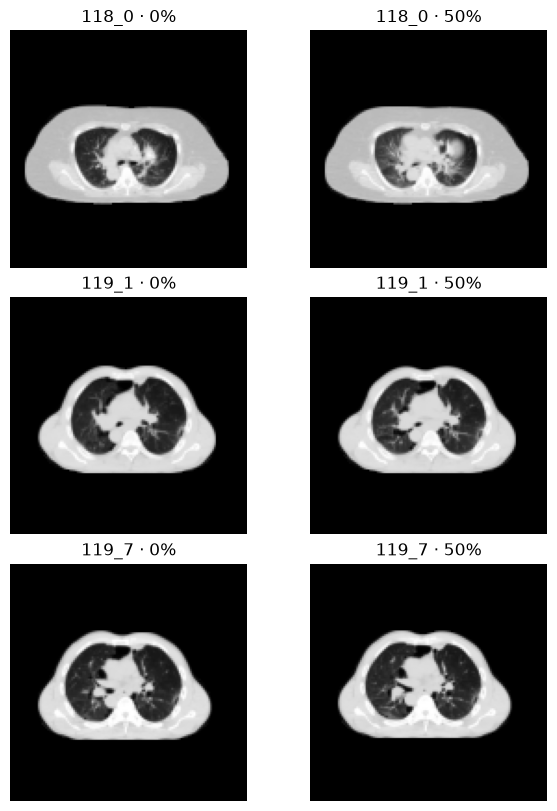

Saved figure: observed_endpoints


In [51]:
def save_figure(fig, name):
    # Make saved figures independent of the notebook/IDE dark theme.
    fig.patch.set_facecolor("white")

    if fig._suptitle is not None:
        fig._suptitle.set_color("black")

    for ax in fig.axes:
        ax.set_facecolor("white")

        ax.title.set_color("black")
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.tick_params(colors="black")

        for spine in ax.spines.values():
            spine.set_edgecolor("black")

        legend = ax.get_legend()
        if legend is not None:
            legend.get_frame().set_facecolor("white")
            legend.get_frame().set_edgecolor("black")
            for text in legend.get_texts():
                text.set_color("black")

        # Tables need explicit text coloring when created under a dark style.
        for table in ax.tables:
            for cell in table.get_celld().values():
                cell.get_text().set_color("black")

    for extension in ["png", "pdf"]:
        fig.savefig(
            ROOT / "figures" / f"{name}.{extension}",
            dpi=300,
            bbox_inches="tight",
            facecolor="white",
        )

    plt.show()
    plt.close(fig)
    print("Saved figure:", name)


fig, axes = plt.subplots(len(QUALITATIVE_CASES), 2, figsize=(6, 8), constrained_layout=True)
for row, case in enumerate(QUALITATIVE_CASES):
    for col, phase in enumerate([0, 50]):
        volume = np.load(ROOT / "prepared" / case / f"phase_{phase:02d}.npy", mmap_mode="r")
        axes[row, col].imshow(volume[QUALITATIVE_SLICE], cmap="gray", vmin=0, vmax=1)
        axes[row, col].set_title(f"{case} · {phase}%")
        axes[row, col].axis("off")
save_figure(fig, "observed_endpoints")


In [29]:
for case in TEST_CASES:
    run_worker("canonical", case)
print("All canonical models are ready.")


Starting: canonical 118_0 
Running: /home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/bin/python /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical/benchmark_118_0/phase00_iter15000/tools/train_with_history.py -s /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical/benchmark_118_0/phase00_iter15000/dataset -m /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical/benchmark_118_0/phase00_iter15000/model --pipeline img --iterations 15000 --save_iterations 15000 --test_iterations 15000 --checkpoint_iterations 15000 --poly_degree 2 --batch_size 3 --camera mirror
torch cuda:  True
Optimizing /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical/benchmark_118_0/phase00_iter15000/model
Training with photometric loss [01/10 18:41:48]
Output folder: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical/benchmark_118_0/phase00_i

## 6. Temporal fitting

Each method starts from a newly initialized temporal network and the same frozen canonical model. The 50% endpoint is the only temporal image target in the baseline and pseudo variants; auxiliary reconstruction in cycle variants also uses 0%. Model choice is the configured final iteration, with no hidden-phase validation.


In [ ]:
for case in TEST_CASES:
    for method in METHODS:
        run_worker("train", case, method)
print("Completed temporal fitting for all six methods on all 14 series.")


Starting: train 118_0 baseline
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**cpu_autocast_kwargs), recompute_context:  # type: ignore[attr-defined]
Iteration 000025/007000 L1=0.112310 SSIM=0.793285 PSNR=13.195
/home/jovyan/shared/mtm_medgs_stack/envs/medgs-worf/lib/python3.11/site-packages/torch/utils/checkpoint.py:1399: FutureWarning: `torch.cpu.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cpu', args...)` instead.
  with device_autocast_ctx, torch.cpu.amp.autocast(**

### Completion audit and training curves

The audit checks 14 canonical checkpoints and 84 final temporal checkpoints, their shared canonical provenance and endpoint-only splits. Training curves are descriptive diagnostics, not a criterion for selecting the best hidden-phase checkpoint.


In [35]:
def temporal_dir(case, method):
    return ROOT / "methods" / f"benchmark_{case}" / method


def audit_training():
    records = []
    for case in TEST_CASES:
        canonical = ROOT / "canonical" / f"benchmark_{case}" / f"phase00_iter{CANONICAL_ITERATIONS}" / "model" / f"chkpnt{CANONICAL_ITERATIONS}.pth"
        assert canonical.is_file()
        canonical_hash = sha256_file(canonical)
        for method in METHODS:
            run = temporal_dir(case, method)
            done = json.loads((run / "completion.json").read_text())
            assert done["iteration"] == TEMPORAL_ITERATIONS
            meta = json.loads((run / "method.json").read_text())
            assert meta["canonical_sha256"] == canonical_hash
            ckpt = run / "checkpoints" / f"deformation_iter_{TEMPORAL_ITERATIONS:06d}.pth"
            assert ckpt.is_file()
            split = pd.read_csv(run / "split_manifest.csv")
            assert set(split.PhasePercent) == {0, 50}
            assert set(split.loc[split.Split == "train", "PhasePercent"]) == {50}
            assert not (split.Split == "validation").any()
            records.append({"Case": case, "Method": method, "Iteration": done["iteration"],
                            "CanonicalSHA256": canonical_hash, "TemporalSHA256": sha256_file(ckpt),
                            "TrainingSeconds": done["elapsed_seconds"], "PrimaryParameters": done["parameter_count"]})
    result = pd.DataFrame(records)
    assert len(result) == 84
    result.to_csv(ROOT / "tables/training_audit.csv", index=False)
    return result

print("Mean training time (seconds) and primary network parameter count across 14 test series, by method:")
training_audit = audit_training()
display(training_audit.groupby("Method", sort=False)[["TrainingSeconds", "PrimaryParameters"]].mean().reindex(METHODS))


Mean training time (seconds) and primary network parameter count across 14 test series, by method:


,TrainingSeconds,PrimaryParameters
Method,,
baseline,1440.259850,206339.0
linear_pseudo,1559.287749,206339.0
cycle_v2,2860.957697,206339.0
trajectory,1090.060038,272646.0
consistent_cycle,2593.795686,206339.0
trajectory_cycle,2045.205382,272646.0


Observed 50% endpoint training curves: mean L1 and PSNR across 14 test series, smoothed with a 100-iteration rolling window:


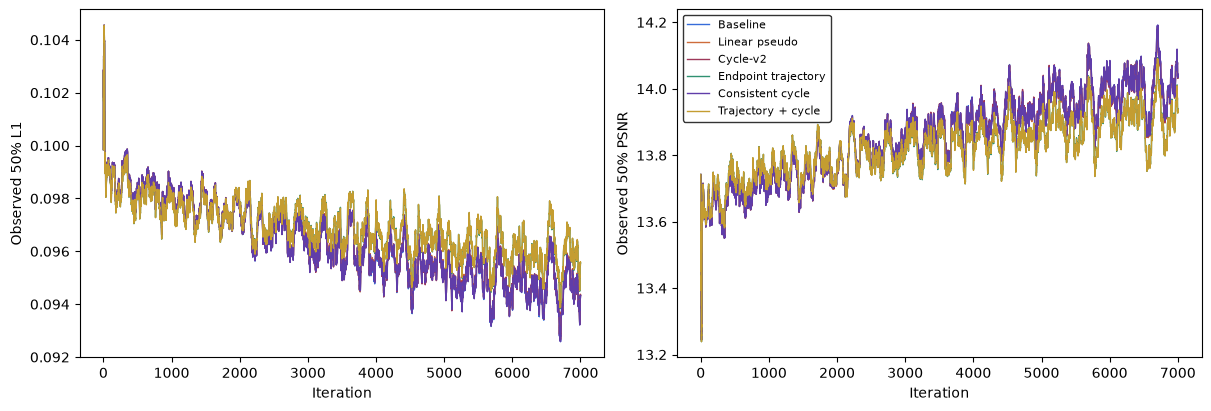

Saved figure: endpoint_training_curves


In [52]:
print("Observed 50% endpoint training curves: mean L1 and PSNR across 14 test series, smoothed with a 100-iteration rolling window:")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for method in METHODS:
    histories = []
    for case in TEST_CASES:
        h = pd.read_csv(temporal_dir(case, method) / "training_history.csv")
        histories.append(h.set_index("Iteration")[["L1", "PSNR"]])
    mean_history = pd.concat(histories).groupby(level=0).mean().rolling(100, min_periods=1).mean()
    for axis, metric in zip(axes, ["L1", "PSNR"]):
        axis.plot(mean_history.index, mean_history[metric], label=LABELS[method], linewidth=1)
        axis.set(xlabel="Iteration", ylabel=f"Observed 50% {metric}")
axes[1].legend(fontsize=8)
save_figure(fig, "endpoint_training_curves")


## 7. Frozen predictions

The final primary fields render 336 hidden-phase volumes: 14 series × 6 methods × 4 phases. Predictions are saved in `(Z,Y,X)` order with checkpoint hashes, render time and GPU allocator peak. Ground truth is still not accessed.


In [37]:
print("Rendering 336 intermediate-phase volumes: 14 test series × 6 methods × 4 phases (10%, 20%, 30%, 40%) from the final checkpoints:")
for case in TEST_CASES:
    for method in METHODS:
        run_worker("render", case, method)
print("All 336 predictions are ready.")


Rendering 336 intermediate-phase volumes: 14 test series × 6 methods × 4 phases (10%, 20%, 30%, 40%) from the final checkpoints:
Starting: render 118_0 baseline
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
118_0 baseline 10% rendered
118_0 baseline 20% rendered
118_0 baseline 30% rendered
118_0 baseline 40% rendered
Starting: render 118_0 linear_pseudo
Distance: 1.0
Loading trained model at iteration 15000
Creating Training Transforms
Creating Test Transforms
AAAAA radius 1.1
AAAAA translate [-0. -0. -0.] center [0. 0. 0.]
Generating random point cloud (100000)...
Loading Training Cameras
Loading Test Cameras
118_0 linear_pseudo 10% rendered
118_0 linear_pseudo 20% rendered
118_0 linear_pseudo 30% rendered
118_0 linear_pseudo 40% rendered
Starting: render 118_0 cycle_v2
Di

## 8. Full-volume evaluation

The models are now frozen. Each predicted volume is compared with its matching CT volume using the UVI-Net metric definitions:
\[
\operatorname{PSNR}=-10\log_{10}(\operatorname{MSE}),\qquad
\operatorname{NMSE}[\%]=100\frac{\operatorname{MSE}}{\operatorname{mean}(I^2)}.
\]
NCC is the mean squared local correlation with a $9^3$ box window and denominator stabilizer $10^{-5}$. SSIM uses an $11^3$ Gaussian window, $\sigma=1.5$, $C_1=0.01^2$, $C_2=0.03^2$. Both use zero padding. These are **volume metrics**, not averages of slice metrics. There is no ROI mask or per-volume intensity rescaling.

The main table averages 56 case–phase measurements per method and follows the [official AverageMeter](https://github.com/jungeun122333/UVI-Net/blob/main/utils/utils.py): population standard deviation divided by $\sqrt{56}$ (`ddof=0`). Sample-SD standard error (`ddof=1`) is also exported explicitly. Case–phase entries are correlated within patients: these descriptive errors are not patient-level confidence intervals. Per-case, per-phase and per-patient tables are retained.


In [38]:
print("Evaluation setup: full-volume 3D SSIM and NCC definitions and metric computation device.")
METRIC_DEVICE = torch.device(f"cuda:{GPU_INDEX}")
torch.cuda.set_device(METRIC_DEVICE)


def gaussian_1d(window_size=11, sigma=1.5):
    values = torch.tensor([math.exp(-(x - window_size // 2) ** 2 / (2 * sigma ** 2)) for x in range(window_size)])
    return values / values.sum()


def ssim3d(original, generated, window_size=11):
    one_d = gaussian_1d(window_size).to(original.device, original.dtype)
    two_d = one_d[:, None] * one_d[None, :]
    window = one_d[:, None, None] * two_d[None, :, :]
    window = window[None, None, ...]
    padding = window_size // 2
    mu1 = F.conv3d(original, window, padding=padding)
    mu2 = F.conv3d(generated, window, padding=padding)
    mu1_sq = mu1.square()
    mu2_sq = mu2.square()
    mu12 = mu1 * mu2
    sigma1_sq = F.conv3d(original.square(), window, padding=padding) - mu1_sq
    sigma2_sq = F.conv3d(generated.square(), window, padding=padding) - mu2_sq
    sigma12 = F.conv3d(original * generated, window, padding=padding) - mu12
    c1 = 0.01 ** 2
    c2 = 0.03 ** 2
    score = (2 * mu12 + c1) * (2 * sigma12 + c2) / ((mu1_sq + mu2_sq + c1) * (sigma1_sq + sigma2_sq + c2))
    return score.mean()


def ncc3d(original, generated, window_size=9):
    window = torch.ones(1, 1, window_size, window_size, window_size, device=original.device, dtype=original.dtype)
    padding = window_size // 2
    window_volume = window_size ** 3
    original_sum = F.conv3d(original, window, padding=padding)
    generated_sum = F.conv3d(generated, window, padding=padding)
    original_sq_sum = F.conv3d(original.square(), window, padding=padding)
    generated_sq_sum = F.conv3d(generated.square(), window, padding=padding)
    cross_sum = F.conv3d(original * generated, window, padding=padding)
    mean_original = original_sum / window_volume
    mean_generated = generated_sum / window_volume
    cross = cross_sum - mean_generated * original_sum - mean_original * generated_sum + mean_original * mean_generated * window_volume
    var_original = original_sq_sum - 2 * mean_original * original_sum + mean_original.square() * window_volume
    var_generated = generated_sq_sum - 2 * mean_generated * generated_sum + mean_generated.square() * window_volume
    return (cross.square() / (var_original * var_generated + 1e-05)).mean()


Evaluation setup: full-volume 3D SSIM and NCC definitions and metric computation device.


In [39]:
@torch.no_grad()
def evaluate_volume(gt, prediction):
    assert gt.shape == prediction.shape == (128, 128, 128)
    assert np.isfinite(gt).all() and np.isfinite(prediction).all()
    a = torch.as_tensor(np.ascontiguousarray(gt), dtype=torch.float32, device=METRIC_DEVICE)[None, None]
    b = torch.as_tensor(np.ascontiguousarray(prediction), dtype=torch.float32, device=METRIC_DEVICE)[None, None]
    mse = ((a - b) ** 2).mean()
    energy = a.square().mean()
    assert energy > 0
    return {"PSNR": float(-10 * torch.log10(mse)), "NCC": float(ncc3d(a, b)),
            "SSIM": float(ssim3d(a, b)), "NMSE": float(100 * mse / energy)}


# Metric identities on synthetic tensors; NCC need not be exactly 1 because of epsilon.
x = torch.rand(1, 1, 17, 17, 17, device=METRIC_DEVICE)
assert abs(float(ssim3d(x, x)) - 1) < 1e-6
assert float(ncc3d(x, x)) > 0.999
assert torch.isfinite(ssim3d(torch.zeros_like(x), torch.zeros_like(x)))
print("Metric identity checks passed.")


Metric identity checks passed.


In [40]:
# This is the first section that reads intermediate CT ground truth.
print("Evaluating 336 predicted volumes against held-out CT phases: full-volume PSNR, NCC, SSIM and NMSE (%).")
training_audit = audit_training()
for case in TEST_CASES:
    for method in METHODS:
        assert (ROOT / "predictions" / case / method / "render.json").is_file()

rows, ground_truth_sources = [], []
for case in TEST_CASES:
    reference = json.loads((ROOT / "prepared" / case / "observed_sources.json").read_text())
    for phase in PHASES:
        path = DATA_ROOT / case / f"ct_{case}_frame{phase // 10}.nii.gz"
        image = nib.load(str(path))
        assert np.allclose(image.affine, reference["headers"]["0"]["affine"])
        gt = image.get_fdata(dtype=np.float32).transpose(2, 1, 0).copy()
        assert np.isfinite(gt).all() and gt.min() >= -1e-6 and gt.max() <= 1 + 1e-6
        ground_truth_sources.append({"Case": case, "Phase": phase, "Path": str(path), "SHA256": sha256_file(path)})
        for method in METHODS:
            directory = ROOT / "predictions" / case / method
            prediction_path = directory / f"phase_{phase:02d}.npy"
            render = json.loads((directory / "render.json").read_text())
            assert sha256_file(prediction_path) == render["prediction_sha256"][str(phase)]
            score = evaluate_volume(gt, np.load(prediction_path))
            rows.append({"Case": case, "Patient": case.split("_")[0], "Phase": phase, "Method": method, **score})
        pd.DataFrame(rows).to_csv(ROOT / "metrics/per_case_phase.csv", index=False)
    print("Evaluated:", case)
metrics = pd.DataFrame(rows)
assert len(metrics) == 336
assert not metrics.duplicated(["Case", "Phase", "Method"]).any()
assert metrics.groupby("Method").size().eq(56).all()
write_json(ROOT / "metrics/ground_truth_sources.json", {"files": ground_truth_sources})
print("Evaluation complete:", len(metrics), "volumes.")


Evaluating 336 predicted volumes against held-out CT phases: full-volume PSNR, NCC, SSIM and NMSE (%).
Evaluated: 118_0
Evaluated: 118_1
Evaluated: 118_2
Evaluated: 118_3
Evaluated: 118_4
Evaluated: 118_5
Evaluated: 119_0
Evaluated: 119_1
Evaluated: 119_2
Evaluated: 119_3
Evaluated: 119_4
Evaluated: 119_5
Evaluated: 119_6
Evaluated: 119_7
Evaluation complete: 336 volumes.


## 9. Benchmark tables

The main table preserves all official test series. The exclusion of `118_0` is supplementary. No UVI-Net score is inserted automatically: external published values should be labeled with their source and setting, separately from results generated by this run.


In [41]:
METRICS = ["PSNR", "NCC", "SSIM", "NMSE"]


def summary_table(frame):
    rows = []
    for method in METHODS:
        group = frame.loc[frame.Method == method]
        row = {"Method": method, "N": len(group)}
        for metric in METRICS:
            values = group[metric].to_numpy()
            row[metric + "_mean"] = float(values.mean())
            row[metric + "_SE"] = float(values.std(ddof=0) / np.sqrt(len(values)))
            row[metric + "_SE_ddof1"] = float(values.std(ddof=1) / np.sqrt(len(values)))
        rows.append(row)
    return pd.DataFrame(rows)


summary = summary_table(metrics)
summary.to_csv(ROOT / "tables/overall_numeric.csv", index=False)
formatted = pd.DataFrame({"Method": [LABELS[m] for m in METHODS]})
for metric, title in zip(METRICS, ["PSNR ↑", "NCC ↑", "SSIM ↑", "NMSE (%) ↓"]):
    formatted[title] = [f"{r[metric + '_mean']:.3f} ± {r[metric + '_SE']:.3f}" for r in summary.to_dict("records")]
formatted.to_csv(ROOT / "tables/main_table.csv", index=False)
(ROOT / "tables/main_table.tex").write_text(formatted.to_latex(index=False, escape=True))

display(formatted)
summary_table(metrics.loc[metrics.Case != "118_0"]).to_csv(ROOT / "tables/sensitivity_without_118_0.csv", index=False)
for keys, name in [(["Method", "Case"], "per_case"), (["Method", "Phase"], "per_phase"),
                   (["Method", "Patient"], "per_patient")]:
    metrics.groupby(keys, sort=False)[METRICS].mean().reset_index().to_csv(ROOT / "tables" / f"{name}.csv", index=False)

# Paired descriptive differences on exactly the same cases and phases.
base = metrics.loc[metrics.Method == "baseline"].set_index(["Case", "Phase"])[METRICS]
differences = []
for method in METHODS[1:]:
    other = metrics.loc[metrics.Method == method].set_index(["Case", "Phase"])[METRICS]
    delta = other.subtract(base).reset_index()
    delta["Method"] = method
    differences.append(delta)
pd.concat(differences).to_csv(ROOT / "tables/paired_differences_from_baseline.csv", index=False)
print("Tables saved:", ROOT / "tables")


Intermediate-phase reconstruction results: mean ± standard error over 56 volumes per method (14 test series × 4 phases). Higher PSNR, NCC and SSIM are better; lower NMSE (%) is better:


,Method,PSNR ↑,NCC ↑,SSIM ↑,NMSE (%) ↓
0,Baseline,13.189 ± 0.079,0.147 ± 0.005,0.709 ± 0.012,34.013 ± 0.607
1,Linear pseudo,13.879 ± 0.075,0.216 ± 0.003,0.830 ± 0.003,28.841 ± 0.281
2,Cycle-v2,13.891 ± 0.074,0.216 ± 0.003,0.840 ± 0.002,28.761 ± 0.285
3,Endpoint trajectory,13.810 ± 0.074,0.211 ± 0.002,0.824 ± 0.003,29.300 ± 0.282
4,Consistent cycle,13.928 ± 0.076,0.221 ± 0.003,0.845 ± 0.002,28.520 ± 0.289
5,Trajectory + cycle,13.834 ± 0.075,0.211 ± 0.002,0.832 ± 0.003,29.147 ± 0.290


Tables saved: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/tables


Rendering and saving the publication-ready summary table for the six reconstruction methods.


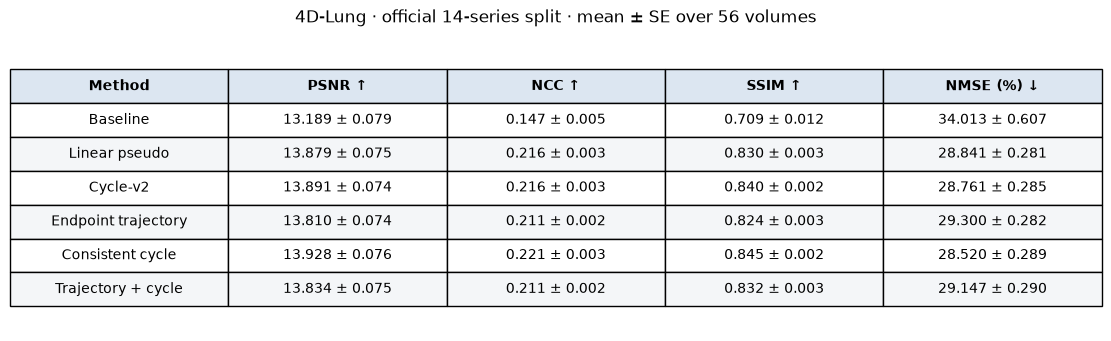

Saved figure: main_table


In [53]:
print("Rendering and saving the publication-ready summary table for the six reconstruction methods.")
fig, ax = plt.subplots(figsize=(11, 3.3), constrained_layout=True)
fig.patch.set_facecolor("white")
ax.set_facecolor("white")
ax.axis("off")
table = ax.table(cellText=formatted.values, colLabels=formatted.columns, loc="center", cellLoc="center")
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.8)
for (row, col), cell in table.get_celld().items():
    cell.set_text_props(color="black")
    if row == 0:
        cell.set_facecolor("#dce6f1")
        cell.set_text_props(weight="bold")
    elif row % 2 == 0:
        cell.set_facecolor("#f4f6f8")
ax.set_title(
    "4D-Lung · official 14-series split · mean ± SE over 56 volumes",
    pad=16,
    color="black",
)
save_figure(fig, "main_table")


### Metrics by respiratory phase

Each point is the mean over the same 14 series. Error bars show sample standard error over those series and are descriptive because several series share a patient.


Plotting phase-wise reconstruction quality: mean ± SE across 14 held-out series for all six methods.


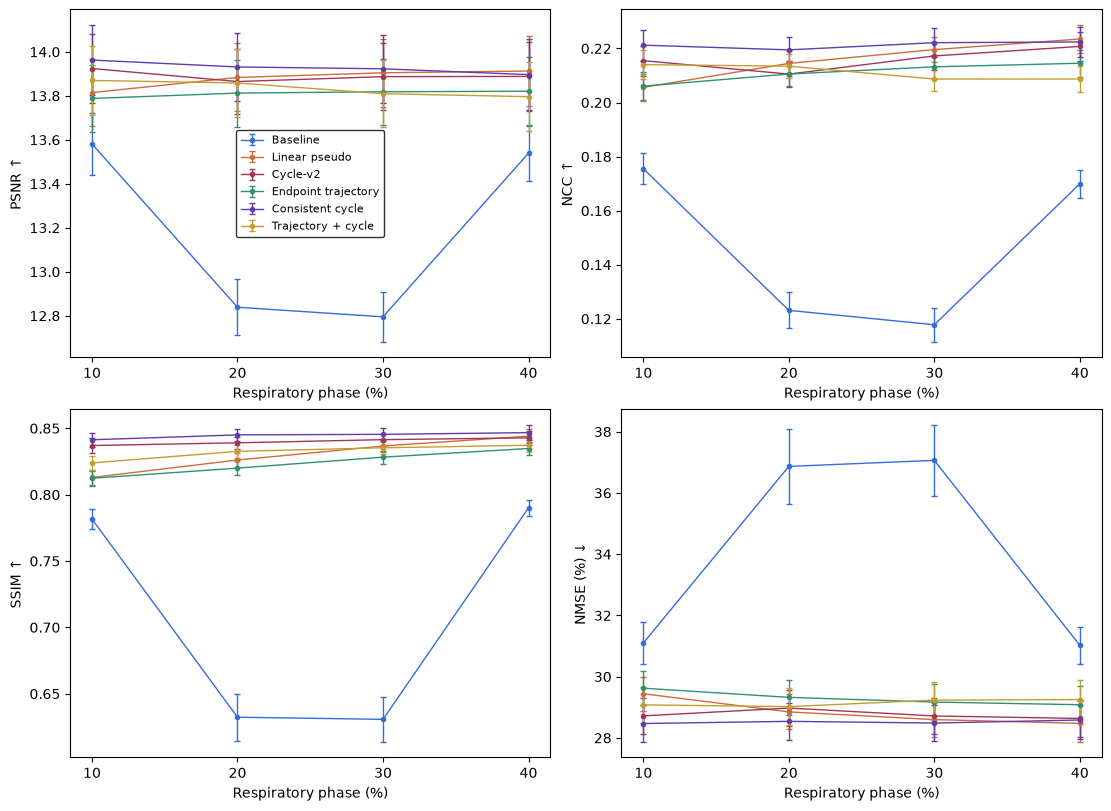

Saved figure: metrics_by_phase


In [54]:
print("Plotting phase-wise reconstruction quality: mean ± SE across 14 held-out series for all six methods.")
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for axis, metric in zip(axes.flat, METRICS):
    for method in METHODS:
        group = metrics.loc[metrics.Method == method].groupby("Phase")[metric]
        axis.errorbar(PHASES, group.mean().reindex(PHASES), yerr=group.sem().reindex(PHASES),
                      marker="o", markersize=3, capsize=2, linewidth=1, label=LABELS[method])
    axis.set(xlabel="Respiratory phase (%)", ylabel=metric + (" (%) ↓" if metric == "NMSE" else " ↑"), xticks=PHASES)
axes[0, 0].legend(fontsize=8)
save_figure(fig, "metrics_by_phase")


## 10. Qualitative comparison

The cases and slice were fixed before evaluation. Images share `[0,1]`; absolute errors share `[0,0.2]`. Figures show all methods and all four hidden phases, with the same ordering and scale. They are not selected from the best-scoring results.


Generating qualitative reconstruction grids and absolute-error maps for the selected held-out cases.


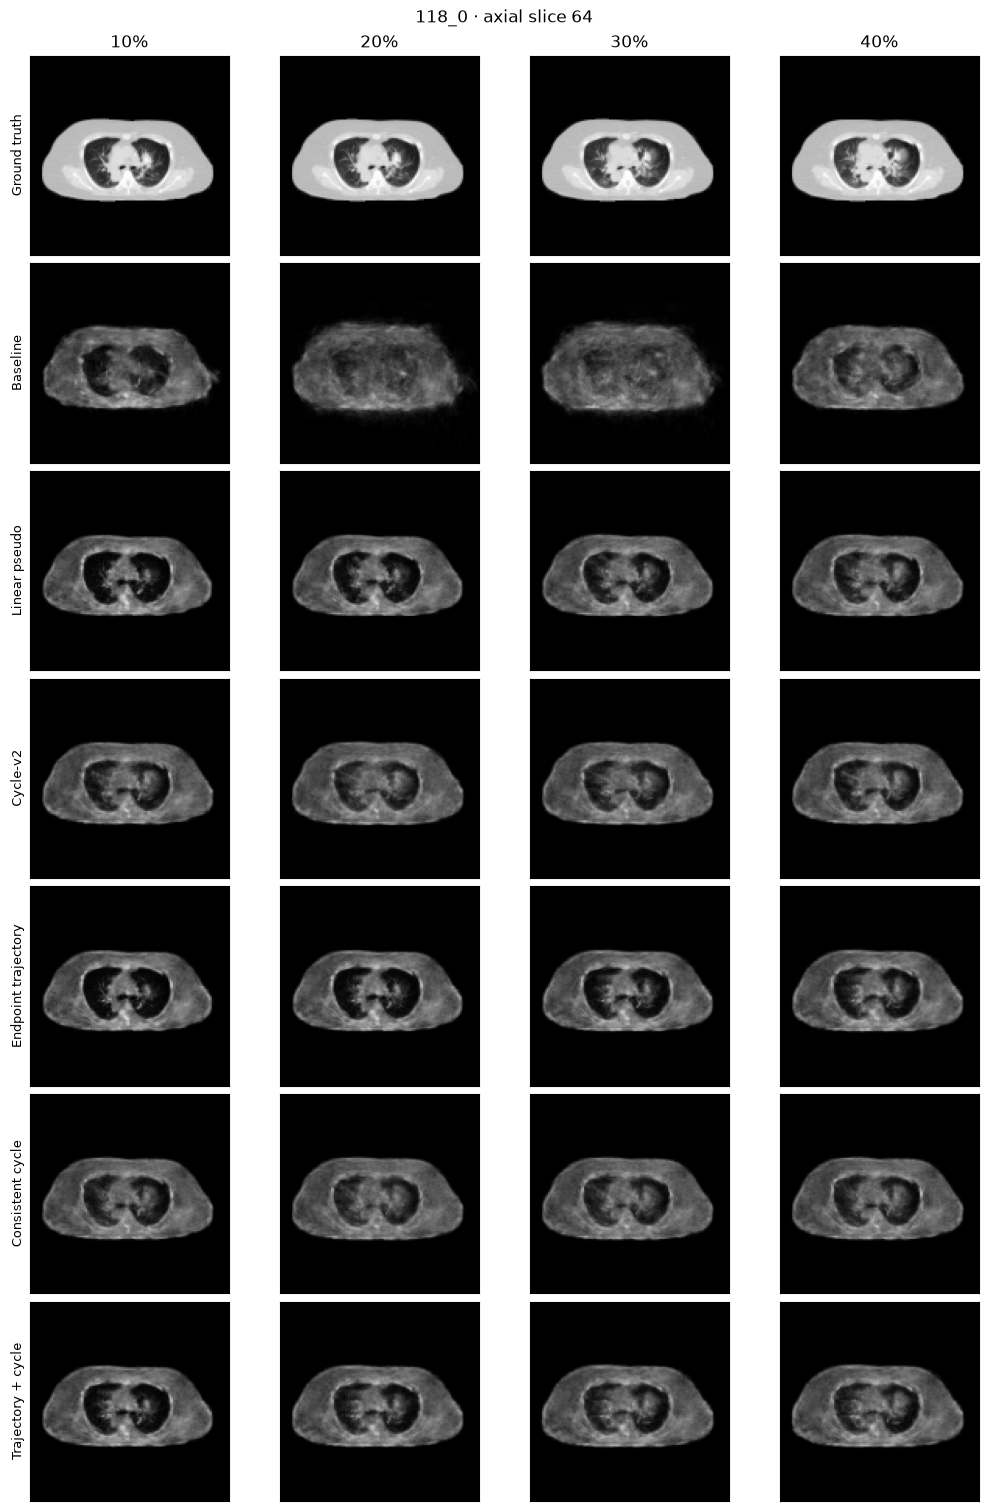

Saved figure: reconstruction_118_0


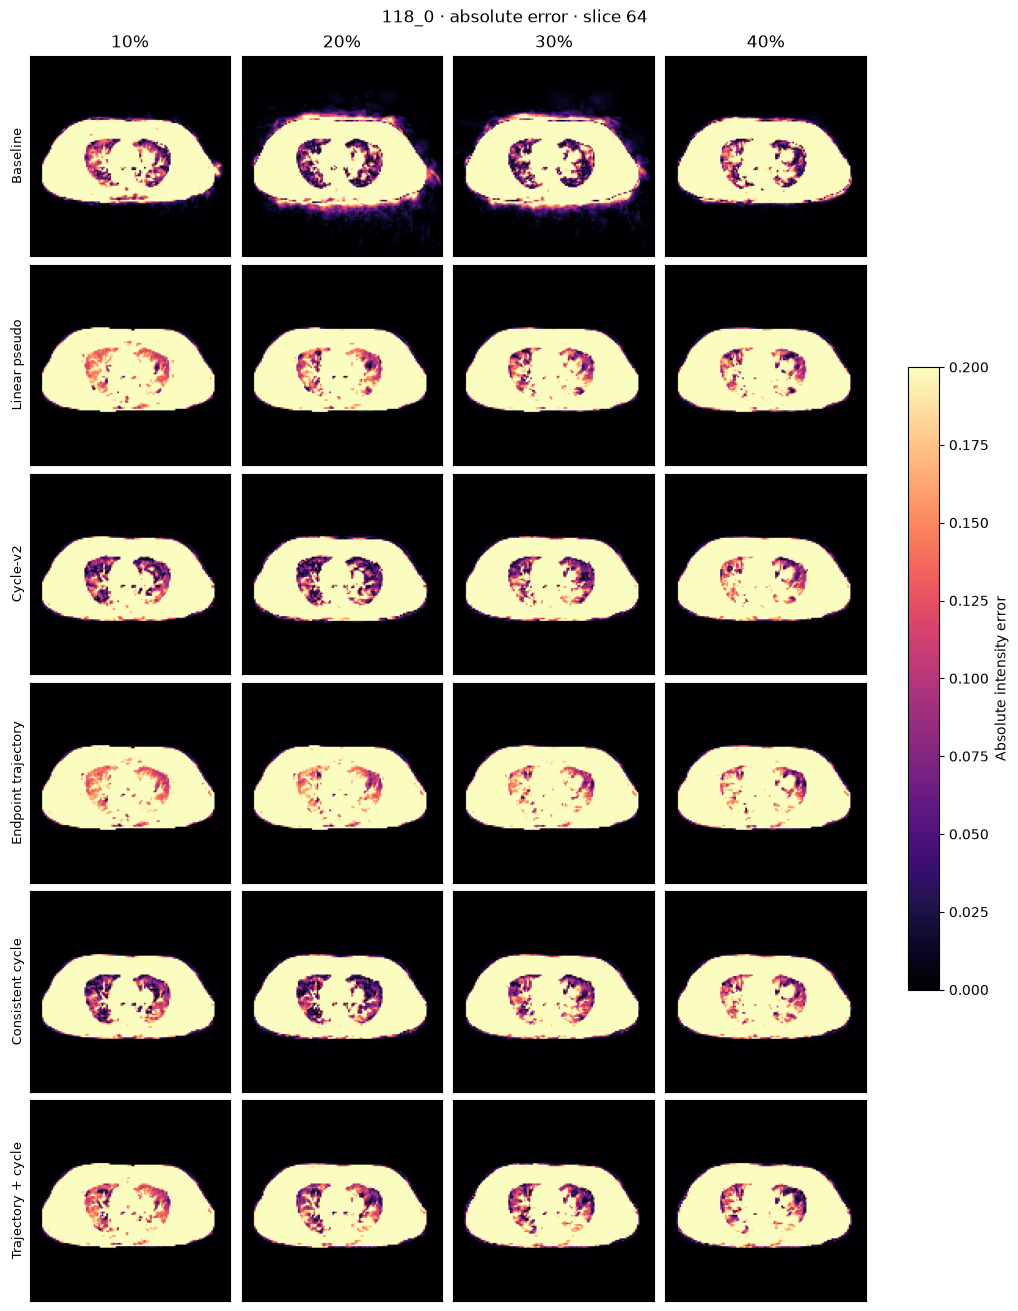

Saved figure: absolute_error_118_0


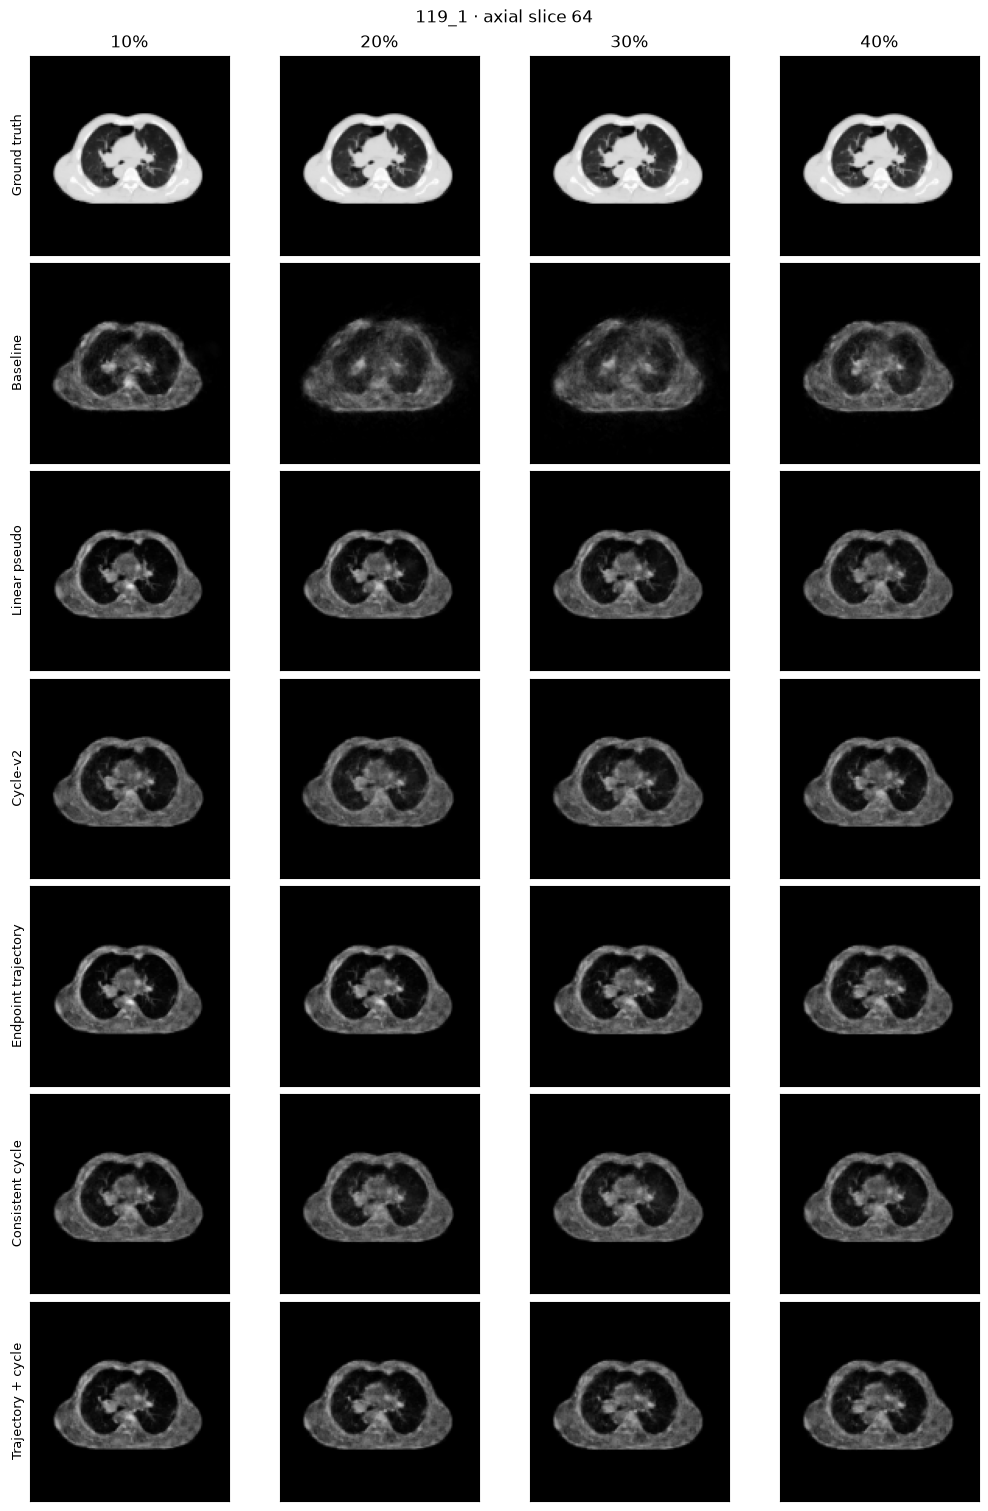

Saved figure: reconstruction_119_1


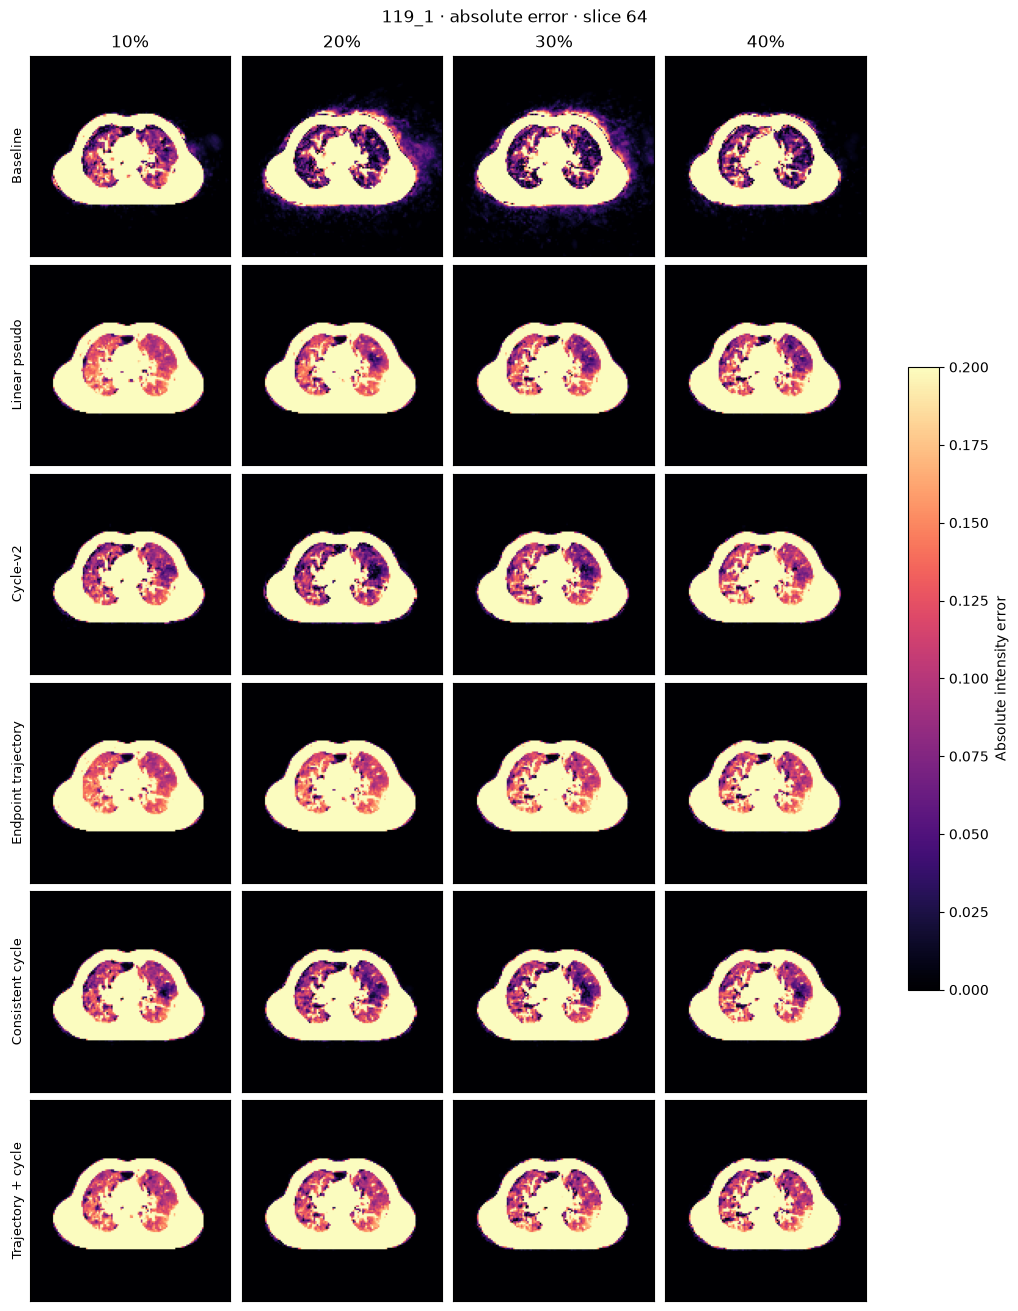

Saved figure: absolute_error_119_1


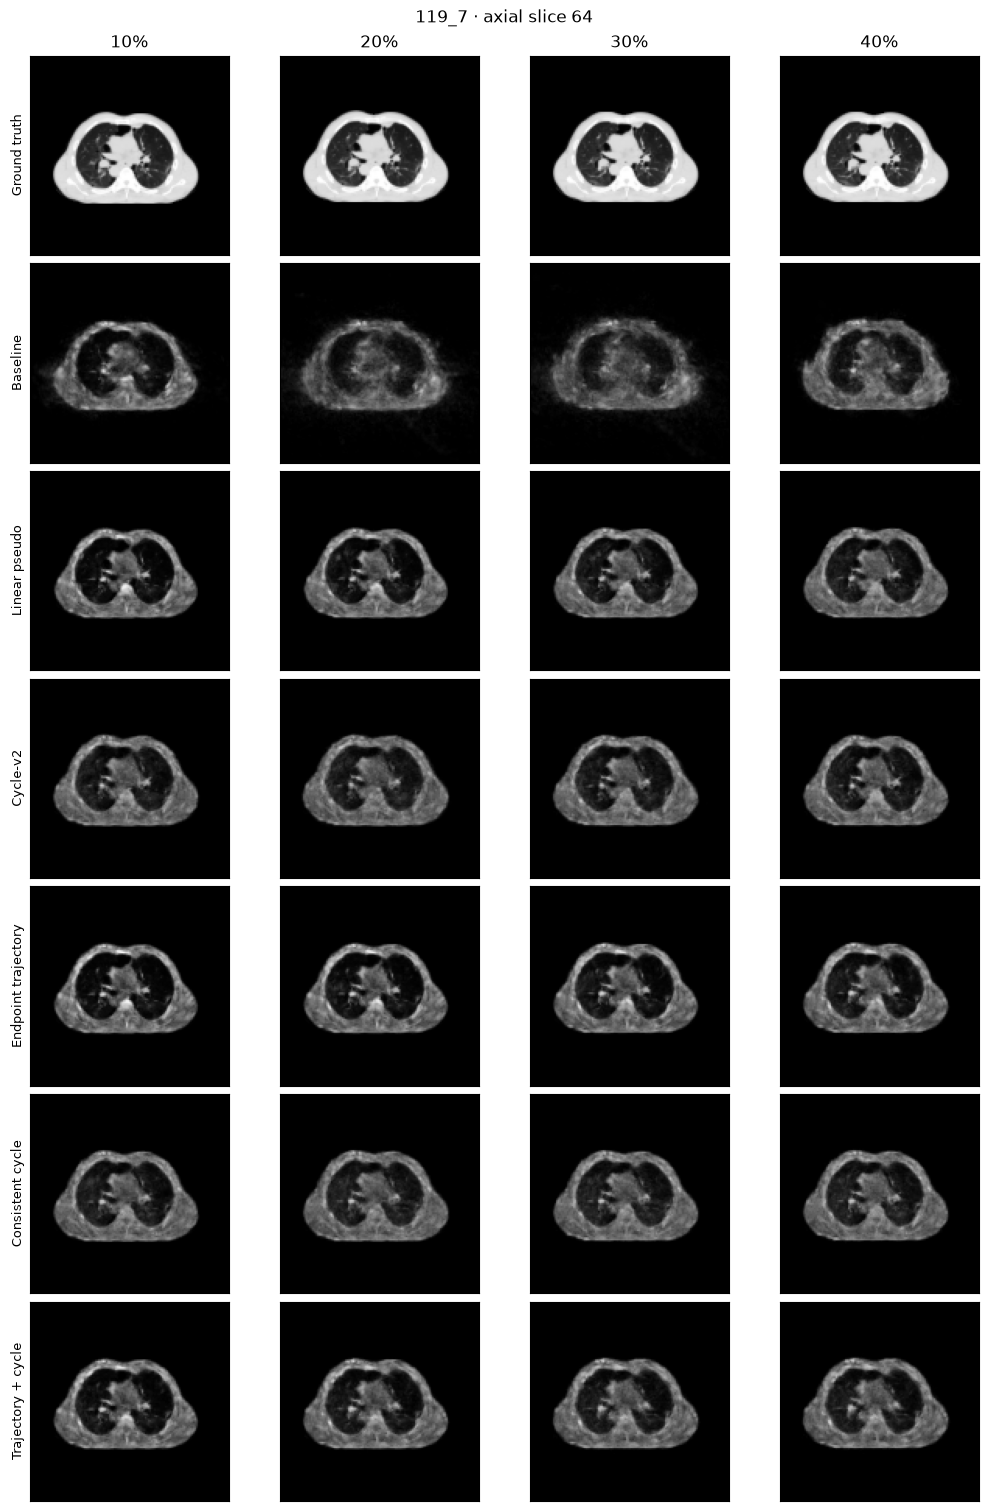

Saved figure: reconstruction_119_7


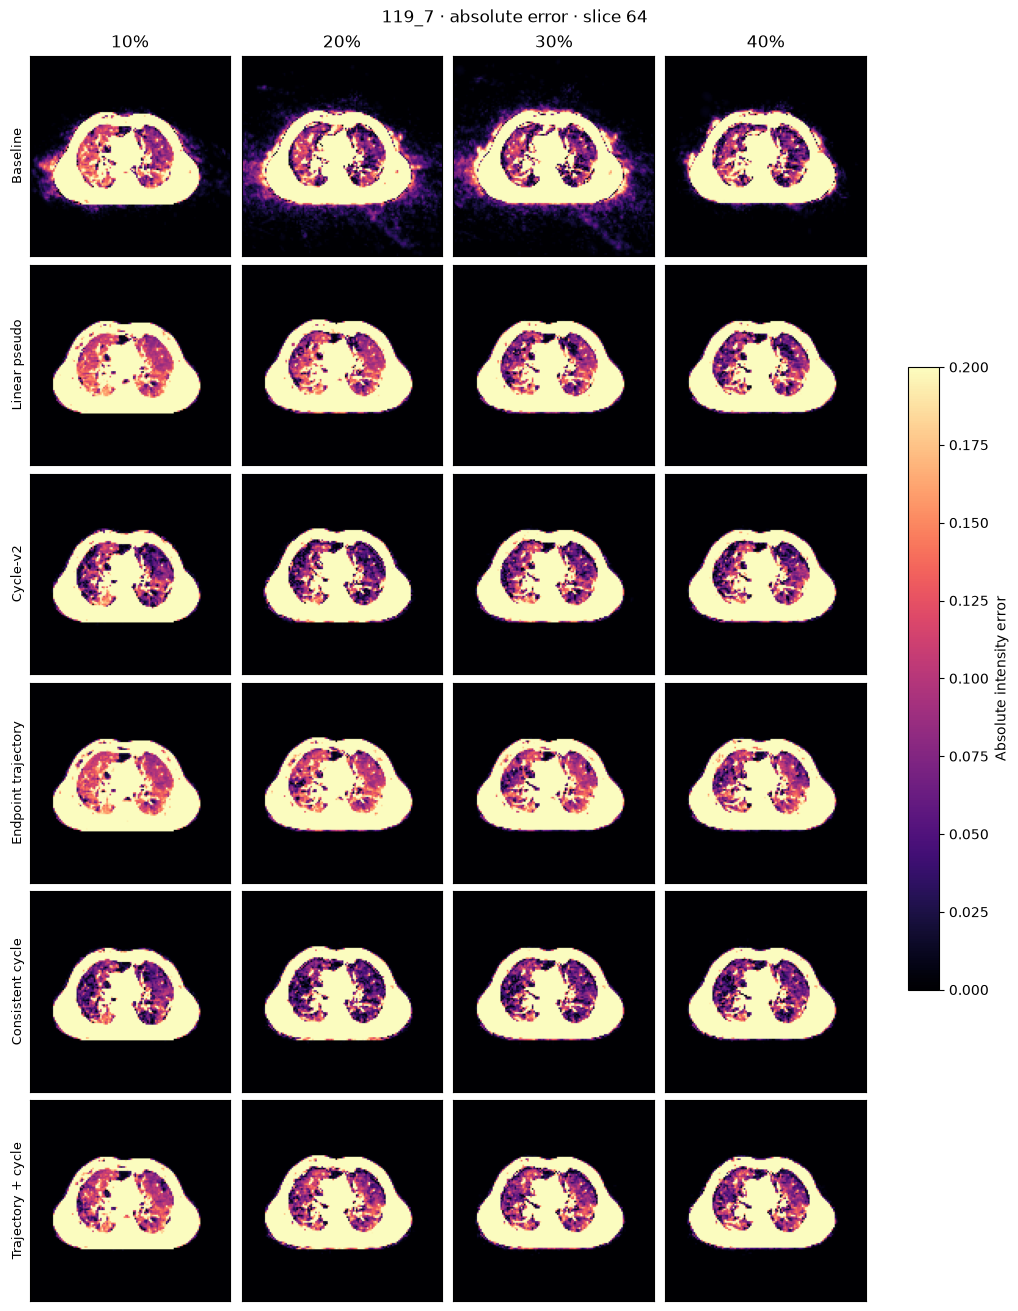

Saved figure: absolute_error_119_7


In [57]:
print("Generating qualitative reconstruction grids and absolute-error maps for the selected held-out cases.")
for case in QUALITATIVE_CASES:
    gt = {}
    for phase in PHASES:
        path = DATA_ROOT / case / f"ct_{case}_frame{phase // 10}.nii.gz"
        gt[phase] = nib.load(str(path)).get_fdata(dtype=np.float32).transpose(2, 1, 0)[QUALITATIVE_SLICE]
    fig, axes = plt.subplots(7, 4, figsize=(10, 15), constrained_layout=True)
    for col, phase in enumerate(PHASES):
        axes[0, col].imshow(gt[phase], cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"{phase}%")
        for row, method in enumerate(METHODS, start=1):
            p = np.load(ROOT / "predictions" / case / method / f"phase_{phase:02d}.npy", mmap_mode="r")
            axes[row, col].imshow(p[QUALITATIVE_SLICE], cmap="gray", vmin=0, vmax=1)
    for row, label in enumerate(["Ground truth"] + [LABELS[m] for m in METHODS]):
        axes[row, 0].set_ylabel(label, fontsize=9)
    for ax in axes.flat:
        ax.set_xticks([]);
        ax.set_yticks([])
    fig.suptitle(f"{case} · axial slice {QUALITATIVE_SLICE}")
    save_figure(fig, f"reconstruction_{case}")

    fig, axes = plt.subplots(6, 4, figsize=(10, 13), constrained_layout=True)
    for row, method in enumerate(METHODS):
        for col, phase in enumerate(PHASES):
            p = np.load(ROOT / "predictions" / case / method / f"phase_{phase:02d}.npy", mmap_mode="r")
            im = axes[row, col].imshow(np.abs(p[QUALITATIVE_SLICE] - gt[phase]), cmap="magma", vmin=0, vmax=ERROR_VMAX)
            if row == 0:
                axes[row, col].set_title(f"{phase}%")
        axes[row, 0].set_ylabel(LABELS[method], fontsize=9)
    for ax in axes.flat:
        ax.set_xticks([]);
        ax.set_yticks([])
    fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.5, label="Absolute intensity error")
    fig.suptitle(f"{case} · absolute error · slice {QUALITATIVE_SLICE}")
    save_figure(fig, f"absolute_error_{case}")


Generating full-range absolute-error maps on the fixed [0, 1] intensity scale for qualitative diagnostics.


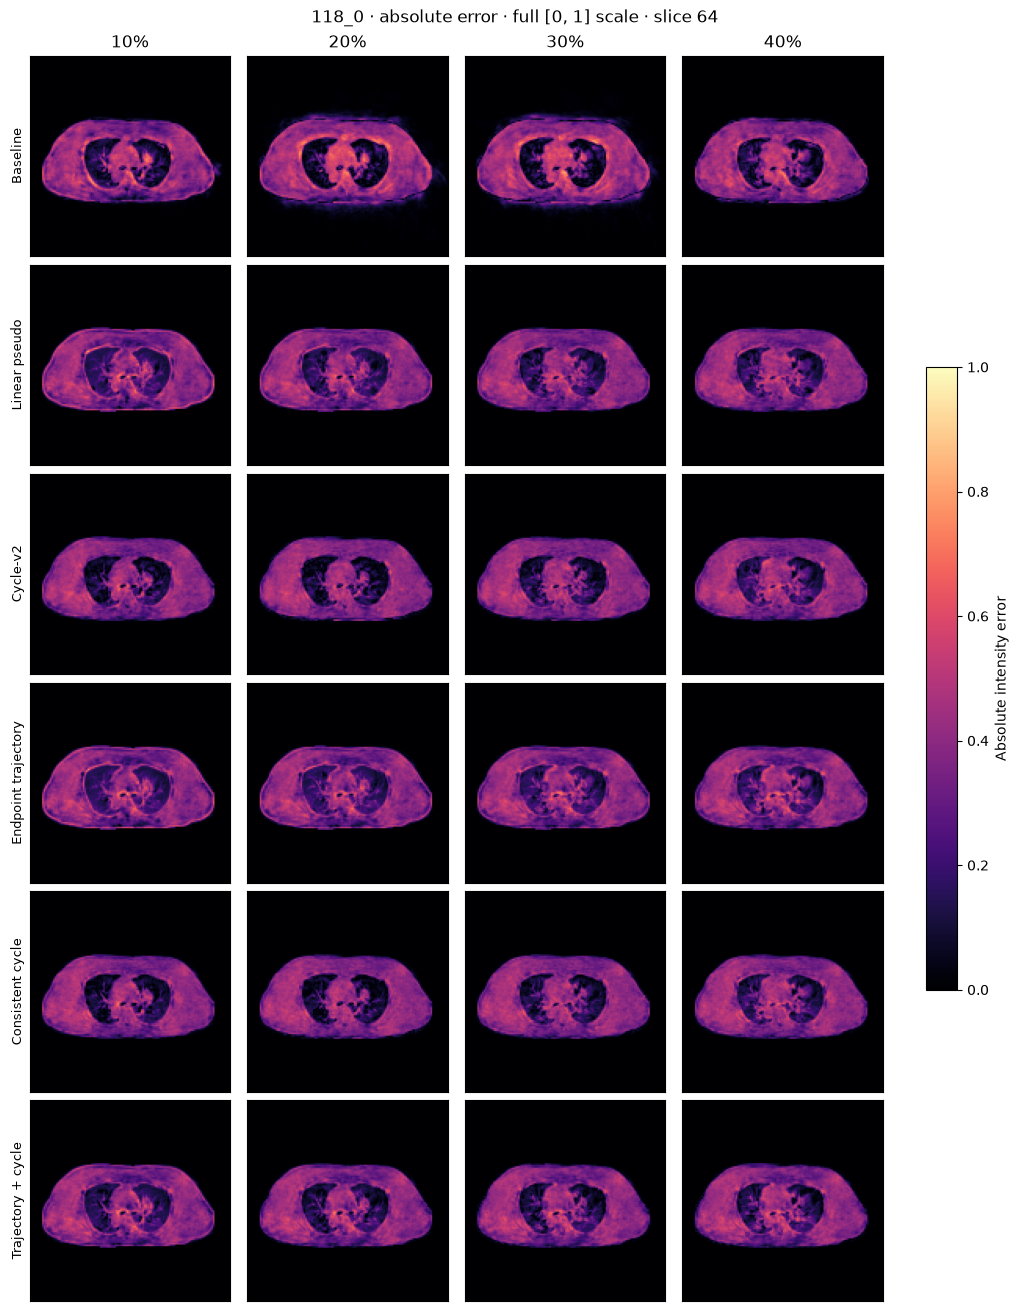

Saved figure: absolute_error_full_range_118_0


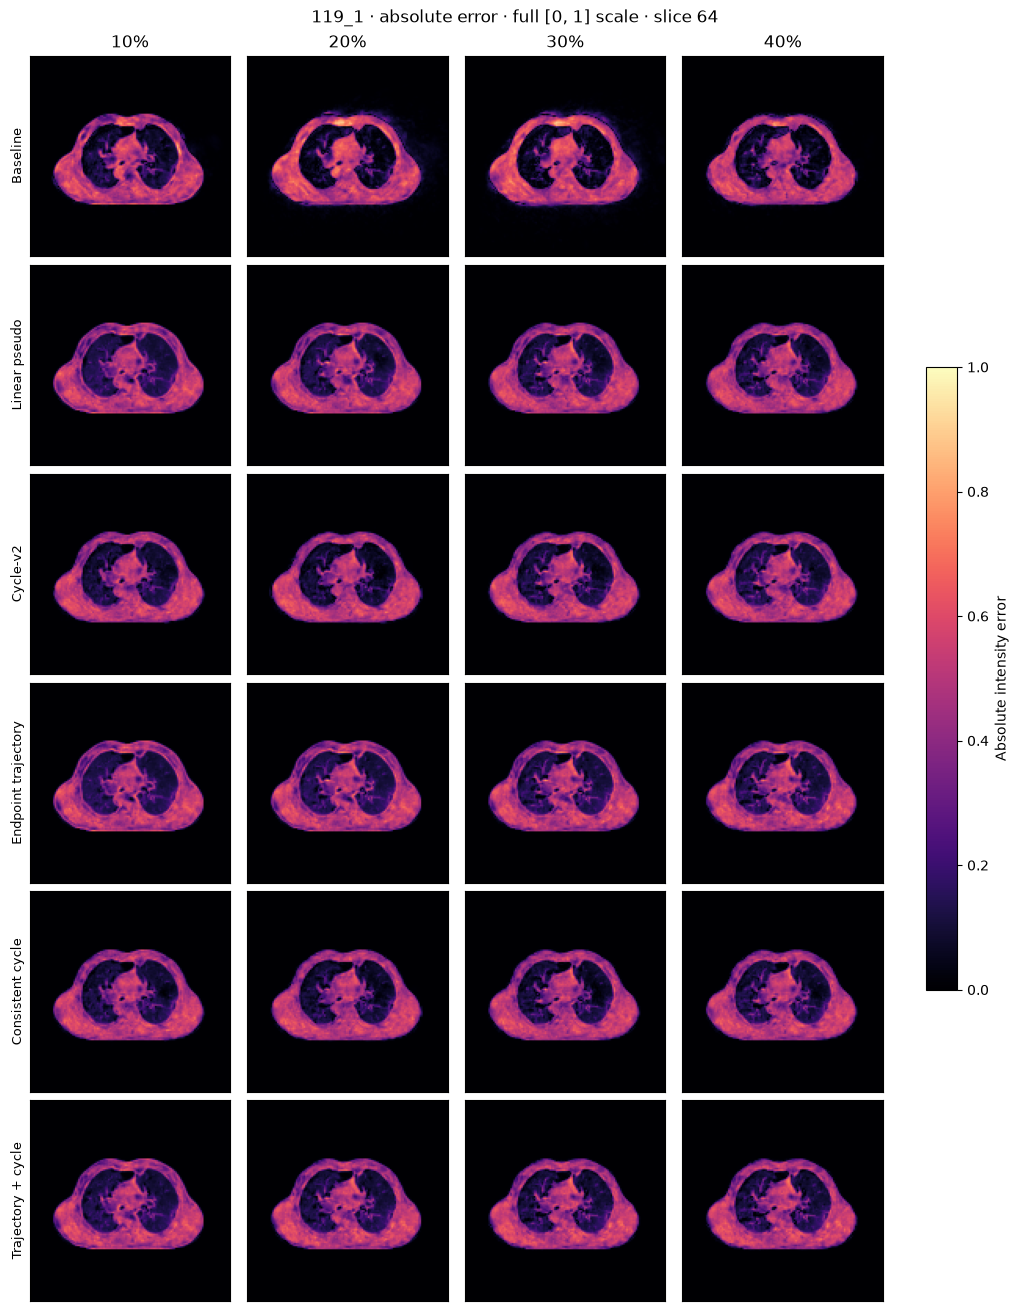

Saved figure: absolute_error_full_range_119_1


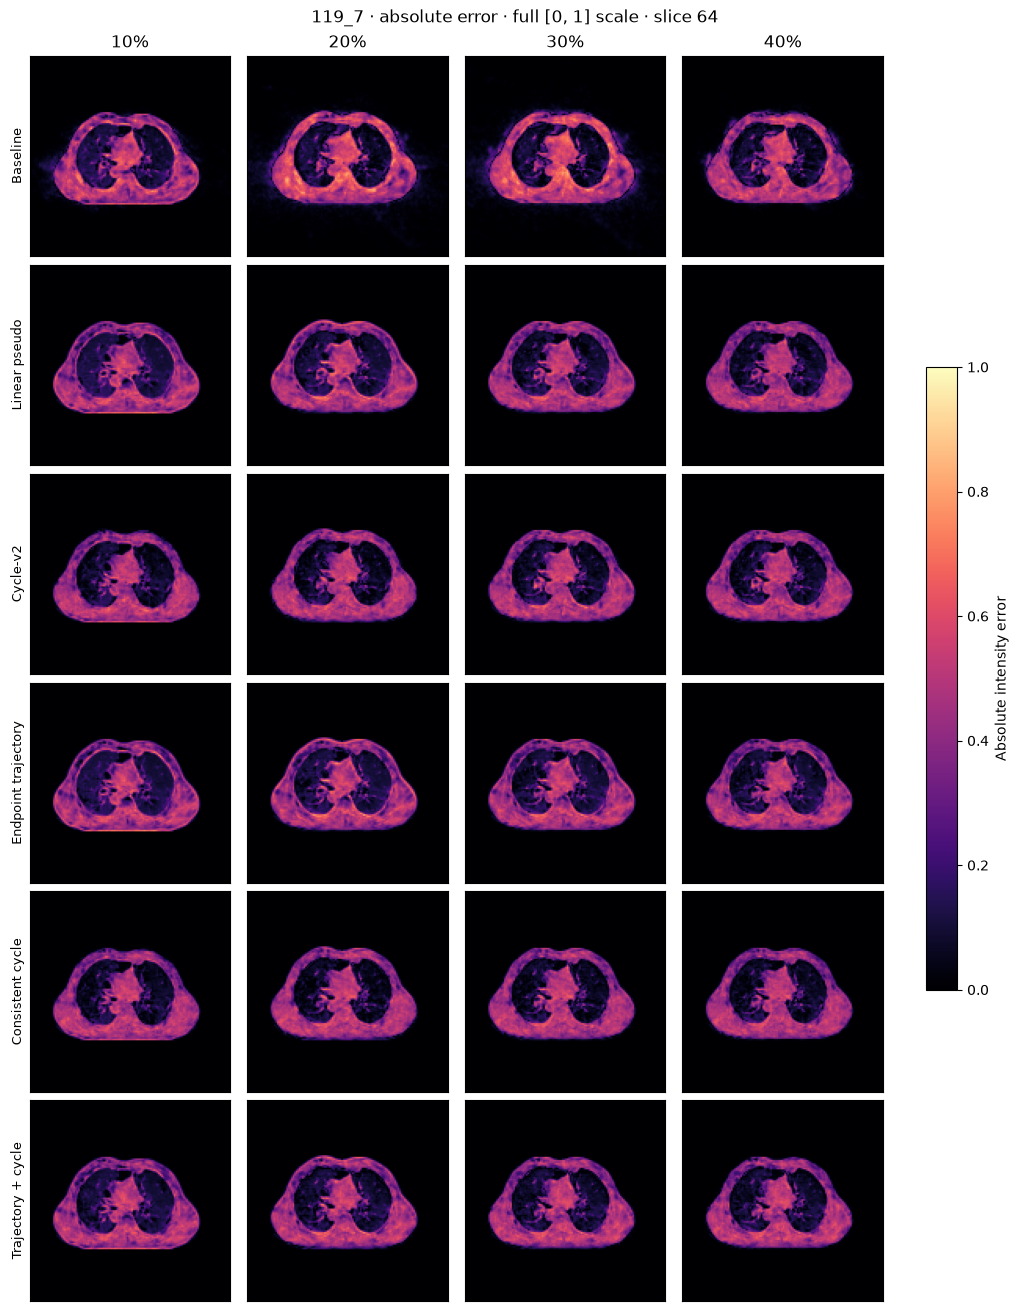

Saved figure: absolute_error_full_range_119_7


In [58]:
print("Generating full-range absolute-error maps on the fixed [0, 1] intensity scale for qualitative diagnostics.")

for case in QUALITATIVE_CASES:
    gt = {}
    for phase in PHASES:
        path = DATA_ROOT / case / f"ct_{case}_frame{phase // 10}.nii.gz"
        gt[phase] = (
            nib.load(str(path))
            .get_fdata(dtype=np.float32)
            .transpose(2, 1, 0)[QUALITATIVE_SLICE]
        )

    fig, axes = plt.subplots(6, 4, figsize=(10, 13), constrained_layout=True)

    for row, method in enumerate(METHODS):
        for col, phase in enumerate(PHASES):
            p = np.load(
                ROOT / "predictions" / case / method / f"phase_{phase:02d}.npy",
                mmap_mode="r",
            )

            im = axes[row, col].imshow(
                np.abs(p[QUALITATIVE_SLICE] - gt[phase]),
                cmap="magma",
                vmin=0,
                vmax=1.0,
            )

            if row == 0:
                axes[row, col].set_title(f"{phase}%")

        axes[row, 0].set_ylabel(LABELS[method], fontsize=9)

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])

    fig.colorbar(
        im,
        ax=axes.ravel().tolist(),
        shrink=0.5,
        label="Absolute intensity error",
    )

    fig.suptitle(
        f"{case} · absolute error · full [0, 1] scale · slice {QUALITATIVE_SLICE}"
    )

    save_figure(fig, f"absolute_error_full_range_{case}")

## 11. Computation and export

Temporal training time includes the additional auxiliary work; equal iteration budgets are therefore not equal time budgets. Inference uses only the primary field. The canonical representation is shared across methods, so its fitting cost is listed separately rather than counted six times. Allocator peaks are process-local measurements, not total device utilization.


In [47]:
print("Summarizing training and rendering cost, GPU memory, parameter count, and clipping diagnostics across the 14 held-out series.")
resource_rows = []
for case in TEST_CASES:
    for method in METHODS:
        run = temporal_dir(case, method)
        history = pd.read_csv(run / "training_history.csv")
        rendered = json.loads((ROOT / "predictions" / case / method / "render.json").read_text())
        audit = training_audit.loc[(training_audit.Case == case) & (training_audit.Method == method)].iloc[0]
        resource_rows.append({"Case": case, "Method": method,
                              "TrainingSeconds": audit.TrainingSeconds,
                              "TrainingPeakGpuGB": history.PeakGpuMemoryGB.max(),
                              "RenderSecondsFourVolumes": rendered["seconds"],
                              "RenderPeakGpuGB": rendered["peak_gpu_gb"],
                              "PrimaryParameters": rendered["primary_parameters"],
                              "MaxClippedRGBFraction": max(rendered["rgb_clipped_fraction"].values()),
                              })
resources = pd.DataFrame(resource_rows)
resources.to_csv(ROOT / "tables/resources_per_case.csv", index=False)
resource_summary = resources.groupby("Method").mean(numeric_only=True).reindex(METHODS)
resource_summary.to_csv(ROOT / "tables/resources_mean.csv")
display(resource_summary)
canonical_cost = []
for case in TEST_CASES:
    folder = ROOT / "canonical" / f"benchmark_{case}" / f"phase00_iter{CANONICAL_ITERATIONS}"
    metadata = folder / "resource_segment.json"
    if metadata.exists():
        canonical_cost.append({"Case": case, **json.loads(metadata.read_text())})
pd.DataFrame(canonical_cost).to_csv(ROOT / "tables/canonical_resources.csv", index=False)
print("Canonical cost CSV records the last successful segment; resumed runs are labeled.")


Summarizing training and rendering cost, GPU memory, parameter count, and clipping diagnostics across the 14 held-out series.


,TrainingSeconds,TrainingPeakGpuGB,RenderSecondsFourVolumes,RenderPeakGpuGB,PrimaryParameters,MaxClippedRGBFraction
Method,,,,,,
baseline,1440.259850,2.266965,1.992365,0.212695,206339.0,5.222502e-07
linear_pseudo,1559.287749,3.282074,2.032822,0.212695,206339.0,7.152557e-07
cycle_v2,2860.957697,2.833077,2.008532,0.212695,206339.0,0.000000e+00
trajectory,1090.060038,1.600155,1.981073,0.196830,272646.0,1.771109e-06
consistent_cycle,2593.795686,2.860796,2.031730,0.212695,206339.0,0.000000e+00
trajectory_cycle,2045.205382,1.921153,1.983299,0.196830,272646.0,1.055854e-06


Canonical cost CSV records the last successful segment; resumed runs are labeled.


Plotting the mean training and inference cost of all six reconstruction methods across the 14 held-out series.


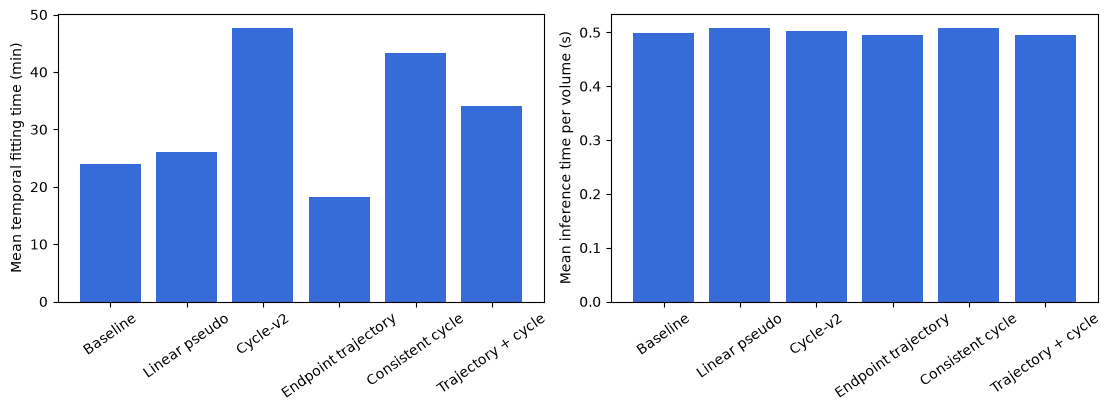

Saved figure: computation_cost


In [59]:
print("Plotting the mean training and inference cost of all six reconstruction methods across the 14 held-out series.")
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
labels = [LABELS[m] for m in METHODS]
axes[0].bar(labels, resource_summary.TrainingSeconds / 60)
axes[0].set_ylabel("Mean temporal fitting time (min)")
axes[1].bar(labels, resource_summary.RenderSecondsFourVolumes / 4)
axes[1].set_ylabel("Mean inference time per volume (s)")
for ax in axes:
    ax.tick_params(axis="x", labelrotation=35)
save_figure(fig, "computation_cost")


In [60]:
print("Packaging the reproducible benchmark outputs, metadata, figures, tables, metrics, environment information, and helper tools.")
# A compact result bundle excludes large checkpoints and prediction arrays.
import zipfile

bundle = ROOT / "benchmark_results.zip"
with zipfile.ZipFile(bundle, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for name in ["config", "metrics", "tables", "figures", "environment", "tools"]:
        for path in sorted((ROOT / name).rglob("*")):
            if path.is_file() and "__pycache__" not in path.parts:
                archive.write(path, path.relative_to(ROOT))
write_json(ROOT / "benchmark_complete.json", {
    "utc": datetime.now(timezone.utc).isoformat(), "experiment": EXPERIMENT_ID,
    "canonical_runs": 14, "temporal_runs": 84, "evaluated_volumes": len(metrics),
    "result_bundle_sha256": sha256_file(bundle),
})
print("Results:", bundle)
print("Checkpoints:", ROOT / "canonical", "and", ROOT / "methods")
print("Predictions:", ROOT / "predictions")
from IPython.display import FileLink

# Jupyter links are relative to the notebook working directory.
display(FileLink(os.path.relpath(bundle, Path.cwd())))


Packaging the reproducible benchmark outputs, metadata, figures, tables, metrics, environment information, and helper tools.
Results: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/benchmark_results.zip
Checkpoints: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/canonical and /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/methods
Predictions: /home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/predictions


/home/jovyan/shared/mtm_medgs_stack/experiments/medgs4d_six_methods_20261001/benchmark_results.zip

## Interpretation

Report the six variants together, including negative results. A gain for `trajectory` supports its trajectory prior; a gain for `consistent_cycle` supports the added consistency objective; `trajectory_cycle` tests their combination. Geometry consistency can still describe an incorrect motion, so endpoint reconstruction alone cannot establish interpolation quality.

Use the official 14-series table for comparison with UVI-Net and show the setting as instance-specific endpoint fitting. Accompany it with computation cost, per-patient results, the supplementary exclusion of `118_0`, and the fixed seed and iteration budget. Generalization beyond two test patients or stability across seeds requires additional experiments.
